# **ERC en afrodescendientes: Relación entre estado nutricional y estadios iniciales de la enfermedad**

In [658]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML
import math
import pingouin as pg

## **Base de datos**

Inicialmnte se retoma el contexto de la limpieza de los datos.

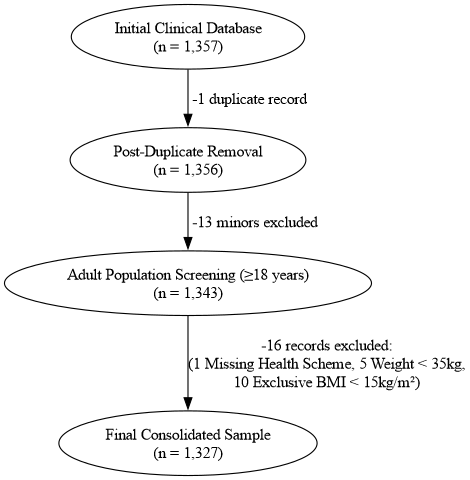

In [659]:
from IPython.display import Image
Image('data_cleaning_flow.png')

Se trabaja a partir de la base de datos resultante de los cambios realizadas en el anterior estudio.

In [660]:
df = pd.read_csv('data_afro_final.csv')

In [661]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1327 entries, 0 to 1326
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Departamento_Tamizaje         1327 non-null   object 
 1   Municipio_Tamizaje            1327 non-null   object 
 2   Edad                          1327 non-null   int64  
 3   Genero                        1327 non-null   object 
 4   Escolaridad                   1327 non-null   object 
 5   Regimen_Salud                 1327 non-null   object 
 6   Medicacion_Diabetes           1327 non-null   object 
 7   Diabetes_Embarazo             1327 non-null   object 
 8   Hipertension                  1327 non-null   object 
 9   Medicacion_Hipertension       1327 non-null   object 
 10  Colesterol_Alto               1327 non-null   object 
 11  Medicacion_Colesterol         1327 non-null   object 
 12  Insuficiencia_Renal           1327 non-null   object 
 13  Dia

In [662]:
df.head()

,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,...,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC,IMC_CAL,TFG_CDK_EPI_CAL,Estadio_ERC_CAL,Estadio_ERC_Binaria
0,BOLIVAR,Zona_costera,57,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,Si,No,Si,Si,...,No,1,0,1.61-1.70,61-80,Normal,22.86,74.565522,G2: Descenso Leve (60-89),No moderado
1,ATLANTICO,Zona_urbana,28,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,Sí,No,No,...,No,0,0,1.61-1.70,61-80,Alto,28.23,120.737073,G1: Normal o Elevado (≥90),No moderado
2,ATLANTICO,Zona_urbana,35,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,No,No,No,...,No,0,0,1.61-1.70,>80,Obesidad,34.37,NaN,NaN,NaN
3,ATLANTICO,Zona_urbana,19,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,No,No,No,No,...,No,0,0,1.61-1.70,61-80,Normal,24.77,NaN,NaN,NaN
4,ATLANTICO,Zona_urbana,44,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,No,No,No,...,No,0,0,1.50-1.60,61-80,Alto,28.40,NaN,NaN,NaN


### **Funciones**

In [663]:
def Resumen_Faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

In [664]:
def resumen_numerico(df):
    num_df = df.select_dtypes(include=[np.number])

    if num_df.empty:
        print("No hay variables numéricas en el DataFrame.")
        return None

    resumen = pd.DataFrame({
        'tipo': num_df.dtypes,
        'n_valores': num_df.count(),
        'n_nulos': num_df.isnull().sum(),
        '%_nulos': (num_df.isnull().mean() * 100).round(2),
        'media': num_df.mean(),
        'mediana': num_df.median(),
        'desv_std': num_df.std(),
        'min': num_df.min(),
        'max': num_df.max(),
        'asimetria': num_df.skew(),
        'curtosis': num_df.kurt(),
        'n_unicos': num_df.nunique()
    })

    return resumen.round(2)

In [665]:
def resumen_categorico(df):
    cat_df = df.select_dtypes(include=['object', 'category'])

    if cat_df.empty:
        print("No hay variables categóricas en el DataFrame.")
        return None

    filas = []
    for col in cat_df.columns:
        conteos = cat_df[col].value_counts()
        moda = conteos.index[0] if not conteos.empty else None
        filas.append({
            'variable': col,
            'n_valores': cat_df[col].count(),
            'n_nulos': cat_df[col].isnull().sum(),
            '%_nulos': round(cat_df[col].isnull().mean() * 100, 2),
            'n_categorias': cat_df[col].nunique(),
            'categoria_mas_frecuente': moda,
            'frecuencia_moda': conteos.iloc[0] if not conteos.empty else 0,
            '%_moda': round((conteos.iloc[0] / cat_df[col].count()) * 100, 2) if not conteos.empty else 0
        })

    return pd.DataFrame(filas).set_index('variable')

## **Resumen general**

La base de datos cuenta inicialmente con **1327 individuos**. Pero cabe destacar que la base de datos cuenta con datos faltantes debido a los inidividuos sin valores de TFG, creatinina y variables derivadas. 

In [666]:
Resumen_Faltantes(df)

,Valores faltantes,Porcentaje (%)
Creatinina,861,64.883195
TFG_CDK_EPI,861,64.883195
TFG_Edad,861,64.883195
Presion_Sistolica,47,3.541824
Presion_Diastolica,47,3.541824
TFG_CDK_EPI_CAL,861,64.883195
Estadio_ERC_CAL,861,64.883195
Estadio_ERC_Binaria,861,64.883195


Debido a que el estudio se hará teniendo en cuenta la TFG se eliminan los registros con NA para mantener consistencia en el análisis.

In [667]:
df_tfg = df.dropna(subset=['TFG_CDK_EPI_CAL'])

In [668]:
Resumen_Faltantes(df_tfg)

,Valores faltantes,Porcentaje (%)
Presion_Sistolica,12,2.575107
Presion_Diastolica,12,2.575107


In [669]:
df_imputado = df_tfg.copy()

In [670]:
df_imputado["Presion_Sistolica"] = df_tfg["Presion_Sistolica"].fillna(df_tfg["Presion_Sistolica"].median())
df_imputado["Presion_Diastolica"] = df_tfg["Presion_Diastolica"].fillna(df_tfg["Presion_Diastolica"].median())

In [671]:
from scipy.stats import ks_2samp

col = "Presion_Sistolica"
alpha = 0.05

original = df_tfg[col].dropna()
imputada = df_imputado[col]

stat, p = ks_2samp(original, imputada)

print(f"KS statistic: {stat:.6f}")
print(f"p-value: {p:.6f}")

if p < alpha:
    print(
        f"Se rechaza H₀ (p = {p:.6f} < {alpha}). "
        "Las distribuciones son significativamente diferentes."
    )
else:
    print(
        f"No se rechaza H₀ (p = {p:.6f} ≥ {alpha}). "
        "No hay evidencia estadística de diferencias entre las distribuciones."
    )

KS statistic: 0.011117
p-value: 1.000000
No se rechaza H₀ (p = 1.000000 ≥ 0.05). No hay evidencia estadística de diferencias entre las distribuciones.


In [672]:
from scipy.stats import ks_2samp

col = "Presion_Diastolica"
alpha = 0.05

original = df_tfg[col].dropna()
imputada = df_imputado[col]

stat, p = ks_2samp(original, imputada)

print(f"KS statistic: {stat:.6f}")
print(f"p-value: {p:.6f}")

if p < alpha:
    print(
        f"Se rechaza H₀ (p = {p:.6f} < {alpha}). "
        "Las distribuciones son significativamente diferentes."
    )
else:
    print(
        f"No se rechaza H₀ (p = {p:.6f} ≥ {alpha}). "
        "No hay evidencia estadística de diferencias entre las distribuciones."
    )

KS statistic: 0.012252
p-value: 1.000000
No se rechaza H₀ (p = 1.000000 ≥ 0.05). No hay evidencia estadística de diferencias entre las distribuciones.


In [673]:
df_tfg = df_imputado.copy()

## **Datos completos según `TFG_EPI_CAL`**

### **Base de datos**

In [674]:
df_tfg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 466 entries, 0 to 1326
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Departamento_Tamizaje         466 non-null    object 
 1   Municipio_Tamizaje            466 non-null    object 
 2   Edad                          466 non-null    int64  
 3   Genero                        466 non-null    object 
 4   Escolaridad                   466 non-null    object 
 5   Regimen_Salud                 466 non-null    object 
 6   Medicacion_Diabetes           466 non-null    object 
 7   Diabetes_Embarazo             466 non-null    object 
 8   Hipertension                  466 non-null    object 
 9   Medicacion_Hipertension       466 non-null    object 
 10  Colesterol_Alto               466 non-null    object 
 11  Medicacion_Colesterol         466 non-null    object 
 12  Insuficiencia_Renal           466 non-null    object 
 13  Dialisis 

Finalmente, la muestra cuenta con **466 individuos**.

Variables:

* Sociodemográficas — departamento, municipio, edad, género, escolaridad, régimen de salud
* Antecedentes clínicos — diabetes, hipertensión, colesterol alto, insuficiencia renal, diálisis, proteína en orina
* Estilos de vida — tabaco, alcohol, drogas
* Exposición ocupacional — trabajo agrícola, uso de insecticidas/fungicidas/fertilizantes y métodos de protección
* Acceso a salud — última consulta, dificultad de atención, médico de cabecera
* Antecedentes familiares — insuficiencia renal y diálisis en familia
* Mediciones clínicas — peso, talla, IMC, presión sistólica/diastólica, creatinina, TFG (CKD-EPI)
* Variables derivadas/target — Estadio ERC (categórico y binario), categorías de IMC, flags de presión alta

In [675]:
df_tfg.head()

,Departamento_Tamizaje,Municipio_Tamizaje,Edad,Genero,Escolaridad,Regimen_Salud,Medicacion_Diabetes,Diabetes_Embarazo,Hipertension,Medicacion_Hipertension,...,Creatinina_Alta,Presion_Sistolica\t> 130,Presion_Diastolica > 90,Categoria_Talla,Categoria_Peso,Categoria_IMC,IMC_CAL,TFG_CDK_EPI_CAL,Estadio_ERC_CAL,Estadio_ERC_Binaria
0,BOLIVAR,Zona_costera,57,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,Si,No,Si,Si,...,No,1,0,1.61-1.70,61-80,Normal,22.86,74.565522,G2: Descenso Leve (60-89),No moderado
1,ATLANTICO,Zona_urbana,28,Femenino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,Sí,No,No,...,No,0,0,1.61-1.70,61-80,Alto,28.23,120.737073,G1: Normal o Elevado (≥90),No moderado
9,BOLIVAR,Zona_costera,56,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,Si,No,Si,Si,...,No,1,1,1.61-1.70,41-60,Normal,23.15,86.421559,G2: Descenso Leve (60-89),No moderado
10,BOLIVAR,Zona_costera,69,Femenino,No_escolarizado-Primaria,Subsidiado-No_Tiene,No,No aplica,No,No,...,No,0,0,1.61-1.70,41-60,Normal,20.96,60.984151,G2: Descenso Leve (60-89),No moderado
11,ATLANTICO,Zona_urbana,56,Masculino,Secundaria-Bachiller,Subsidiado-No_Tiene,No,No aplica,No,No,...,No,1,0,1.50-1.60,61-80,Alto,25.48,100.237891,G1: Normal o Elevado (≥90),No moderado


### **Resumen general**

La base de datos está compuesta por 466 participantes. La población evaluada tuvo una edad promedio de 47,67 ± 17,29 años y una mediana de 48 años (RIC: 34–61 años), evidenciando una amplia representación de adultos de diferentes grupos etarios. Predominaron las mujeres (61,37%), los participantes procedentes del departamento del Atlántico (77,47%) y los residentes en zonas urbanas (48,07%), mientras que el nivel educativo más frecuente correspondió a secundaria o bachillerato (37,98%). Asimismo, la mayoría de los participantes pertenecía al régimen subsidiado o no contaba con afiliación al sistema de salud (73,18%), y se observó una baja frecuencia de comportamientos asociados al consumo de tabaco (88,63% no fumadores), alcohol (71,46% no consumidores) y drogas psicoactivas (98,28% no consumidores).

Desde el punto de vista clínico, el peso presentó una media de 71,03 ± 14,05 kg y una mediana de 70 kg (RIC: 61–80 kg), mientras que la talla registró una media de 1,65 ± 0,08 m y una mediana de 1,65 m (RIC: 1,60–1,70 m). El IMC mostró una media de 26,32 ± 5,77 kg/m² y una mediana de 25,77 kg/m² (RIC: 22,35–29,45 kg/m²), siendo la categoría nutricional más frecuente el estado nutricional normal (34,12%). En cuanto a los indicadores de función renal, la creatinina presentó una media de 1,16 ± 0,39 mg/dL y una mediana de 1,00 mg/dL (RIC: 0,90–1,40 mg/dL), mientras que la TFG calculada mediante CKD-EPI (TFG_CDK_EPI_CAL) registró una media de 73,29 ± 26,91 mL/min/1,73 m² y una mediana de 71,10 mL/min/1,73 m² (RIC: 49,84–95,52 mL/min/1,73 m²). Además, la mayoría de los participantes no reportó insuficiencia renal (81,97%), diálisis (97,42%) ni antecedentes familiares de enfermedad renal crónica (98,28%), aunque la tirilla reactiva resultó positiva en el 69,96% de los casos y el estadio renal más frecuente fue G3: descenso moderado de la función renal (37,98%).

In [676]:
resumen_numerico(df_tfg)

,tipo,n_valores,n_nulos,%_nulos,media,mediana,desv_std,min,max,asimetria,curtosis,n_unicos
Edad,int64,466,0,0.0,47.67,48.00,17.29,18.00,97.00,0.26,-0.45,71
Peso,int64,466,0,0.0,71.03,70.00,14.05,39.00,120.00,0.15,-0.14,62
Talla,float64,466,0,0.0,1.65,1.65,0.08,1.44,1.96,0.20,0.34,36
IMC,float64,466,0,0.0,26.32,25.77,5.77,15.19,46.56,0.60,0.43,256
Creatinina,float64,466,0,0.0,1.16,1.00,0.39,0.60,2.50,0.47,-0.76,188
TFG_CDK_EPI,float64,466,0,0.0,81.20,78.79,31.34,22.14,168.19,0.32,-0.75,431
TFG_Edad,float64,466,0,0.0,82.33,82.00,17.29,33.00,112.00,-0.26,-0.45,71
Presion_Sistolica,float64,466,0,0.0,124.56,120.00,16.29,97.00,200.00,1.45,3.01,64
Presion_Diastolica,float64,466,0,0.0,78.34,80.00,10.82,45.00,140.00,1.04,4.62,45
Presion_Sistolica\t> 130,int64,466,0,0.0,0.21,0.00,0.41,0.00,1.00,1.43,0.03,2


In [677]:
resumen_categorico(df_tfg)

,n_valores,n_nulos,%_nulos,n_categorias,categoria_mas_frecuente,frecuencia_moda,%_moda
variable,,,,,,,
Departamento_Tamizaje,466,0,0.0,2,ATLANTICO,361,77.47
Municipio_Tamizaje,466,0,0.0,3,Zona_urbana,224,48.07
Genero,466,0,0.0,2,Femenino,286,61.37
Escolaridad,466,0,0.0,3,Secundaria-Bachiller,177,37.98
Regimen_Salud,466,0,0.0,2,Subsidiado-No_Tiene,341,73.18
Medicacion_Diabetes,466,0,0.0,2,No,433,92.92
Diabetes_Embarazo,466,0,0.0,3,No,266,57.08
Hipertension,466,0,0.0,2,No,268,57.51
Medicacion_Hipertension,466,0,0.0,2,No,275,59.01


### **Resumen Estado nutricional**

El análisis antropométrico de los 466 participantes mostró un peso promedio de 71,03 ± 14,05 kg y una mediana de 70 kg (RIC: 61–80 kg), con valores comprendidos entre 39 y 120 kg, mientras que la talla presentó una media de 1,65 ± 0,08 m y una mediana de 1,65 m (RIC: 1,60–1,70 m), con un rango entre 1,44 y 1,96 m. Como resultado de estas características antropométricas, el índice de masa corporal (IMC) registró una media de 26,32 ± 5,77 kg/m² y una mediana de 25,77 kg/m² (RIC: 22,35–29,45 kg/m²), con valores que oscilaron entre 15,19 y 46,56 kg/m². Al clasificar a los participantes según categorías de IMC, la categoría más frecuente fue el estado nutricional normal (34,12%), seguida muy de cerca por la categoría de IMC alto o sobrepeso (33,69%), mientras que el 24,03% presentó obesidad y el 8,15% bajo peso. En conjunto, estos resultados evidencian una amplia variabilidad en el estado nutricional de la población estudiada, con predominio de individuos en categorías normales y elevadas de IMC.

In [678]:
resumen_numerico(df_tfg[['Peso', 'Talla', 'IMC']])

,tipo,n_valores,n_nulos,%_nulos,media,mediana,desv_std,min,max,asimetria,curtosis,n_unicos
Peso,int64,466,0,0.0,71.03,70.00,14.05,39.00,120.00,0.15,-0.14,62
Talla,float64,466,0,0.0,1.65,1.65,0.08,1.44,1.96,0.20,0.34,36
IMC,float64,466,0,0.0,26.32,25.77,5.77,15.19,46.56,0.60,0.43,256


In [679]:
cat_imc = df_tfg['Categoria_IMC'].value_counts().reset_index()
cat_imc.columns = ['Categoria', 'Frecuencia']
cat_imc['Porcentaje'] = (cat_imc['Frecuencia'] / len(df_tfg) * 100).round(2)
cat_imc

,Categoria,Frecuencia,Porcentaje
0,Normal,159,34.12
1,Alto,157,33.69
2,Obesidad,112,24.03
3,Bajo,38,8.15


C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4284628536.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Genero', y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\4284628536.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax4.set_xticklabels(conteos.index, rotation=30, ha='right', fontsize=9)


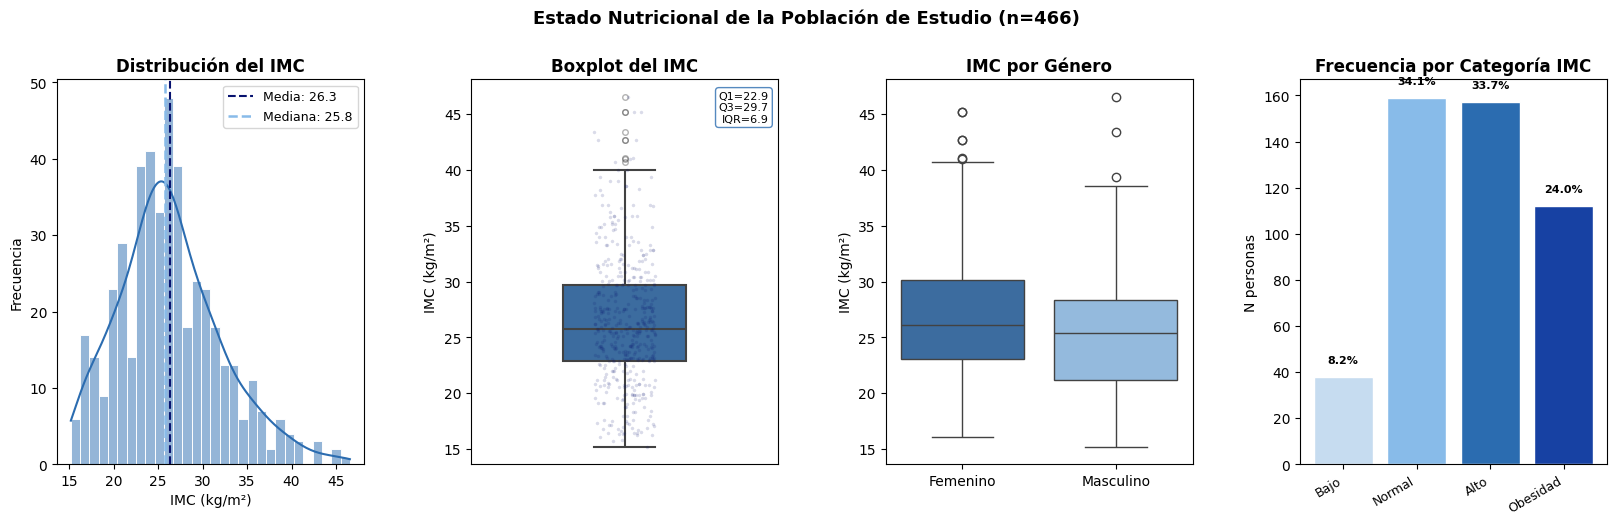

In [680]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

orden = ['Bajo', 'Normal', 'Alto', 'Obesidad']
orden_presente = [c for c in orden if c in df_tfg['Categoria_IMC'].unique()]

paleta = {
    'Bajo':     '#C6DCF0',
    'Normal':   '#88BBE9',
    'Alto':     '#2B6CB0',
    'Obesidad': "#1741A3"
}

fig = plt.figure(figsize=(20, 5))
gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
sns.histplot(df_tfg['IMC'], bins=30, kde=True, color='#2B6CB0', edgecolor='white', ax=ax1)
ax1.axvline(df_tfg['IMC'].mean(),   color='#07126F', linestyle='--', linewidth=1.5, label=f"Media: {df_tfg['IMC'].mean():.1f}")
ax1.axvline(df_tfg['IMC'].median(), color='#88BBE9', linestyle='--', linewidth=1.8, label=f"Mediana: {df_tfg['IMC'].median():.1f}")
ax1.set_title('Distribución del IMC', fontweight='bold')
ax1.set_xlabel('IMC (kg/m²)')
ax1.set_ylabel('Frecuencia')
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(gs[1])
sns.boxplot(y=df_tfg['IMC'], color='#2B6CB0', width=0.4, linewidth=1.5,
            flierprops=dict(marker='o', color='#07126F', alpha=0.4, markersize=4),
            ax=ax2)
sns.stripplot(y=df_tfg['IMC'], color='#07126F', alpha=0.15, size=2.5, jitter=True, ax=ax2)
ax2.set_title('Boxplot del IMC', fontweight='bold')
ax2.set_ylabel('IMC (kg/m²)')
ax2.set_xticks([])
q1, q3 = df_tfg['IMC'].quantile([0.25, 0.75])
ax2.text(0.97, 0.97, f'Q1={q1:.1f}\nQ3={q3:.1f}\nIQR={q3-q1:.1f}',
         transform=ax2.transAxes, fontsize=8, va='top', ha='right',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#2B6CB0', alpha=0.8))

ax3 = fig.add_subplot(gs[2])
sns.boxplot(data=df_tfg, x='Genero', y='IMC',
            palette={'Masculino': '#88BBE9', 'Femenino': '#2B6CB0'}, ax=ax3)
ax3.set_title('IMC por Género', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('IMC (kg/m²)')

ax4 = fig.add_subplot(gs[3])
conteos = df_tfg['Categoria_IMC'].value_counts().reindex(orden_presente)
colores = [paleta.get(c, '#88BBE9') for c in conteos.index]
bars = ax4.bar(conteos.index, conteos.values, color=colores, edgecolor='white')
ax4.set_title('Frecuencia por Categoría IMC', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('N personas')
ax4.set_xticklabels(conteos.index, rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, conteos.values):
    pct = val / len(df_tfg) * 100
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Estado Nutricional de la Población de Estudio (n=466)',
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

La distribución del IMC en la población estudiada presenta un comportamiento asimétrico hacia la derecha, con una media de 26,3 kg/m² y una mediana de 25,8 kg/…La distribución del IMC en la población estudiada presenta un comportamiento asimétrico hacia la derecha, con una media de 26,3 kg/m² y una mediana de 25,8 kg/m², ambas cercanas entre sí pero con una cola extendida hacia valores altos que llega hasta cerca de 47 kg/m², reflejando la presencia de un subgrupo con obesidad marcada; el boxplot confirma este patrón, mostrando un rango intercuartílico de 6,9 (Q1=22,9; Q3=29,7) y múltiples valores atípicos por encima de 40 kg/m², todos ubicados en el extremo superior, sin atípicos hacia el extremo inferior. Al comparar el IMC por género, se observa que los hombres presentan una mediana levemente superior a la de las mujeres (alrededor de 26 frente a 25 kg/m², respectivamente), aunque ambos grupos muestran rangos intercuartílicos amplios y similares, así como valores atípicos en la parte alta de la distribución, lo que indica que el exceso de peso no se concentra exclusivamente en un género, sino que está presente de forma comparable en ambos. Finalmente, al agrupar a los participantes por categoría de IMC, se confirma que el estado nutricional normal es el más frecuente (34,1%), seguido muy de cerca por la categoría alta o de sobrepeso (33,7%), mientras que la obesidad alcanza una proporción considerable (24,0%) y el bajo peso es el grupo menos representado (8,2%); en conjunto, estos resultados visuales refuerzan que más de la mitad de la población (57,7%) se encuentra en categorías de exceso de peso (alto u obesidad), evidenciando una carga importante de alteraciones nutricionales por encima del rango normal en el grupo evaluado.

#### **Visualización IMC con respecto a otras variables** 

##### **IMC vs variables numéricas**

Inicialmente se visualiza la relación entre IMC y algunas variables numéricas, que podrían dar inofrmación significativa.

In [681]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

orden_presente = [c for c in ['Bajo', 'Normal', 'Alto', 'Obesidad']
                  if c in df_tfg['Categoria_IMC'].unique()]

paleta_cat = {
    'Bajo':     '#C6DCF0',
    'Normal':   '#88BBE9',
    'Alto':     '#2B6CB0',
    'Obesidad': '#07126F'
}
colores_cat = [paleta_cat[c] for c in orden_presente]
blues_hue   = ['#C6DCF0', '#07126F']  

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1908000226.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1908000226.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1908000226.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,


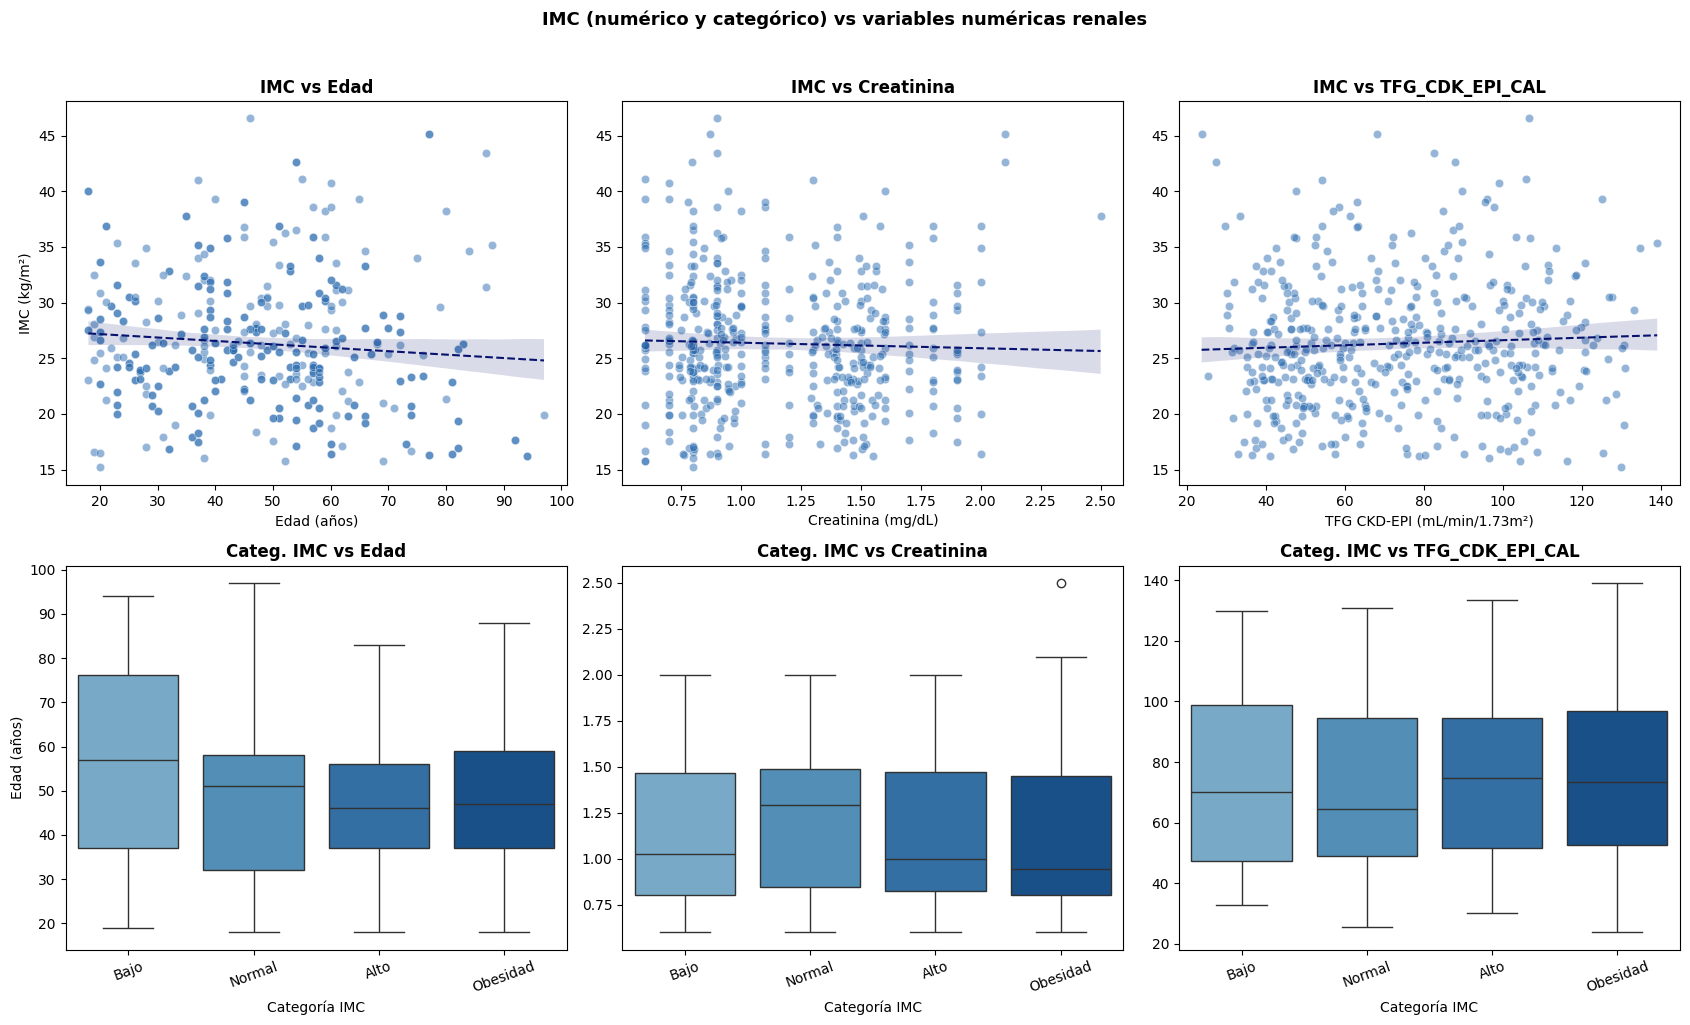

In [682]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

num_vars = [
    ('Edad',            'Edad (años)'),
    ('Creatinina',      'Creatinina (mg/dL)'),
    ('TFG_CDK_EPI_CAL', 'TFG CKD-EPI (mL/min/1.73m²)')
]

for j, (var, xlabel) in enumerate(num_vars):
    sns.scatterplot(data=df_tfg, x=var, y='IMC',
                    color='#2B6CB0', alpha=0.5, ax=axes[0, j])
    sns.regplot(data=df_tfg, x=var, y='IMC', scatter=False, color='#07126F',
                line_kws={'linestyle': '--', 'linewidth': 1.5}, ax=axes[0, j])
    axes[0, j].set_title(f'IMC vs {var}', fontweight='bold')
    axes[0, j].set_xlabel(xlabel)
    axes[0, j].set_ylabel('IMC (kg/m²)' if j == 0 else '')

for j, (var, ylabel) in enumerate(num_vars):
    pal = sns.color_palette("Blues", len(orden_presente) + 3)[3:]
    sns.boxplot(data=df_tfg, x='Categoria_IMC', y=var,
                order=orden_presente, palette=pal, ax=axes[1, j])
    axes[1, j].set_title(f'Categ. IMC vs {var}', fontweight='bold')
    axes[1, j].set_xlabel('Categoría IMC')
    axes[1, j].set_ylabel(ylabel if j == 0 else '')
    axes[1, j].tick_params(axis='x', rotation=20)

plt.suptitle('IMC (numérico y categórico) vs variables numéricas renales',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Al explorar la relación entre el IMC y algunas variables numéricas, los gráficos de dispersión muestran que tanto la edad como la creatinina y la TFG_CDK_EPI_CAL presentan líneas de tendencia prácticamente planas frente al IMC, lo que sugiere una asociación lineal muy débil o nula entre estas variables, con bandas de confianza amplias que reflejan alta dispersión de los datos; de hecho, se observa una leve tendencia descendente entre IMC y edad, y leves tendencias descendente y ascendente, respectivamente, para creatinina y TFG_CDK_EPI_CAL, aunque ninguna parece clínicamente relevante dada la dispersión observada. 

Al analizar las categorías de IMC frente a la edad, se observa que el grupo de bajo peso presenta la mediana de edad más alta (57 años) y el rango intercuartílico más amplio, mientras que las categorías normal, alto y obesidad muestran medianas más similares entre sí (46-51 años), sin un patrón claramente creciente o decreciente con el aumento del IMC. En cuanto a la creatinina por categoría de IMC, las medianas se mantienen relativamente estables entre 1,0 y 1,3 mg/dL en todos los grupos, aunque el grupo con obesidad presenta la mediana más baja (cerca de 0,95 mg/dL) y un valor atípico notable cercano a 2,5 mg/dL, sin que se evidencie un patrón sistemático de aumento de creatinina con el incremento del IMC. Finalmente, respecto a la TFG_CDK_EPI_CAL por categoría de IMC, se observa que el grupo de bajo peso presenta la mediana más baja (alrededor de 70 mL/min/1,73m²) junto con el grupo normal (64 mL/min/1,73m²), mientras que los grupos de IMC alto y obesidad muestran medianas levemente superiores (74-75 mL/min/1,73m²), lo que indicaría, contrario a lo esperado, que un mayor IMC no se asocia en este grupo con una disminución más marcada de la función renal, aunque la amplia dispersión de los datos en todas las categorías limita la fuerza de esta observación.

##### **IMC vs variables categóricas**

Se seleccionan algunas variables categóricas que pod´rias dar información significativa con respecto a la relación con el estado nutricional.

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1297235139.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1297235139.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1297235139.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x=var, y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\1297235139.py:14: FutureWarning: 

Passing `palette` without assigning `hue`

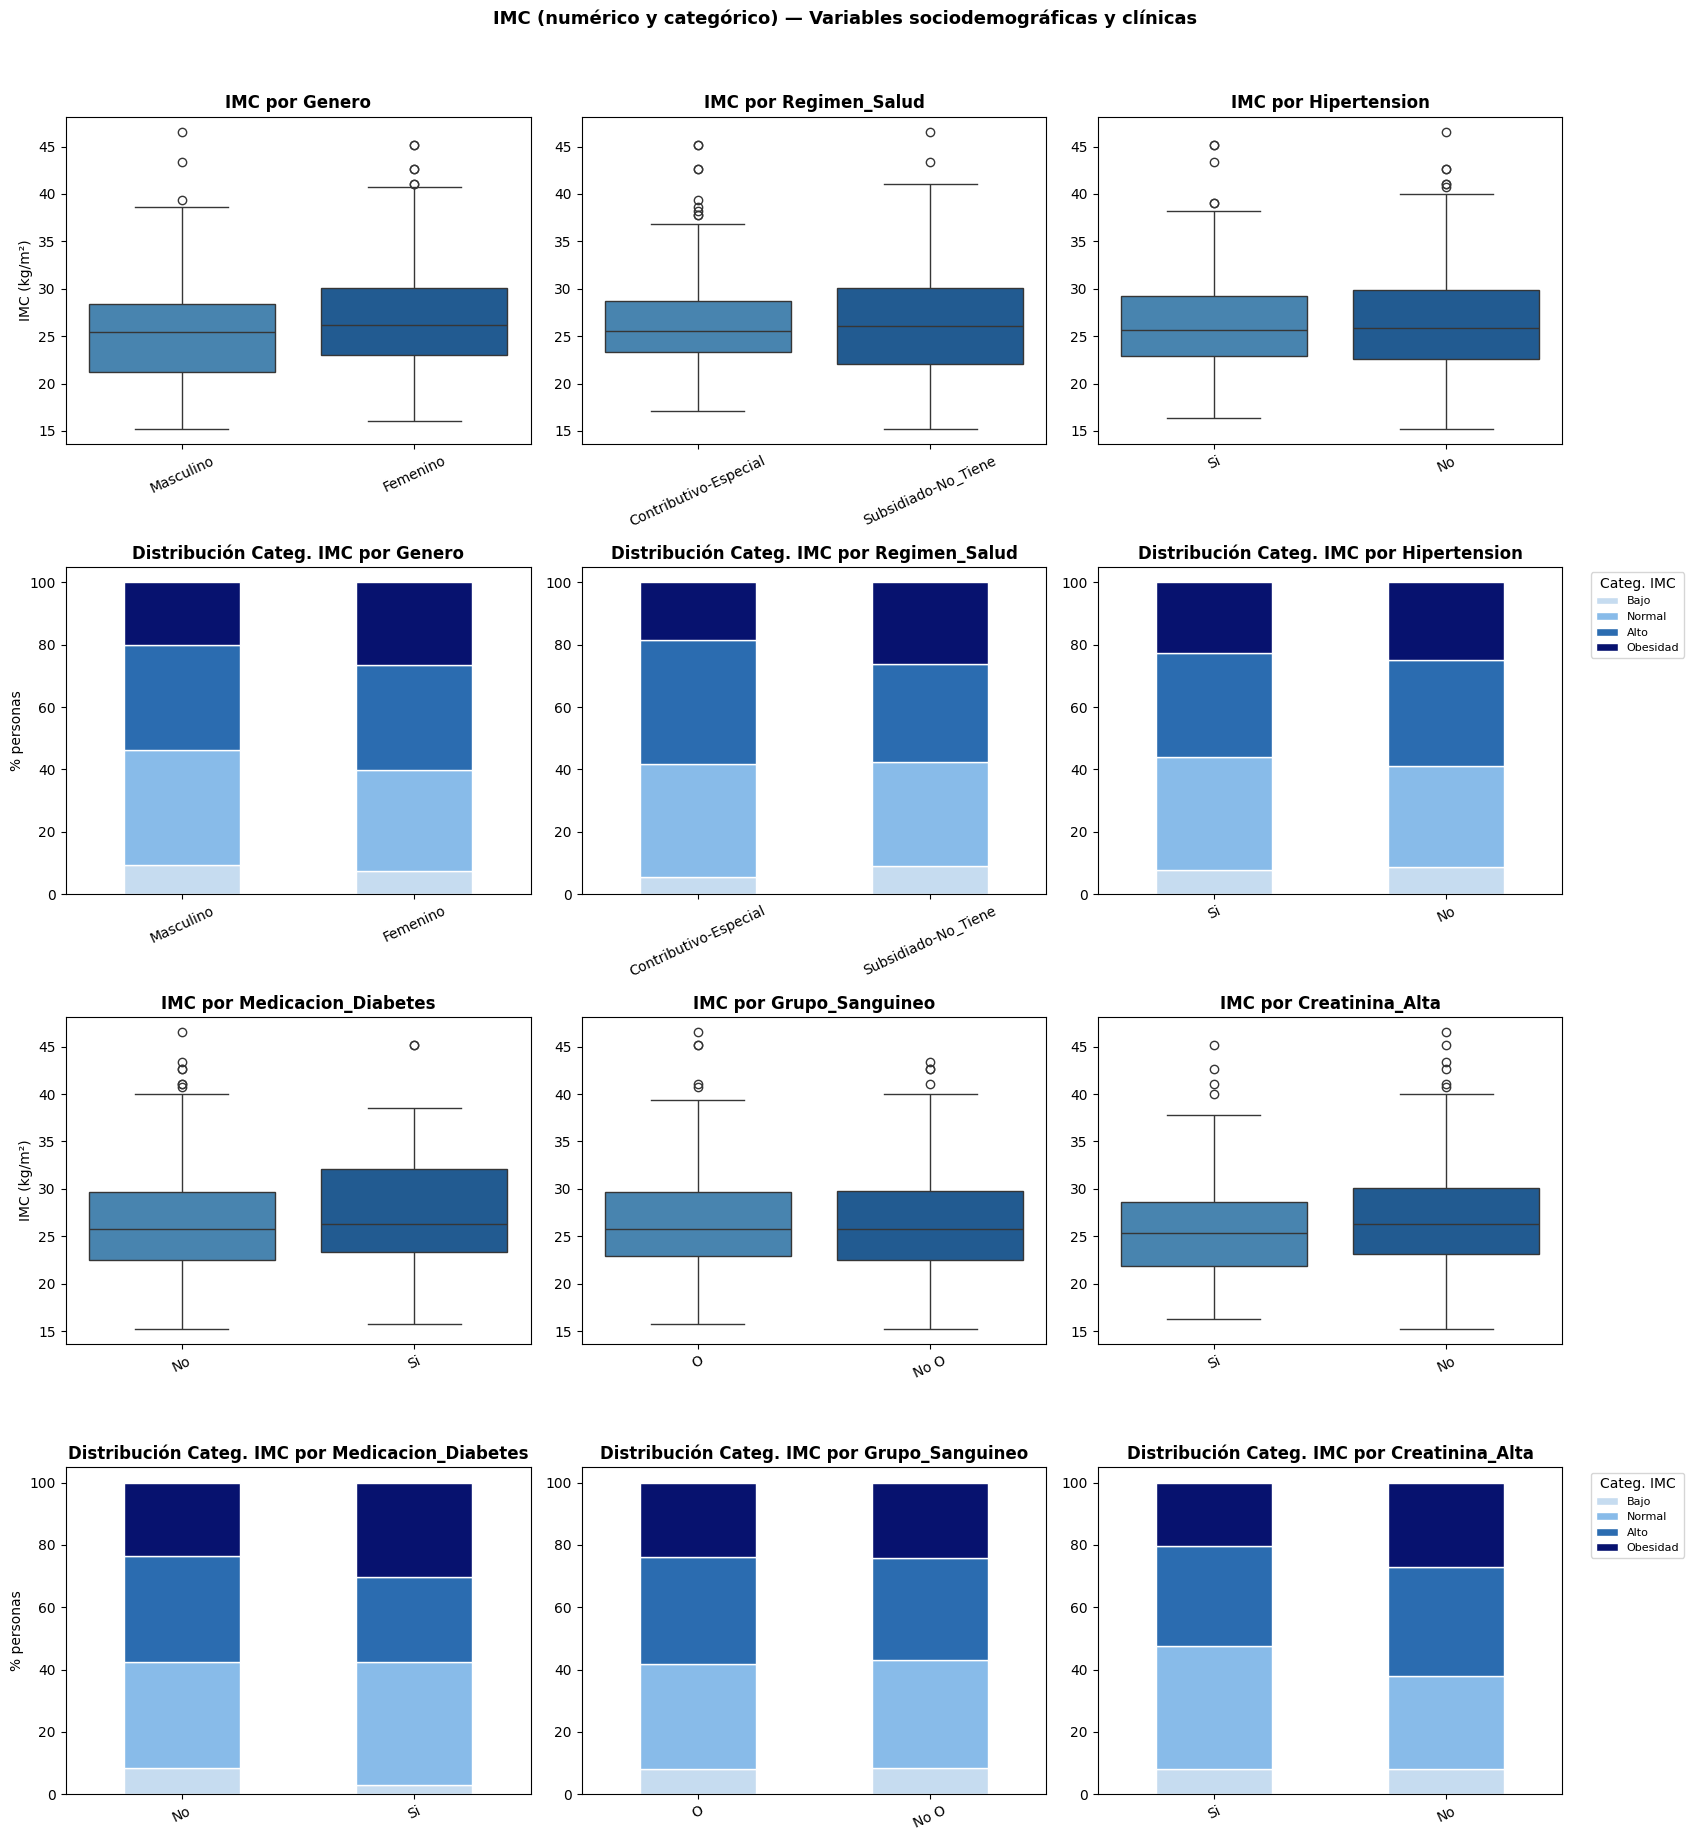

In [683]:
cat_g1 = ['Genero', 'Regimen_Salud', 'Hipertension',
          'Medicacion_Diabetes', 'Grupo_Sanguineo', 'Creatinina_Alta']

fig, axes = plt.subplots(4, 3, figsize=(17, 18))

for j, var in enumerate(cat_g1):
    col     = j % 3         
    fila_box = (j // 3) * 2  
    fila_bar = fila_box + 1  

    orden_var = df_tfg.groupby(var)['IMC'].median().sort_values().index.tolist()
    pal = sns.color_palette("Blues", len(orden_var) + 3)[3:]

    sns.boxplot(data=df_tfg, x=var, y='IMC',
                order=orden_var, palette=pal, ax=axes[fila_box, col])
    axes[fila_box, col].set_title(f'IMC por {var}', fontweight='bold')
    axes[fila_box, col].set_xlabel('')
    axes[fila_box, col].set_ylabel('IMC (kg/m²)' if col == 0 else '')
    axes[fila_box, col].tick_params(axis='x', rotation=25)

    ct = pd.crosstab(df_tfg[var], df_tfg['Categoria_IMC'], normalize='index') * 100
    ct = ct.reindex(columns=orden_presente)
    ct.reindex(orden_var).plot(kind='bar', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[fila_bar, col],
                                legend=(col == 2))
    axes[fila_bar, col].set_title(f'Distribución Categ. IMC por {var}', fontweight='bold')
    axes[fila_bar, col].set_xlabel('')
    axes[fila_bar, col].set_ylabel('% personas' if col == 0 else '')
    axes[fila_bar, col].tick_params(axis='x', rotation=25)
    if col == 2:
        axes[fila_bar, col].legend(title='Categ. IMC',
                                   bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) — Variables sociodemográficas y clínicas',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Al analizar el IMC en función de variables sociodemográficas y clínicas, se observa que las mujeres presentan una mediana de IMC levemente superior a la de los hombres (alrededor de 26 frente a 25,5 kg/m², respectivamente), y al revisar la distribución por categorías, las mujeres muestran una mayor proporción combinada de las categorías alto y obesidad (cerca del 60%) frente a los hombres (aproximadamente 53%), mientras que estos últimos presentan una proporción más alta de bajo peso. En cuanto al régimen de salud, quienes pertenecen al régimen subsidiado o no cuentan con afiliación presentan una mediana de IMC ligeramente más alta que el grupo contributivo-especial, y también muestran una mayor proporción en la categoría de obesidad (cerca del 26% frente a 18%), aunque ambos grupos comparten un rango intercuartílico similar.Respecto a la hipertensión, las medianas de IMC son prácticamente idénticas entre quienes la reportan y quienes no, con distribuciones por categoría muy parecidas entre ambos grupos, lo que sugiere que en este conjunto de datos no se observa una diferencia marcada en el IMC asociada a la presencia de hipertensión. Al considerar el uso de medicación para diabetes, el grupo que sí recibe medicación presenta una mediana de IMC más alta (cerca de 26,5 kg/m²) que el grupo que no la recibe (alrededor de 25,5 kg/m²), junto con una proporción notablemente mayor en la categoría de obesidad (cerca del 30% frente a 24%) y una menor proporción de bajo peso, lo que podría relacionarse con un manejo farmacológico de la diabetes en personas con mayor exceso de peso; en contraste, en el grupo sanguíneo no se evidencian diferencias relevantes en el IMC ni en la distribución por categorías entre el grupo O y el grupo No O. Finalmente, en relación con la creatinina alta, el grupo con creatinina alta presenta una mediana de IMC más baja (cerca de 25 kg/m²) que el grupo con creatinina normal (alrededor de 26 kg/m²), y muestra una proporción notablemente mayor de bajo peso (cerca del 13% frente a 7%) junto con una menor proporción de obesidad (20% frente a 27%), lo que indicaría, de forma similar a lo observado en gráficos previos, que un IMC más alto no se asocia en este grupo con valores más elevados de creatinina.

##### **IMC por departamneto/municipio**

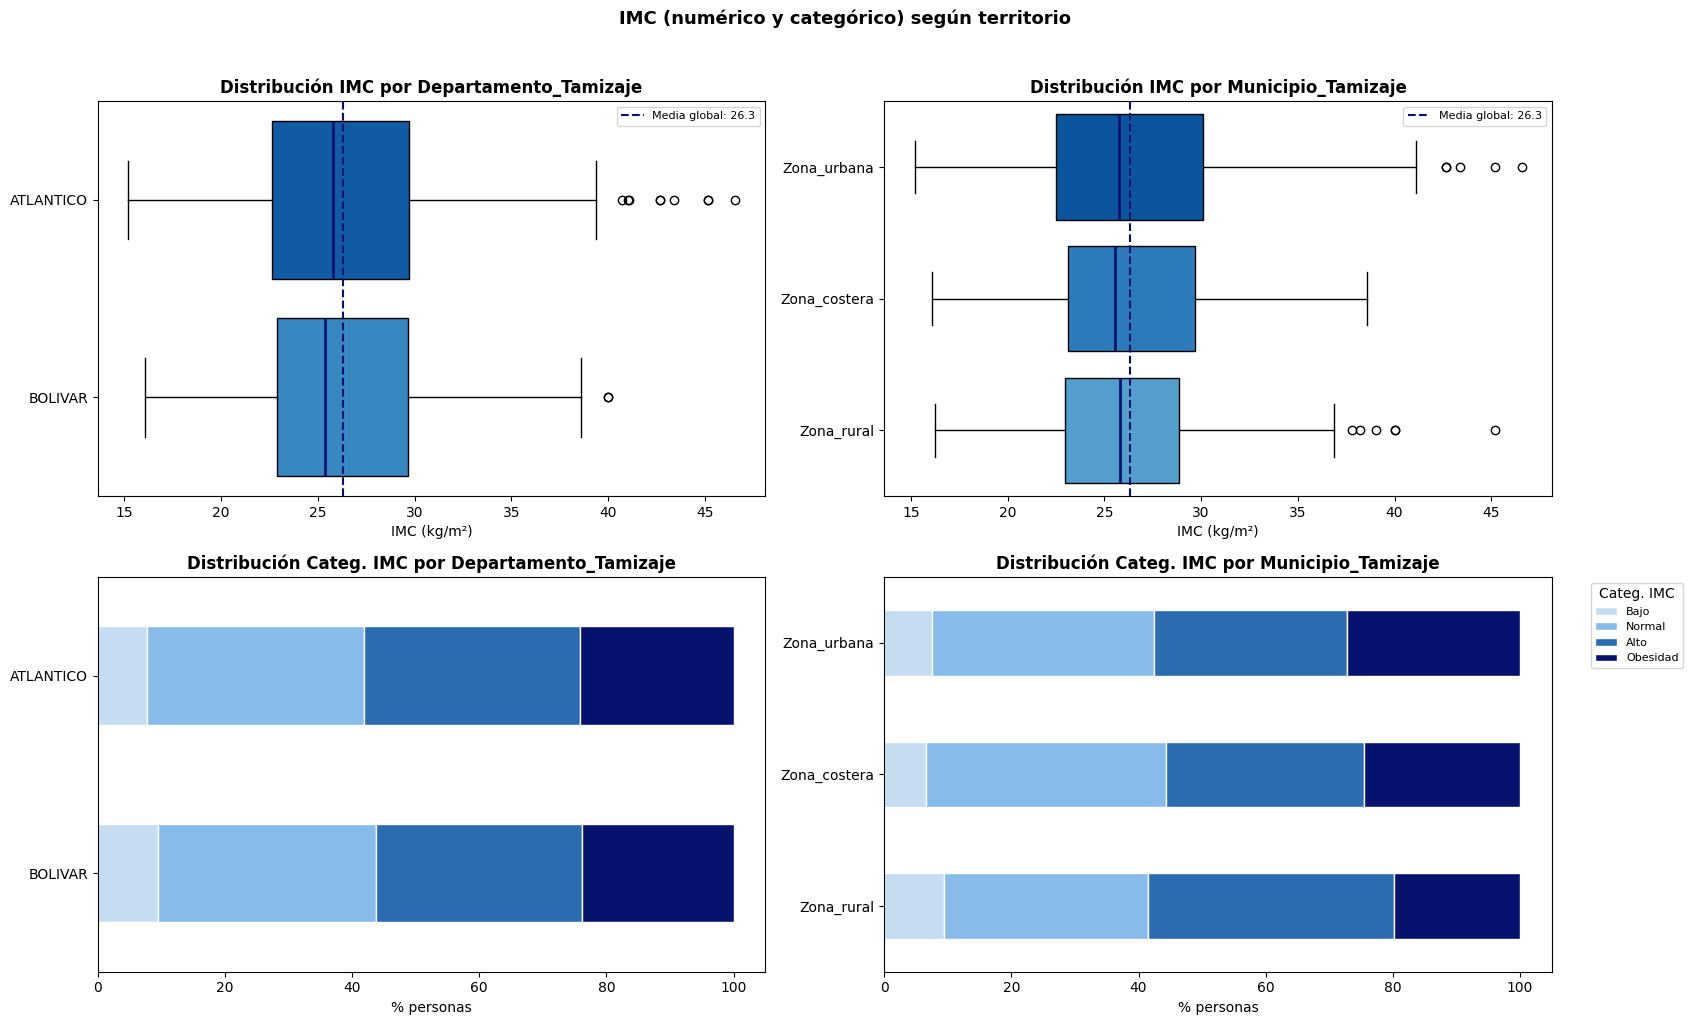

In [684]:
fig, axes = plt.subplots(2, 2, figsize=(17, 10))

top_mun = df_tfg['Municipio_Tamizaje'].value_counts().head(10).index

for j, (geo_var, subset) in enumerate([
        ('Departamento_Tamizaje', df_tfg),
        ('Municipio_Tamizaje',    df_tfg[df_tfg['Municipio_Tamizaje'].isin(top_mun)])]):

    orden_geo = subset.groupby(geo_var)['IMC'].mean().sort_values().index.tolist()
    pal = sns.color_palette("Blues", len(orden_geo) + 3)[3:]

    # Fila 1: Boxplot de IMC (horizontal)
    data_box = [subset[subset[geo_var] == cat]['IMC'].dropna().values for cat in orden_geo]
    bp = axes[0, j].boxplot(data_box, vert=False, patch_artist=True, widths=0.8,
                             medianprops=dict(color='#07126F', linewidth=2))
    for patch, color in zip(bp['boxes'], pal):
        patch.set_facecolor(color)
    axes[0, j].set_yticks(range(1, len(orden_geo) + 1))
    axes[0, j].set_yticklabels(orden_geo)
    axes[0, j].axvline(df_tfg['IMC'].mean(), color='#07126F', linestyle='--',
                       linewidth=1.5, label=f'Media global: {df_tfg["IMC"].mean():.1f}')
    axes[0, j].set_title(f'Distribución IMC por {geo_var}', fontweight='bold')
    axes[0, j].set_xlabel('IMC (kg/m²)')
    axes[0, j].legend(fontsize=8)

    # Fila 2: distribución Categoria_IMC (%)
    ct = pd.crosstab(subset[geo_var], subset['Categoria_IMC'], normalize='index') * 100
    ct = ct.reindex(columns=orden_presente)
    ct.reindex(orden_geo).plot(kind='barh', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[1, j], legend=(j == 1))
    axes[1, j].set_title(f'Distribución Categ. IMC por {geo_var}', fontweight='bold')
    axes[1, j].set_xlabel('% personas')
    axes[1, j].set_ylabel('')
    if j == 1:
        axes[1, j].legend(title='Categ. IMC', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) según territorio',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Al analizar la distribución del IMC según el territorio de procedencia, se observa que tanto el departamento del Atlántico como Bolívar presentan medianas de IMC muy similares (alrededor de 25-26 kg/m²), cercanas a la media global de 26,3 kg/m², aunque Atlántico muestra varios valores atípicos por encima de 40 kg/m² mientras que Bolívar presenta solo uno; al revisar la distribución por categorías, ambos departamentos exhiben proporciones prácticamente idénticas, con cerca del 8-9% en bajo peso, un 33-35% en normal, un 32-33% en alto y aproximadamente 24% en obesidad, evidenciando que el comportamiento del IMC no varía de forma relevante entre estos dos departamentos. Al comparar por tipo de zona (urbana, costera y rural), la zona urbana presenta la mediana de IMC más alta y un rango intercuartílico desplazado levemente hacia valores superiores en comparación con las zonas costera y rural, además de concentrar varios valores atípicos en la parte alta de la distribución; en contraste, la zona costera muestra la mediana más baja de las tres. Al observar la distribución por categorías según zona, la zona urbana presenta la mayor proporción combinada de alto y obesidad (cerca del 58%), seguida de la zona costera (alrededor del 55%), mientras que la zona rural muestra la proporción más baja en estas dos categorías combinadas (cerca del 58% también, aunque con mayor peso en la categoría alto) y la mayor proporción en bajo peso (cerca del 9%); en conjunto, estos resultados sugieren que el exceso de peso (alto y obesidad) tiende a ser ligeramente más prevalente en zonas urbanas que en zonas costeras o rurales, aunque las diferencias entre los tres tipos de zona no son sustancialmente marcadas.

##### **IMC vs función renal**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2052314364.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_tfg, x='TFG_CDK_EPI_CAL', y='IMC', palette=blues_hue,
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2052314364.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0, 0].legend(title='ERC Binaria', fontsize=8)
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2052314364.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_tfg, x='Estadio_ERC_CAL', y='IMC',
C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2052314364.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

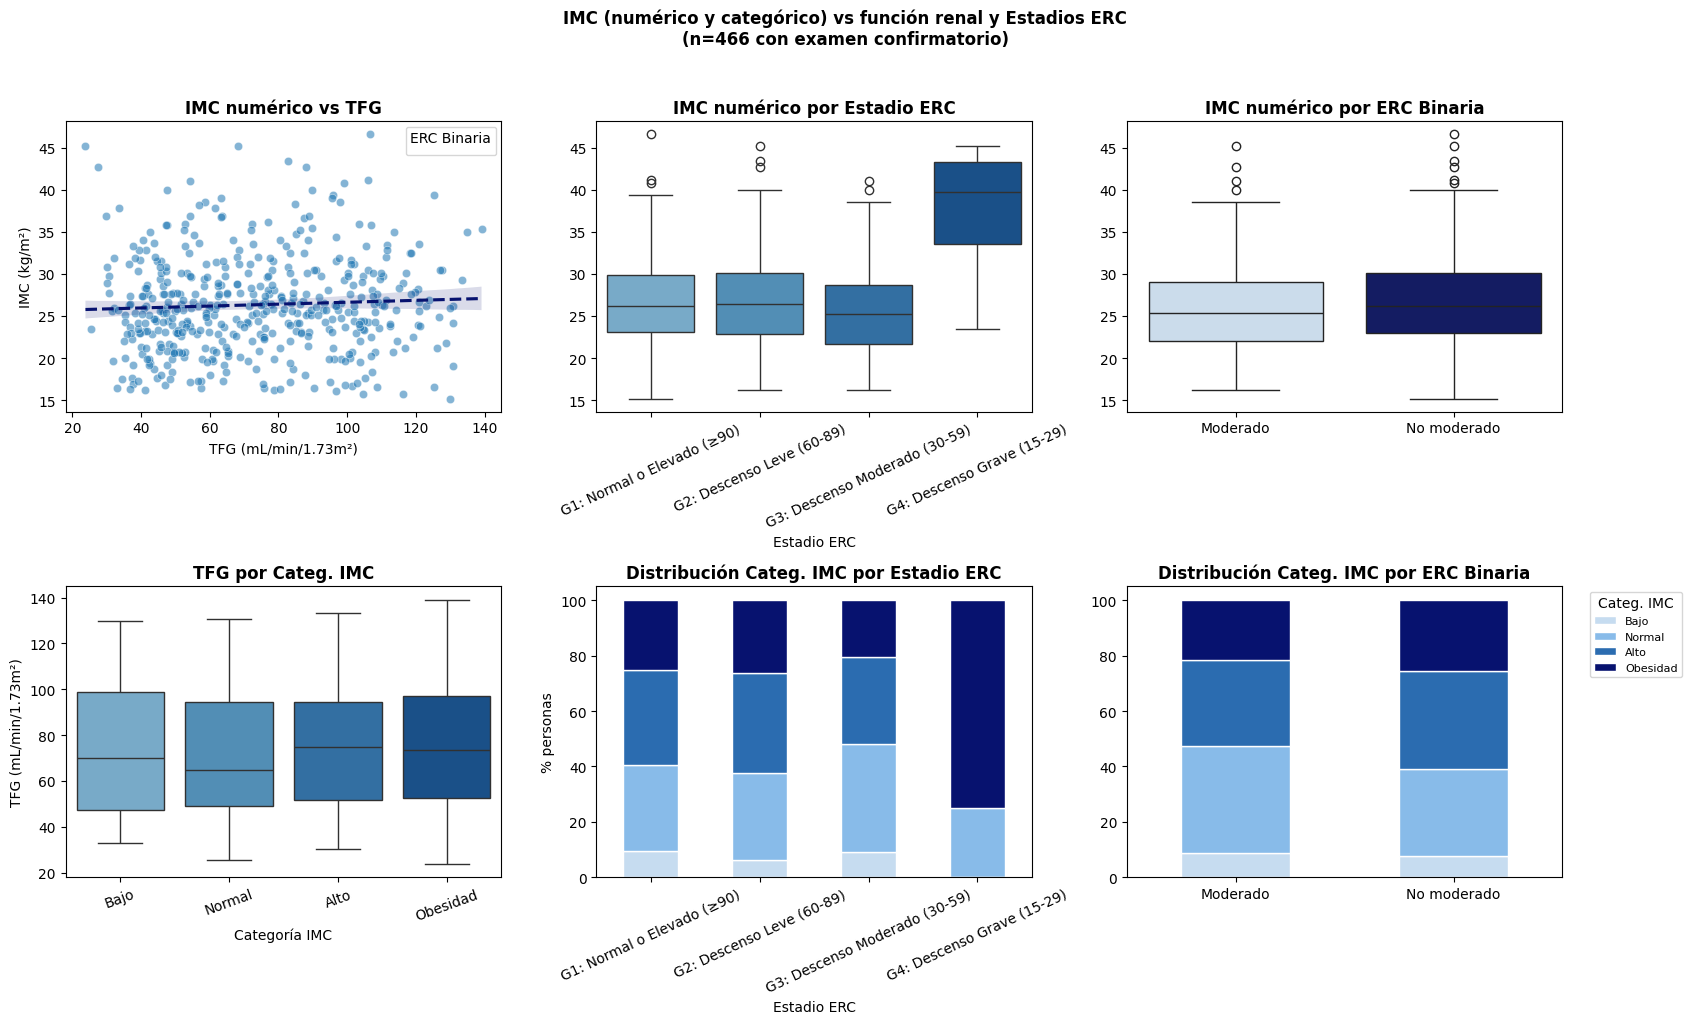

In [685]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

orden_estadio = sorted(df_tfg['Estadio_ERC_CAL'].dropna().unique())
orden_bin     = sorted(df_tfg['Estadio_ERC_Binaria'].dropna().unique())
pal_estadio   = sns.color_palette("Blues", len(orden_estadio) + 3)[3:]

sns.scatterplot(data=df_tfg, x='TFG_CDK_EPI_CAL', y='IMC', palette=blues_hue,
                alpha=0.55, ax=axes[0, 0])
sns.regplot(data=df_tfg, x='TFG_CDK_EPI_CAL', y='IMC', scatter=False,
            color='#07126F', line_kws={'linestyle': '--'}, ax=axes[0, 0])
axes[0, 0].set_title('IMC numérico vs TFG', fontweight='bold')
axes[0, 0].set_xlabel('TFG (mL/min/1.73m²)')
axes[0, 0].set_ylabel('IMC (kg/m²)')
axes[0, 0].legend(title='ERC Binaria', fontsize=8)

sns.boxplot(data=df_tfg, x='Estadio_ERC_CAL', y='IMC',
            order=orden_estadio, palette=pal_estadio, ax=axes[0, 1])
axes[0, 1].set_title('IMC numérico por Estadio ERC', fontweight='bold')
axes[0, 1].set_xlabel('Estadio ERC')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='x', rotation=25)

sns.boxplot(data=df_tfg, x='Estadio_ERC_Binaria', y='IMC',
            order=orden_bin, palette=blues_hue, ax=axes[0, 2])
axes[0, 2].set_title('IMC numérico por ERC Binaria', fontweight='bold')
axes[0, 2].set_xlabel('')
axes[0, 2].set_ylabel('')

pal_n = sns.color_palette("Blues", len(orden_presente) + 3)[3:]
sns.boxplot(data=df_tfg, x='Categoria_IMC', y='TFG_CDK_EPI_CAL',
            order=orden_presente, palette=pal_n, ax=axes[1, 0])
axes[1, 0].set_title('TFG por Categ. IMC', fontweight='bold')
axes[1, 0].set_xlabel('Categoría IMC')
axes[1, 0].set_ylabel('TFG (mL/min/1.73m²)')
axes[1, 0].tick_params(axis='x', rotation=20)

ct_est = pd.crosstab(df_tfg['Estadio_ERC_CAL'], df_tfg['Categoria_IMC'], normalize='index') * 100
ct_est = ct_est.reindex(columns=orden_presente)
ct_est.reindex(orden_estadio).plot(kind='bar', stacked=True, color=colores_cat,
                                    edgecolor='white', ax=axes[1, 1], legend=False)
axes[1, 1].set_title('Distribución Categ. IMC por Estadio ERC', fontweight='bold')
axes[1, 1].set_xlabel('Estadio ERC')
axes[1, 1].set_ylabel('% personas')
axes[1, 1].tick_params(axis='x', rotation=25)

ct_bin = pd.crosstab(df_tfg['Estadio_ERC_Binaria'], df_tfg['Categoria_IMC'], normalize='index') * 100
ct_bin = ct_bin.reindex(columns=orden_presente)
ct_bin.reindex(orden_bin).plot(kind='bar', stacked=True, color=colores_cat,
                                edgecolor='white', ax=axes[1, 2], legend=True)
axes[1, 2].set_title('Distribución Categ. IMC por ERC Binaria', fontweight='bold')
axes[1, 2].set_xlabel('')
axes[1, 2].set_ylabel('')
axes[1, 2].tick_params(axis='x', rotation=0)
axes[1, 2].legend(title='Categ. IMC', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('IMC (numérico y categórico) vs función renal y Estadios ERC\n(n=466 con examen confirmatorio)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Al analizar el IMC en relación con la función renal y los estadios de la enfermedad renal crónica (ERC), el gráfico de dispersión entre IMC y TFG muestra una línea de tendencia prácticamente plana con una banda de confianza amplia, lo que indica una asociación lineal muy débil entre ambas variables; sin embargo, al examinar el IMC numérico por estadio ERC, se observa un patrón más definido: las medianas de IMC en los estadios G1, G2 y G3 son similares entre sí (entre 25 y 26 kg/m² aproximadamente), pero el estadio G4 (descenso grave) presenta una mediana notablemente más alta, cercana a 40 kg/m², junto con un rango intercuartílico desplazado completamente hacia valores de obesidad. Esta tendencia se confirma al observar el IMC numérico por ERC binaria, donde el grupo clasificado como "No moderado" (que incluye los estadios G3 y G4) presenta una mediana de IMC levemente superior a la del grupo "Moderado" (G1 y G2), con un rango intercuartílico también un poco más amplio hacia valores altos. Por otro lado, al revisar la TFG según categoría de IMC, las medianas se mantienen relativamente similares entre las categorías bajo, normal, alto y obesidad (entre 64 y 75 mL/min/1,73m² aproximadamente), sin un patrón claro de disminución progresiva de la función renal a medida que aumenta el IMC. 

## **Correlación entre variables**

### **Relación IMC cuantitativa**

In [686]:
vars_numericas = [
    'Edad',
    'Creatinina',
    'TFG_CDK_EPI_CAL',
    'Presion_Sistolica',
    'Presion_Diastolica'
]

vars_categoricas = [
    'Departamento_Tamizaje',
    'Municipio_Tamizaje',
    'Genero',
    'Regimen_Salud',
    'Medicacion_Diabetes',
    'Hipertension',
    'Medicacion_Hipertension',
    'Colesterol_Alto',
    'Medicacion_Colesterol',
    'Insuficiencia_Renal',
    'Dialisis',
    'Proteina_Sangre_Orina',
    'Consumo_Tabaco',
    'Consumo_Alcohol',
    'Consumo_Drogas',
    'Trabajo_Cultivo',
    'Uso_Insecticidas',
    'Uso_Fungicidas',
    'Uso_Fertilizantes',
    'Ultima_Consulta_Medica',
    'Dificultad_Atencion_Medica',
    'Ultimo_Profesional_Salud',
    'Medico_Cabecera',
    'Grupo_Sanguineo',
    'Uso_AINES',
    'Tirilla_Reactiva',
    'Creatinina_Alta',
    'Estadio_ERC_CAL',
    'Estadio_ERC_Binaria'
]

#### **IMC (cuantitativo) vs variables numéricas**

In [687]:
from scipy import stats
import pandas as pd

resultados_supuestos = []

for var in vars_numericas:
    datos_par = df_tfg[['IMC', var]].dropna()
    n = len(datos_par)

    # Normalidad de IMC (Shapiro-Wilk)
    stat_imc, p_imc = stats.shapiro(datos_par['IMC'])

    # Normalidad de la variable (Shapiro-Wilk)
    stat_var, p_var = stats.shapiro(datos_par[var])

    # Ambas deben ser normales (p > 0.05) para que Pearson sea válido
    normal_imc = p_imc > 0.05
    normal_var = p_var > 0.05
    cumple_normalidad = normal_imc and normal_var

    resultados_supuestos.append({
        'Variable':              var,
        'N':                     n,
        'p Shapiro (IMC)':       p_imc,   
        'Normal IMC':            '✓' if normal_imc else '✗',
        'p Shapiro (Var)':       p_var,   
        'Normal Var':            '✓' if normal_var else '✗',
        'Cumple supuestos':      '✓ Pearson' if cumple_normalidad else '✗ Usar Spearman',
    })

tabla_supuestos = pd.DataFrame(resultados_supuestos).set_index('Variable')


display(tabla_supuestos.style
        .format({'p Shapiro (IMC)': '{:.4e}', 'p Shapiro (Var)': '{:.4e}'})
        .set_caption('Tabla 1 — Verificación de supuestos de normalidad (Shapiro-Wilk, α=0.05)'))

,N,p Shapiro (IMC),Normal IMC,p Shapiro (Var),Normal Var,Cumple supuestos
Variable,,,,,,
Edad,466,3.8698e-07,✗,3.4963e-06,✗,✗ Usar Spearman
Creatinina,466,3.8698e-07,✗,1.3785e-13,✗,✗ Usar Spearman
TFG_CDK_EPI_CAL,466,3.8698e-07,✗,9.7865e-10,✗,✗ Usar Spearman
Presion_Sistolica,466,3.8698e-07,✗,4.0934e-18,✗,✗ Usar Spearman
Presion_Diastolica,466,3.8698e-07,✗,6.2118e-15,✗,✗ Usar Spearman


Antes de evaluar las correlaciones entre el IMC y las variables de interés, se verificó el cumplimiento del supuesto de normalidad mediante la prueba de Shapiro-Wilk, considerando un nivel de significancia de 0,05. Los resultados muestran que tanto el IMC como las variables Edad, Creatinina, TFG_CDK_EPI_CAL, Presión Sistólica y Presión Diastólica presentaron valores de p muy por debajo de 0,05 (todos menores a 0,0001), lo que indica que ninguna de estas variables sigue una distribución normal en la muestra de 466 participantes. Dado que no se cumple el supuesto de normalidad en ninguno de los casos, no es apropiado utilizar el coeficiente de correlación de Pearson, ya que este requiere que las variables analizadas se distribuyan de forma normal; por esta razón, se optó por emplear el coeficiente de correlación de Spearman, que no exige este supuesto y permite evaluar relaciones monótonas (no necesariamente lineales) entre las variables, basándose en los rangos de los datos en lugar de sus valores originales.

In [688]:
resultados_corr = []

for var in vars_numericas:
    datos_par = df_tfg[['IMC', var]].dropna()
    n = len(datos_par)

    fila_supuestos = tabla_supuestos.loc[var]
    cumple_normalidad = fila_supuestos['Cumple supuestos'] == '✓ Pearson'

    if cumple_normalidad:
        r, p = stats.pearsonr(datos_par['IMC'], datos_par[var])
        metodo = 'Pearson'
    else:
        r, p = stats.spearmanr(datos_par['IMC'], datos_par[var])
        metodo = 'Spearman'

    resultados_corr.append({
        'Variable':       var,
        'N':              n,
        'Método usado':   metodo,
        'Coeficiente':    round(r, 3),
        'p-valor':        round(p, 4),
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_corr = pd.DataFrame(resultados_corr).set_index('Variable')

display(tabla_corr.style
        .format({'p-valor': '{:.4f}', 'Coeficiente': '{:.3f}'})
        .set_caption('Tabla 2 — Correlación IMC vs Variables Numéricas'))

,N,Método usado,Coeficiente,p-valor,Significativo
Variable,,,,,
Edad,466,Spearman,-0.108,0.0197,✓
Creatinina,466,Spearman,-0.053,0.2520,✗
TFG_CDK_EPI_CAL,466,Spearman,0.071,0.1278,✗
Presion_Sistolica,466,Spearman,-0.079,0.0897,✗
Presion_Diastolica,466,Spearman,-0.048,0.2987,✗


Una vez establecido el uso del coeficiente de Spearman dado el incumplimiento del supuesto de normalidad, se procedió a evaluar la correlación entre el IMC y las variables numéricas de interés. Los resultados muestran que únicamente la edad presentó una correlación estadísticamente significativa con el IMC (rho=-0,108; p=0,0197), aunque esta relación es de magnitud muy débil y de dirección negativa, lo que indicaría que, a medida que aumenta la edad, el IMC tiende a disminuir levemente, aunque esta asociación es tan baja que carece de relevancia práctica importante. Por otro lado, ninguna de las demás variables analizadas mostró una correlación estadísticamente significativa con el IMC: la creatinina presentó un coeficiente de -0,053 (p=0,2520), la TFG_CDK_EPI_CAL un coeficiente de 0,071 (p=0,1278), la presión sistólica un coeficiente de -0,079 (p=0,0897) y la presión diastólica un coeficiente de -0,048 (p=0,2987), todos con valores de p superiores a 0,05. En conjunto, estos resultados sugieren que, en esta muestra, el IMC no guarda una relación monótona relevante con los indicadores de función renal (creatinina y TFG) ni con las cifras de presión arterial, y que la única asociación significativa encontrada (con la edad) es de magnitud tan baja que no permite establecer una relación funcional clara entre ambas variables.

In [689]:
IMC_NUM_VAR_NUM_SIG = tabla_corr[tabla_corr['Significativo'] == '✓'].index.tolist()

print(IMC_NUM_VAR_NUM_SIG)

['Edad']


#### **IMC (cuantitativo) vs variables categóricas**

In [690]:
from scipy import stats
import pandas as pd

resultados_supuestos_cat = []

for var in vars_categoricas:
    datos_par = df_tfg[['IMC', var]].dropna()
    grupos_nombres = datos_par[var].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par[var] == g, 'IMC'] for g in grupos_nombres]

    # Normalidad por grupo (Shapiro-Wilk)
    p_normalidad = []
    for g_datos in grupos_datos:
        if len(g_datos) >= 3:  # Shapiro requiere al menos 3 datos
            _, p_g = stats.shapiro(g_datos)
        else:
            p_g = None
        p_normalidad.append(p_g)

    normalidad_ok = all((p is not None and p > 0.05) for p in p_normalidad)
    p_normalidad_min = min([p for p in p_normalidad if p is not None], default=None)

    # Homogeneidad de varianzas (Levene)
    stat_levene, p_levene = stats.levene(*grupos_datos)
    homocedasticidad_ok = p_levene > 0.05

    cumple_supuestos = normalidad_ok and homocedasticidad_ok

    if n_grupos == 2:
        prueba_recomendada = 'T-test' if cumple_supuestos else 'Mann-Whitney U'
    else:
        prueba_recomendada = 'ANOVA' if cumple_supuestos else 'Kruskal-Wallis'

    resultados_supuestos_cat.append({
        'Variable':              var,
        'N grupos':              n_grupos,
        'N total':               n_total,
        'p Shapiro (mín. grupo)':p_normalidad_min,
        'Normalidad':            '✓' if normalidad_ok else '✗',
        'p Levene':              p_levene,
        'Homocedasticidad':      '✓' if homocedasticidad_ok else '✗',
        'Prueba a usar':         prueba_recomendada,
    })

tabla_supuestos_cat = pd.DataFrame(resultados_supuestos_cat).set_index('Variable')

display(tabla_supuestos_cat.style
        .format({'p Shapiro (mín. grupo)': '{:.4e}', 'p Levene': '{:.4e}'})
        .set_caption('Tabla 1 — Verificación de supuestos: Normalidad (Shapiro-Wilk) y Homocedasticidad (Levene), α=0.05'))

,N grupos,N total,p Shapiro (mín. grupo),Normalidad,p Levene,Homocedasticidad,Prueba a usar
Variable,,,,,,,
Departamento_Tamizaje,2,466,2.2963e-06,✗,6.4965e-01,✓,Mann-Whitney U
Municipio_Tamizaje,3,466,6.0359e-05,✗,1.3682e-01,✓,Kruskal-Wallis
Genero,2,466,5.8353e-05,✗,9.1353e-01,✓,Mann-Whitney U
Regimen_Salud,2,466,6.0603e-07,✗,9.1178e-02,✓,Mann-Whitney U
Medicacion_Diabetes,2,466,6.5679e-06,✗,2.7498e-01,✓,Mann-Whitney U
Hipertension,2,466,9.3849e-05,✗,4.0936e-01,✓,Mann-Whitney U
Medicacion_Hipertension,2,466,8.2596e-05,✗,6.2233e-01,✓,Mann-Whitney U
Colesterol_Alto,2,466,3.6129e-05,✗,3.4021e-01,✓,Mann-Whitney U
Medicacion_Colesterol,2,466,4.4542e-06,✗,7.6677e-01,✓,Mann-Whitney U


Con el fin de comparar el IMC entre los distintos grupos definidos por las variables categóricas del estudio, se evaluaron previamente los supuestos de normalidad (mediante la prueba de Shapiro-Wilk) y de homocedasticidad u homogeneidad de varianzas (mediante la prueba de Levene) para cada una de las 29 variables analizadas, considerando un nivel de significancia de 0,05. Los resultados muestran que, en todos los casos, al menos uno de los grupos comparados no cumplió el supuesto de normalidad (valores de p siempre menores a 0,05), por lo que no fue adecuado emplear pruebas paramétricas como la prueba t de Student o el análisis de varianza (ANOVA). En cuanto a la homocedasticidad, la mayoría de las variables sí cumplieron este supuesto (p>0,05 en la prueba de Levene), aunque un grupo de variables relacionadas principalmente con hábitos y exposiciones laborales —como Proteína en sangre/orina, Consumo de alcohol, Consumo de drogas, Trabajo en cultivo, Uso de fungicidas y Uso de fertilizantes— no lo cumplieron (p<0,05), lo que indica que las varianzas del IMC no son homogéneas entre sus grupos de comparación. Dado el incumplimiento generalizado del supuesto de normalidad, independientemente del cumplimiento o no de la homocedasticidad, se determinó utilizar pruebas no paramétricas para todas las comparaciones: la prueba de Mann-Whitney U para las variables con dos grupos (la mayoría de los casos) y la prueba de Kruskal-Wallis para las variables con tres o más grupos, como Municipio_Tamizaje, Ultima_Consulta_Medica y Estadio_ERC_CAL. Estas pruebas no paramétricas resultan apropiadas en este contexto, ya que no requieren que los datos sigan una distribución normal y permiten comparar las distribuciones del IMC entre los grupos basándose en los rangos de los valores, ofreciendo así una alternativa robusta frente a la violación del supuesto de normalidad observada de manera consistente en las 29 variables evaluadas.

In [691]:
import numpy as np

def welch_anova(grupos):
    k = len(grupos)
    n_i = np.array([len(g) for g in grupos])
    media_i = np.array([g.mean() for g in grupos])
    var_i = np.array([g.var(ddof=1) for g in grupos])

    w_i = n_i / var_i
    suma_w = w_i.sum()
    media_ponderada = (w_i * media_i).sum() / suma_w

    numerador = (w_i * (media_i - media_ponderada) ** 2).sum() / (k - 1)
    denom_term = ((1 - w_i / suma_w) ** 2 / (n_i - 1)).sum()
    denominador = 1 + (2 * (k - 2) / (k ** 2 - 1)) * denom_term

    f_stat = numerador / denominador

    df1 = k - 1
    df2 = (k ** 2 - 1) / (3 * denom_term)

    p_valor = stats.f.sf(f_stat, df1, df2)
    return f_stat, p_valor


resultados_cat = []

for var in vars_categoricas:
    datos_par = df_tfg[['IMC', var]].dropna()
    grupos_nombres = datos_par[var].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par[var] == g, 'IMC'] for g in grupos_nombres]

    prueba_a_usar = tabla_supuestos_cat.loc[var, 'Prueba a usar']

    if prueba_a_usar == 'T-test clásico':
        stat, p = stats.ttest_ind(*grupos_datos, equal_var=True)
    elif prueba_a_usar == 'T-test Welch':
        stat, p = stats.ttest_ind(*grupos_datos, equal_var=False)
    elif prueba_a_usar == 'Mann-Whitney U':
        stat, p = stats.mannwhitneyu(*grupos_datos)
    elif prueba_a_usar == 'ANOVA clásico':
        stat, p = stats.f_oneway(*grupos_datos)
    elif prueba_a_usar == 'Welch ANOVA':
        stat, p = welch_anova(grupos_datos)
    else:  # Kruskal-Wallis
        stat, p = stats.kruskal(*grupos_datos)

    resultados_cat.append({
        'Variable':       var,
        'N grupos':       n_grupos,
        'N total':        n_total,
        'Prueba usada':   prueba_a_usar,
        'Estadístico':    stat,
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_resultados_cat = pd.DataFrame(resultados_cat).set_index('Variable')

display(tabla_resultados_cat.style
        .format({'Estadístico': '{:.4f}', 'p-valor': '{:.4e}'})
        .set_caption('Tabla 2 — Resultado de la prueba (T-test/Welch/ANOVA/Mann-Whitney/Kruskal-Wallis según supuestos)'))

,N grupos,N total,Prueba usada,Estadístico,p-valor,Significativo
Variable,,,,,,
Departamento_Tamizaje,2,466,Mann-Whitney U,18707.0000,8.4013e-01,✗
Municipio_Tamizaje,3,466,Kruskal-Wallis,0.5793,7.4853e-01,✗
Genero,2,466,Mann-Whitney U,28557.5000,4.6565e-02,✓
Regimen_Salud,2,466,Mann-Whitney U,21235.0000,9.5233e-01,✗
Medicacion_Diabetes,2,466,Mann-Whitney U,7877.0000,3.2628e-01,✗
Hipertension,2,466,Mann-Whitney U,25540.5000,4.9043e-01,✗
Medicacion_Hipertension,2,466,Mann-Whitney U,25457.5000,5.7364e-01,✗
Colesterol_Alto,2,466,Mann-Whitney U,15004.5000,7.9635e-01,✗
Medicacion_Colesterol,2,466,Mann-Whitney U,9648.0000,5.2414e-01,✗


Una vez aplicadas las pruebas no paramétricas correspondientes según lo establecido en el análisis de supuestos, los resultados muestran que, de las 29 variables evaluadas, solo seis presentaron diferencias estadísticamente significativas en el IMC entre sus grupos de comparación (p<0,05). En primer lugar, el género mostró una diferencia significativa (U=28557,5; p=0,0466), lo cual es consistente con lo observado previamente en los gráficos, donde las mujeres presentaban una mediana de IMC levemente superior a la de los hombres. De igual forma, el consumo de tabaco resultó significativo (U=13079,0; p=0,0208), así como contar con médico de cabecera (U=25430,5; p=0,0289) y el resultado de la tirilla reactiva (U=26666,0; p=0,0039), indicando que el IMC difiere de manera relevante entre quienes presentan o no estas condiciones. Por otro lado, en relación con los indicadores renales de interés, se encontró que la creatinina alta presentó una diferencia significativa en el IMC (U=29946,5; p=0,0354), lo que coincide con lo observado en los gráficos previos donde el grupo con creatinina alta mostraba una mediana de IMC más baja; asimismo, el estadio de ERC (Estadio_ERC_CAL) también mostró diferencias significativas entre sus cuatro grupos (H=8,6553; p=0,0342), respaldando el hallazgo visual de que el estadio G4 (descenso grave) se asociaba con valores de IMC notablemente más altos que los demás estadios. Sin embargo, es importante destacar que, al analizar la clasificación binaria de ERC (Estadio_ERC_Binaria), que agrupa los estadios G1-G2 frente a G3-G4, la diferencia no alcanzó significancia estadística (U=28130,5; p=0,0990), lo que sugiere que la asociación entre el IMC y la afectación renal se manifiesta de forma más clara al considerar los cuatro estadios por separado que al agruparlos en solo dos categorías; el resto de las variables analizadas, incluyendo departamento, municipio, régimen de salud, hipertensión, colesterol, insuficiencia renal, diálisis, antecedentes y otras exposiciones, no mostraron diferencias estadísticamente significativas en el IMC entre sus respectivos grupos.

In [692]:
IMC_NUM_VAR_CAT_SIG = tabla_resultados_cat[tabla_resultados_cat['Significativo'] == '✓'].index.tolist()

print(IMC_NUM_VAR_CAT_SIG)

['Genero', 'Consumo_Tabaco', 'Medico_Cabecera', 'Tirilla_Reactiva', 'Creatinina_Alta', 'Estadio_ERC_CAL']


### **Relación IMC categórico**

In [693]:
vars_cat_nom = [
    'Departamento_Tamizaje',
    'Municipio_Tamizaje',
    'Genero',
    'Regimen_Salud',
    'Medicacion_Diabetes',
    'Hipertension',
    'Medicacion_Hipertension',
    'Colesterol_Alto',
    'Medicacion_Colesterol',
    'Insuficiencia_Renal',
    'Dialisis',
    'Proteina_Sangre_Orina',
    'Consumo_Tabaco',
    'Consumo_Alcohol',
    'Consumo_Drogas',
    'Trabajo_Cultivo',
    'Uso_Insecticidas',
    'Uso_Fungicidas',
    'Uso_Fertilizantes',
    'Ultima_Consulta_Medica',
    'Dificultad_Atencion_Medica',
    'Ultimo_Profesional_Salud',
    'Medico_Cabecera',
    'Grupo_Sanguineo',
    'Uso_AINES',
    'Tirilla_Reactiva',
    'Creatinina_Alta',
]

vars_cat_ord = [
    'Estadio_ERC_CAL',
    'Estadio_ERC_Binaria'
]

#### **IMC (cualitativo) vs variables numéricas**

In [694]:
from scipy import stats
import pandas as pd

resultados_supuestos = []

for var in vars_numericas:
    datos_par = df_tfg[['Categoria_IMC', var]].dropna()
    grupos_nombres = datos_par['Categoria_IMC'].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par['Categoria_IMC'] == g, var] for g in grupos_nombres]

    # Normalidad por grupo (Shapiro-Wilk)
    p_normalidad = []
    for g_datos in grupos_datos:
        if len(g_datos) >= 3:  # Shapiro requiere al menos 3 datos
            _, p_g = stats.shapiro(g_datos)
        else:
            p_g = None
        p_normalidad.append(p_g)

    normalidad_ok = all((p is not None and p > 0.05) for p in p_normalidad)
    p_normalidad_min = min([p for p in p_normalidad if p is not None], default=None)

    # Homogeneidad de varianzas (Levene)
    stat_levene, p_levene = stats.levene(*grupos_datos)
    homocedasticidad_ok = p_levene > 0.05

    # Decisión de prueba (4 grupos -> rama de 3+ grupos)
    if normalidad_ok and homocedasticidad_ok:
        prueba_recomendada = 'ANOVA clásico'
    elif normalidad_ok and not homocedasticidad_ok:
        prueba_recomendada = 'Welch ANOVA'
    else:
        prueba_recomendada = 'Kruskal-Wallis'

    resultados_supuestos.append({
        'Variable':               var,
        'N grupos':               n_grupos,
        'N total':                n_total,
        'p Shapiro (mín. grupo)': p_normalidad_min,
        'Normalidad':             '✓' if normalidad_ok else '✗',
        'p Levene':               p_levene,
        'Homocedasticidad':       '✓' if homocedasticidad_ok else '✗',
        'Prueba a usar':          prueba_recomendada,
    })

tabla_supuestos = pd.DataFrame(resultados_supuestos).set_index('Variable')

display(tabla_supuestos.style
        .format({'p Shapiro (mín. grupo)': '{:.4e}', 'p Levene': '{:.4e}'})
        .set_caption('Tabla 1 — Verificación de supuestos: Normalidad (Shapiro-Wilk) y Homocedasticidad (Levene) por Categoria_IMC, α=0.05'))

,N grupos,N total,p Shapiro (mín. grupo),Normalidad,p Levene,Homocedasticidad,Prueba a usar
Variable,,,,,,,
Edad,4,466,4.5258e-04,✗,2.3097e-03,✗,Kruskal-Wallis
Creatinina,4,466,3.7873e-07,✗,8.8345e-01,✓,Kruskal-Wallis
TFG_CDK_EPI_CAL,4,466,2.3130e-06,✗,6.2132e-01,✓,Kruskal-Wallis
Presion_Sistolica,4,466,3.4775e-11,✗,2.3835e-01,✓,Kruskal-Wallis
Presion_Diastolica,4,466,1.7878e-13,✗,1.3612e-01,✓,Kruskal-Wallis


Con el propósito de comparar las variables numéricas clínicas entre las cuatro categorías de IMC (bajo, normal, alto y obesidad), se evaluaron nuevamente los supuestos de normalidad y homocedasticidad, considerando un nivel de significancia de 0,05. Los resultados de la prueba de Shapiro-Wilk muestran que ninguna de las cinco variables analizadas —Edad, Creatinina, TFG_CDK_EPI_CAL, Presión Sistólica y Presión Diastólica— cumplió el supuesto de normalidad en al menos uno de los cuatro grupos de IMC (todos los valores de p fueron menores a 0,05), lo que descarta el uso de pruebas paramétricas como el ANOVA de un factor. En cuanto a la homocedasticidad, evaluada mediante la prueba de Levene, se observa que la Creatinina, la TFG_CDK_EPI_CAL, la Presión Sistólica y la Presión Diastólica sí cumplieron este supuesto (p>0,05 en todos los casos), mientras que la Edad fue la única variable que no lo cumplió (p=0,0023), indicando que la variabilidad de la edad difiere de forma importante entre las categorías de IMC. Dado que el supuesto de normalidad no se cumplió en ninguna de las variables, independientemente del resultado de la homocedasticidad, se determinó utilizar la prueba de Kruskal-Wallis para todas las comparaciones, ya que esta prueba no paramétrica permite evaluar diferencias entre tres o más grupos sin requerir que los datos sigan una distribución normal, basándose en cambio en los rangos de los valores observados en cada categoría de IMC.

In [695]:
import numpy as np

def welch_anova(grupos):
    k = len(grupos)
    n_i = np.array([len(g) for g in grupos])
    media_i = np.array([g.mean() for g in grupos])
    var_i = np.array([g.var(ddof=1) for g in grupos])

    w_i = n_i / var_i
    suma_w = w_i.sum()
    media_ponderada = (w_i * media_i).sum() / suma_w

    numerador = (w_i * (media_i - media_ponderada) ** 2).sum() / (k - 1)
    denom_term = ((1 - w_i / suma_w) ** 2 / (n_i - 1)).sum()
    denominador = 1 + (2 * (k - 2) / (k ** 2 - 1)) * denom_term

    f_stat = numerador / denominador

    df1 = k - 1
    df2 = (k ** 2 - 1) / (3 * denom_term)

    p_valor = stats.f.sf(f_stat, df1, df2)
    return f_stat, p_valor


resultados_corr = []

for var in vars_numericas:
    datos_par = df_tfg[['Categoria_IMC', var]].dropna()
    grupos_nombres = datos_par['Categoria_IMC'].unique()
    n_grupos = len(grupos_nombres)
    n_total = len(datos_par)

    grupos_datos = [datos_par.loc[datos_par['Categoria_IMC'] == g, var] for g in grupos_nombres]

    prueba_a_usar = tabla_supuestos.loc[var, 'Prueba a usar']

    if prueba_a_usar == 'ANOVA clásico':
        stat, p = stats.f_oneway(*grupos_datos)
    elif prueba_a_usar == 'Welch ANOVA':
        stat, p = welch_anova(grupos_datos)
    else:  # Kruskal-Wallis
        stat, p = stats.kruskal(*grupos_datos)

    resultados_corr.append({
        'Variable':       var,
        'N grupos':       n_grupos,
        'N total':        n_total,
        'Prueba usada':   prueba_a_usar,
        'Estadístico':    stat,
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_corr = pd.DataFrame(resultados_corr).set_index('Variable')

display(tabla_corr.style
        .format({'Estadístico': '{:.4f}', 'p-valor': '{:.4e}'})
        .set_caption('Tabla 2 — Resultado de la prueba: Categoria_IMC vs Variables Numéricas (ANOVA/Welch/Kruskal-Wallis según supuestos)'))

,N grupos,N total,Prueba usada,Estadístico,p-valor,Significativo
Variable,,,,,,
Edad,4,466,Kruskal-Wallis,6.3130,9.7335e-02,✗
Creatinina,4,466,Kruskal-Wallis,3.6946,2.9639e-01,✗
TFG_CDK_EPI_CAL,4,466,Kruskal-Wallis,2.7993,4.2361e-01,✗
Presion_Sistolica,4,466,Kruskal-Wallis,6.4589,9.1298e-02,✗
Presion_Diastolica,4,466,Kruskal-Wallis,10.5739,1.4268e-02,✓


Una vez aplicada la prueba de Kruskal-Wallis para comparar las variables numéricas entre las cuatro categorías de IMC, los resultados muestran que únicamente la Presión Diastólica presentó una diferencia estadísticamente significativa entre los grupos (H=10,5739; p=0,0143), lo que indica que la presión diastólica varía de forma relevante según la categoría de IMC (bajo, normal, alto u obesidad). En contraste, ninguna de las demás variables analizadas mostró diferencias significativas: la Edad (H=6,3130; p=0,0973), la Creatinina (H=3,6946; p=0,2964), la TFG_CDK_EPI_CAL (H=2,7993; p=0,4236) y la Presión Sistólica (H=6,4589; p=0,0913) presentaron valores de p superiores a 0,05, lo que sugiere que estas variables no se distribuyen de forma diferente entre las categorías de IMC. Este hallazgo es particularmente relevante para los indicadores de función renal, ya que tanto la creatinina como la TFG_CDK_EPI_CAL no mostraron variación significativa entre las categorías de IMC, lo cual coincide con lo observado en los análisis gráficos previos, donde no se evidenció un patrón claro de deterioro de la función renal a medida que aumentaba el IMC. En conjunto, estos resultados refuerzan que, en esta muestra, el estado nutricional medido por categorías de IMC se asocia principalmente con diferencias en la presión diastólica, pero no logra demostrar una relación estadísticamente significativa con la edad, la creatinina, la TFG calculada ni la presión sistólica.

In [696]:
IMC_CAT_VAR_NUM_SIG = tabla_corr[tabla_corr['Significativo'] == '✓'].index.tolist()

print(IMC_CAT_VAR_NUM_SIG)

['Presion_Diastolica']


#### **IMC (cualitativo) vs variables categóricas**

In [697]:
resultados_chi = []

for var in vars_cat_nom:
    print(f"\n{'═'*60}")
    print(f"  Categoria_IMC  ×  {var}")
    print(f"{'═'*60}")
    
    # Frecuencias absolutas
    ct = pd.crosstab(df_tfg['Categoria_IMC'], df_tfg[var],
                     margins=True, margins_name='Total')
    print("\nFrecuencias absolutas:")
    print(ct.to_string())
    
    # Frecuencias relativas por fila (% dentro de cada categoría IMC)
    ct_pct = pd.crosstab(df_tfg['Categoria_IMC'], df_tfg[var],
                          normalize='index').round(3) * 100
    print("\n% por fila (dentro de cada Categ. IMC):")
    print(ct_pct.to_string())
    
    # Chi-cuadrado
    ct_chi = pd.crosstab(df_tfg['Categoria_IMC'], df_tfg[var])
    chi2, p, dof, expected = stats.chi2_contingency(ct_chi)
    sig = '✓ Significativo' if p < 0.05 else '✗ No significativo'
    print(f"\nChi² = {chi2:.4f}  |  gl = {dof}  |  p = {p:.4f}  →  {sig}")

    resultados_chi.append({
        'Variable':       var,
        'Chi2':           chi2,
        'gl':             dof,
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_chi = pd.DataFrame(resultados_chi).set_index('Variable')

IMC_CAT_VAR_CAT_NOM_SIG = tabla_chi[tabla_chi['Significativo'] == '✓'].index.tolist()

print(f"\n{'═'*60}")
print(f"Variables significativas: {IMC_CAT_VAR_CAT_NOM_SIG}")


════════════════════════════════════════════════════════════
  Categoria_IMC  ×  Departamento_Tamizaje
════════════════════════════════════════════════════════════

Frecuencias absolutas:
Departamento_Tamizaje  ATLANTICO  BOLIVAR  Total
Categoria_IMC                                   
Alto                         123       34    157
Bajo                          28       10     38
Normal                       123       36    159
Obesidad                      87       25    112
Total                        361      105    466

% por fila (dentro de cada Categ. IMC):
Departamento_Tamizaje  ATLANTICO  BOLIVAR
Categoria_IMC                            
Alto                        78.3     21.7
Bajo                        73.7     26.3
Normal                      77.4     22.6
Obesidad                    77.7     22.3

Chi² = 0.3846  |  gl = 3  |  p = 0.9434  →  ✗ No significativo

════════════════════════════════════════════════════════════
  Categoria_IMC  ×  Municipio_Tamizaje
══════════

Con el objetivo de evaluar la asociación entre la categoría de IMC y las distintas variables categóricas del estudio, se aplicó la prueba de Chi-cuadrado de independencia, considerando un nivel de significancia de 0,05. De las 26 variables analizadas, seis presentaron una asociación estadísticamente significativa con la categoría de IMC. El consumo de tabaco mostró una asociación significativa (χ²=13,7514; p=0,0033), donde llama la atención que el grupo de bajo peso presentó la proporción más alta de consumidores de tabaco (28,9%), notablemente superior a la observada en las categorías normal (10,7%), alto (10,8%) y obesidad (7,1%). De manera similar, el consumo de alcohol también resultó significativo (χ²=12,2305; p=0,0066), con el grupo de IMC alto registrando la mayor proporción de consumidores (36,3%), mientras que el grupo de bajo peso presentó la menor proporción (15,8%). El trabajo en cultivo igualmente mostró una asociación significativa (χ²=9,6164; p=0,0221), con el grupo de bajo peso presentando la proporción más alta de personas que realizan esta actividad (28,9%), en contraste con las demás categorías que oscilaron entre 10,7% y 11,9%; un patrón parecido se observó con el uso de fertilizantes (χ²=8,1823; p=0,0424), donde el grupo de bajo peso nuevamente presentó la proporción más alta de uso (18,4%) frente al resto de categorías (5,0%-7,1%).

Por otro lado, en cuanto a los indicadores relacionados con la atención en salud, el último profesional de salud consultado mostró una asociación significativa con la categoría de IMC (χ²=18,3097; p=0,0004), destacándose que el grupo normal presentó la mayor proporción de personas atendidas por especialista (34,6%), mientras que el grupo de bajo peso presentó la menor proporción (7,9%), siendo atendido mayoritariamente por medicina general (92,1%). Finalmente, entre los indicadores de función renal evaluados, únicamente la tirilla reactiva mostró una asociación estadísticamente significativa con la categoría de IMC (χ²=13,5870; p=0,0035), donde el grupo de IMC normal presentó la proporción más alta de resultado positivo (80,5%), en comparación con las categorías alto (65,6%), bajo (68,4%) y obesidad (61,6%), que presentó la proporción más baja; en contraste, la creatinina alta no mostró una asociación significativa con la categoría de IMC (χ²=5,4681; p=0,1406), lo cual es consistente con los hallazgos previos donde tampoco se evidenció una relación clara entre el IMC y este indicador de función renal.

In [698]:
print(f"Variables significativas: {IMC_CAT_VAR_CAT_NOM_SIG}")

Variables significativas: ['Consumo_Tabaco', 'Consumo_Alcohol', 'Trabajo_Cultivo', 'Uso_Fertilizantes', 'Ultimo_Profesional_Salud', 'Tirilla_Reactiva']


In [699]:
orden_categorias = {
    'Categoria_IMC': {'Bajo': 1, 'Normal': 2, 'Alto': 3, 'Obesidad': 4},
    'Estadio_ERC_CAL': {'G1: Normal o Elevado (≥90)': 1, 'G2: Descenso Leve (60-89)': 2, 'G3: Descenso Moderado (30-59)': 3, 'G4: Descenso Grave (15-29)': 4},
    'Estadio_ERC_Binaria': {'No moderado': 1, 'Moderado': 2}
}

In [700]:
from scipy import stats

resultados_ord = []

for var in vars_cat_ord:

    datos_par = df_tfg[['Categoria_IMC', var]].dropna()
    imc_codificado = datos_par['Categoria_IMC'].map(orden_categorias['Categoria_IMC'])
    var_codificada = datos_par[var].map(orden_categorias[var])

    rho, p = stats.spearmanr(imc_codificado, var_codificada)

    resultados_ord.append({
        'Variable':       var,
        'N':              len(datos_par),
        'ρ Spearman':     round(rho, 3),
        'p-valor':        p,
        'Significativo':  '✓' if p < 0.05 else '✗',
    })

tabla_corr_ord = pd.DataFrame(resultados_ord).set_index('Variable')

display(tabla_corr_ord.style
        .format({'p-valor': '{:.4e}', 'ρ Spearman': '{:.3f}'})
        .set_caption('Tabla 2 — Correlación de Spearman: Categoria_IMC vs Variables Ordinales'))

,N,ρ Spearman,p-valor,Significativo
Variable,,,,
Estadio_ERC_CAL,466,-0.050,2.7979e-01,✗
Estadio_ERC_Binaria,466,-0.076,9.9179e-02,✗


Adicionalmente, se evaluó la correlación entre la categoría de IMC y las variables ordinales relacionadas con los estadios de la enfermedad renal crónica (ERC), mediante el coeficiente de correlación de Spearman, dado que ambas son variables de naturaleza ordinal. Los resultados muestran que ni el Estadio_ERC_CAL (ρ=-0,050; p=0,2798) ni el Estadio_ERC_Binaria (ρ=-0,076; p=0,0992) presentaron una correlación estadísticamente significativa con la categoría de IMC, ya que ambos valores de p superan el umbral de 0,05. Esto indica que, en esta muestra, no existe una relación monótona relevante entre el nivel de IMC (de bajo a obesidad) y el grado de afectación renal, ya sea considerando los cuatro estadios por separado o la clasificación binaria. Este hallazgo es consistente con lo observado previamente en el análisis de Chi-cuadrado, donde tampoco se evidenció una asociación significativa entre la categoría de IMC y el Estadio_ERC_CAL al evaluarlo como variable categórica, reforzando la conclusión de que, en este conjunto de datos, el estado nutricional medido por categorías de IMC no guarda una relación clara ni estadísticamente significativa con el grado de deterioro de la función renal.

In [701]:
print("VARIABLES SIGNIFICATIVAS — IMC NUMÉRICO")
print("="*60)
print(f"IMC (numérico) vs Variables Numéricas   : {IMC_NUM_VAR_NUM_SIG}")
print(f"IMC (numérico) vs Variables Categóricas : {IMC_NUM_VAR_CAT_SIG}")

print("\nVARIABLES SIGNIFICATIVAS — IMC CATEGÓRICO")
print("="*60)
print(f"Categoria_IMC vs Variables Numéricas        : {IMC_CAT_VAR_NUM_SIG}")
print(f"Categoria_IMC vs Variables Categóricas    : {IMC_CAT_VAR_CAT_NOM_SIG}")

VARIABLES SIGNIFICATIVAS — IMC NUMÉRICO
IMC (numérico) vs Variables Numéricas   : ['Edad']
IMC (numérico) vs Variables Categóricas : ['Genero', 'Consumo_Tabaco', 'Medico_Cabecera', 'Tirilla_Reactiva', 'Creatinina_Alta', 'Estadio_ERC_CAL']

VARIABLES SIGNIFICATIVAS — IMC CATEGÓRICO
Categoria_IMC vs Variables Numéricas        : ['Presion_Diastolica']
Categoria_IMC vs Variables Categóricas    : ['Consumo_Tabaco', 'Consumo_Alcohol', 'Trabajo_Cultivo', 'Uso_Fertilizantes', 'Ultimo_Profesional_Salud', 'Tirilla_Reactiva']


## **Análisis de correlacción: Estado nutricional vs función renal**

### **Estado nutricional vs TFG**

#### ***1. Calcular la relación de los valores de estado nutricional (IMC cuantitativa) con TFG_CDK_EPI_CAL (Cuantitativa).***

Se sugiere regresión lineal y correlación (verificar supuestos)

In [702]:
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.stattools import durbin_watson
from statsmodels.nonparametric.smoothers_lowess import lowess

datos = df_tfg[['IMC', 'TFG_CDK_EPI_CAL']].dropna()
print(f"N disponible para el análisis: {len(datos)}\n")
print(datos.describe().round(3))

N disponible para el análisis: 466

           IMC  TFG_CDK_EPI_CAL
count  466.000          466.000
mean    26.323           73.286
std      5.774           26.906
min     15.191           23.820
25%     22.858           49.430
50%     25.770           71.104
75%     29.723           95.955
max     46.563          139.106


Antes de evaluar la relación entre el IMC y la TFG calculada (TFG_CDK_EPI_CAL), se realizó una descripción específica de ambas variables cuantitativas, contando con un total de 466 observaciones disponibles para el análisis, sin pérdida de datos. El IMC presentó una media de 26,32 kg/m² (desviación estándar de 5,77 kg/m²) y una mediana de 25,77 kg/m² (rango intercuartílico entre 22,86 y 29,72 kg/m²), con valores que oscilaron entre un mínimo de 15,19 kg/m² y un máximo de 46,56 kg/m², lo que confirma la presencia de un subgrupo con obesidad marcada, tal como se había observado en los análisis previos. Por su parte, la TFG_CDK_EPI_CAL mostró una media de 73,29 mL/min/1,73m² (desviación estándar de 26,91 mL/min/1,73m²) y una mediana de 71,10 mL/min/1,73m² (rango intercuartílico entre 49,43 y 95,96 mL/min/1,73m²), con un rango que va desde 23,82 hasta 139,11 mL/min/1,73m², lo que evidencia una amplia variabilidad en la función renal de la población evaluada.

##### **Supuesto de normalidad**

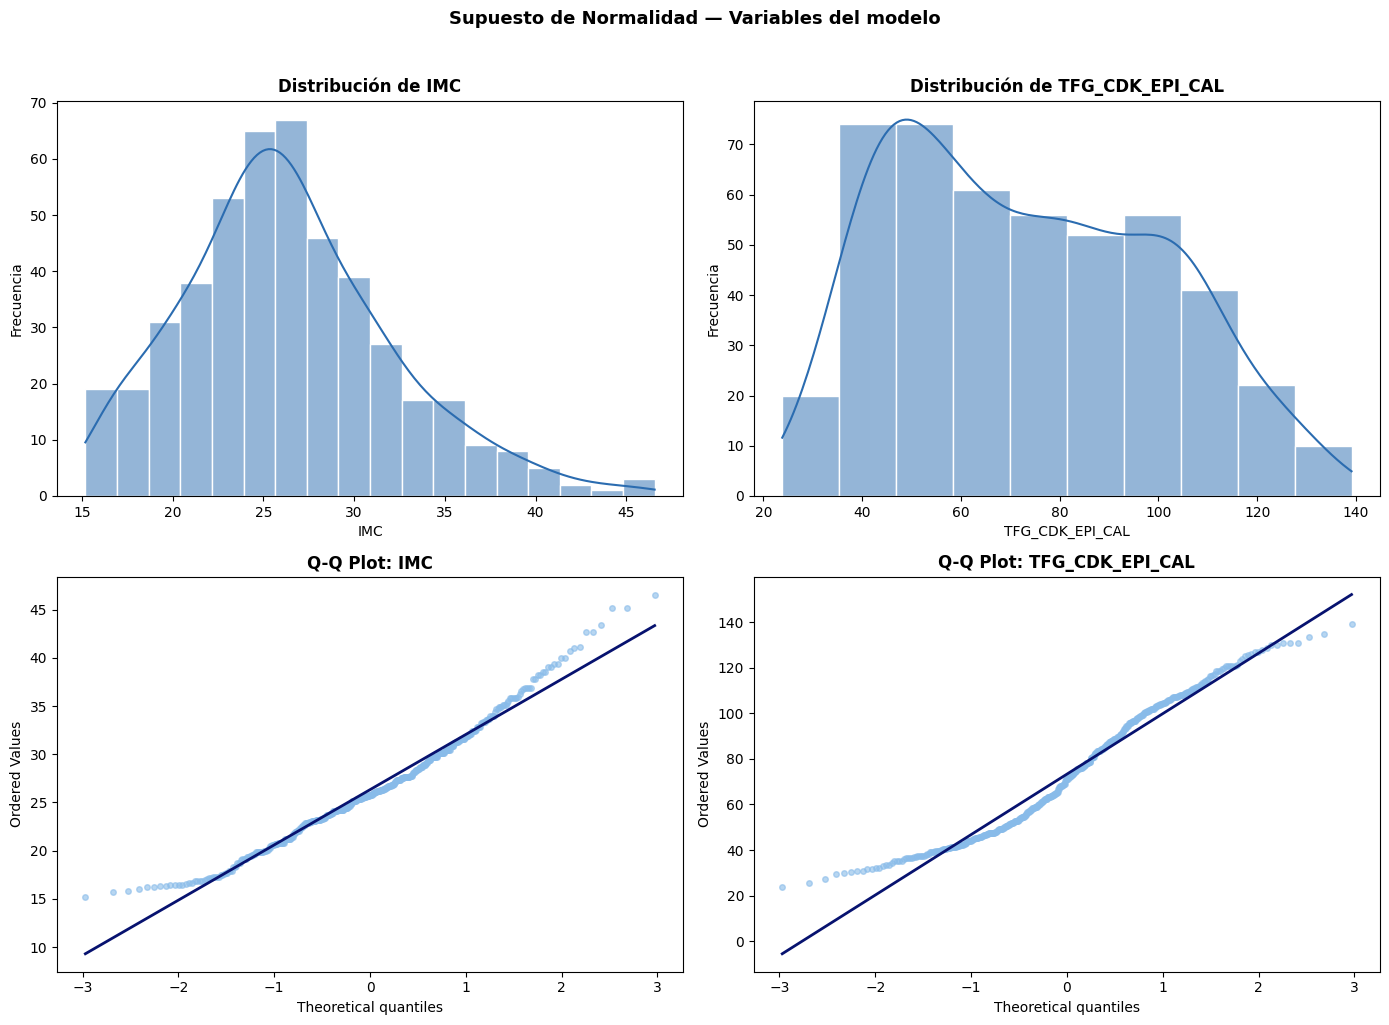

── Shapiro-Wilk ─────────────────────────────
IMC                  W=0.9751  p=0.0000003870  →  La dsitribución NO se ajusta a una distribución normal
TFG_CDK_EPI_CAL      W=0.9612  p=0.0000000010  →  La dsitribución NO se ajusta a una distribución normal


In [703]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, var in enumerate(['IMC', 'TFG_CDK_EPI_CAL']):

    sns.histplot(datos[var], kde=True, color='#2B6CB0',
                 edgecolor='white', ax=axes[0, i])
    axes[0, i].set_title(f'Distribución de {var}', fontweight='bold')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Frecuencia')

    stats.probplot(datos[var], dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f'Q-Q Plot: {var}', fontweight='bold')
    axes[1, i].get_lines()[0].set(color='#88BBE9', alpha=0.6, markersize=4)
    axes[1, i].get_lines()[1].set(color='#07126F', linewidth=2)

plt.suptitle('Supuesto de Normalidad — Variables del modelo',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("── Shapiro-Wilk ─────────────────────────────")
for var in ['IMC', 'TFG_CDK_EPI_CAL']:
    W, p = stats.shapiro(datos[var])
    resultado = '✓ Normal' if p > 0.05 else 'La dsitribución NO se ajusta a una distribución normal'
    print(f"{var:<20} W={W:.4f}  p={p:.10f}  →  {resultado}")

Con el fin de evaluar la relación entre el IMC y la TFG_CDK_EPI_CAL, se verificó previamente el supuesto de normalidad de ambas variables mediante el histograma con curva de densidad, el gráfico Q-Q y la prueba de Shapiro-Wilk. El histograma del IMC muestra una distribución con sesgo hacia la derecha, concentrándose la mayoría de los valores entre 20 y 30 kg/m², con una cola extendida hacia valores altos que llega hasta cerca de 47 kg/m²; este patrón se confirma en el gráfico Q-Q, donde los puntos se alejan de la línea de referencia tanto en el extremo inferior como, de forma más marcada, en el extremo superior, indicando que la distribución no sigue un comportamiento normal. De manera similar, el histograma de la TFG_CDK_EPI_CAL evidencia una distribución también sesgada, con mayor concentración de valores entre 40 y 60 mL/min/1,73m² y una cola hacia la derecha que se extiende hasta 139 mL/min/1,73m², lo cual se refleja igualmente en el gráfico Q-Q, donde los puntos se desvían de la línea diagonal de manera notoria, especialmente en los valores extremos. Estos hallazgos visuales se confirman estadísticamente mediante la prueba de Shapiro-Wilk, la cual mostró que tanto el IMC (W=0,9751; p=0,0000003870) como la TFG_CDK_EPI_CAL (W=0,9612; p=0,0000000010) presentan valores de p considerablemente menores a 0,05, por lo que se rechaza el supuesto de normalidad para ambas variables. En consecuencia, dado que no se cumple este supuesto, no resulta apropiado utilizar el coeficiente de correlación de Pearson para evaluar la relación entre el IMC y la TFG_CDK_EPI_CAL, siendo necesario recurrir a un método no paramétrico, como el coeficiente de correlación de Spearman, que permite analizar la asociación entre ambas variables sin requerir que se distribuyan de forma normal.

##### **Supuesto de linealidad**

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\692420040.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x='Cuartil_IMC', y='TFG_CDK_EPI_CAL',


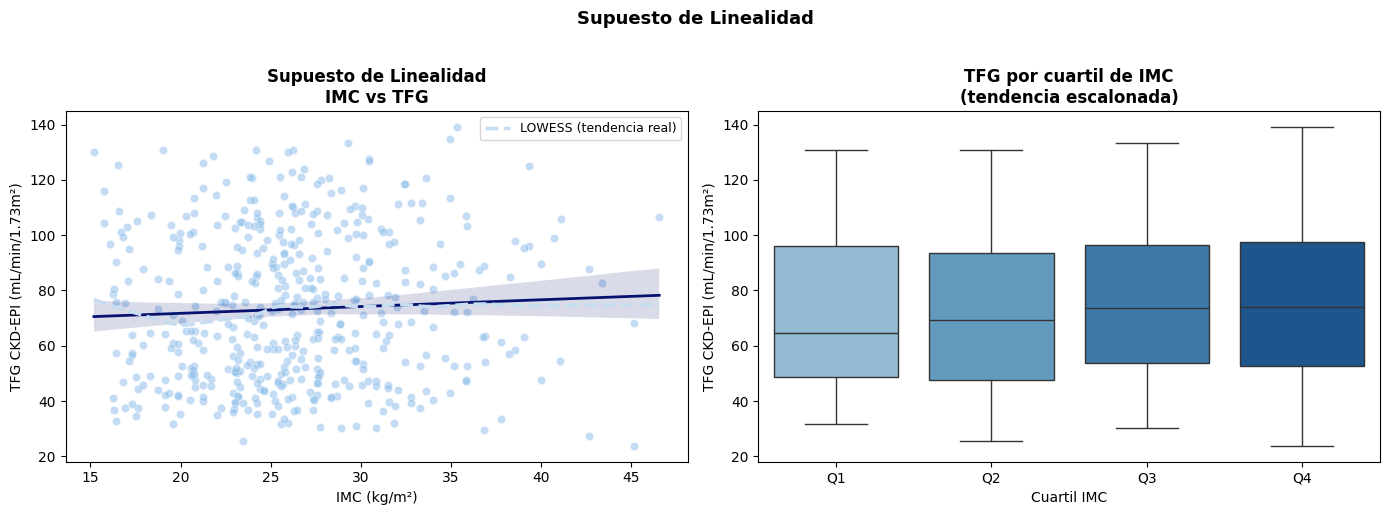

In [704]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=datos, x='IMC', y='TFG_CDK_EPI_CAL',
                color='#88BBE9', alpha=0.5, edgecolor='white', ax=axes[0])
sns.regplot(data=datos, x='IMC', y='TFG_CDK_EPI_CAL',
            scatter=False, color='#07126F',
            line_kws={'linewidth': 2, 'label': 'Regresión lineal'}, ax=axes[0])

lw = lowess(datos['TFG_CDK_EPI_CAL'], datos['IMC'], frac=0.4)
axes[0].plot(lw[:, 0], lw[:, 1], color='#C6DCF0', linewidth=2.5,
             linestyle='--', label='LOWESS (tendencia real)')
axes[0].set_title('Supuesto de Linealidad\nIMC vs TFG', fontweight='bold')
axes[0].set_xlabel('IMC (kg/m²)')
axes[0].set_ylabel('TFG CKD-EPI (mL/min/1.73m²)')
axes[0].legend(fontsize=9)

datos['Cuartil_IMC'] = pd.qcut(datos['IMC'], q=4,
                                labels=['Q1', 'Q2', 'Q3', 'Q4'])
pal_q = sns.color_palette("Blues", 6)[2:]
sns.boxplot(data=datos, x='Cuartil_IMC', y='TFG_CDK_EPI_CAL',
            palette=pal_q, ax=axes[1])
axes[1].set_title('TFG por cuartil de IMC\n(tendencia escalonada)',
                  fontweight='bold')
axes[1].set_xlabel('Cuartil IMC')
axes[1].set_ylabel('TFG CKD-EPI (mL/min/1.73m²)')

plt.suptitle('Supuesto de Linealidad', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Para evaluar el supuesto de linealidad entre el IMC y la TFG_CDK_EPI_CAL, se utilizó un gráfico de dispersión con una curva LOWESS (que representa la tendencia real de los datos sin asumir una forma específica), complementado con un análisis por cuartiles de IMC. El gráfico de dispersión muestra una nube de puntos ampliamente distribuida en todo el rango de IMC, sin un patrón visual claro entre ambas variables; la curva LOWESS resulta prácticamente plana y ligeramente ascendente, oscilando entre aproximadamente 70 y 78 mL/min/1,73m², con una banda de confianza que se mantiene relativamente estrecha a lo largo de todo el rango de IMC, lo que sugiere que no existe una relación lineal fuerte ni un patrón curvilíneo marcado entre las dos variables. Este hallazgo se confirma al observar la TFG por cuartiles de IMC, donde las medianas muestran un leve incremento progresivo desde el cuartil Q1 (mediana de aproximadamente 64 mL/min/1,73m²) hasta el cuartil Q4 (mediana de aproximadamente 74 mL/min/1,73m²), aunque este aumento es de magnitud pequeña y los rangos intercuartílicos de los cuatro grupos se superponen considerablemente entre sí. En conjunto, estos resultados indican que, si bien existe una leve tendencia de incremento de la TFG a medida que aumenta el IMC, esta relación es débil y no cumple de manera clara con el supuesto de linealidad, lo cual es consistente con lo observado previamente en el análisis de correlación de Spearman, donde no se evidenció una asociación monótona relevante entre ambas variables.

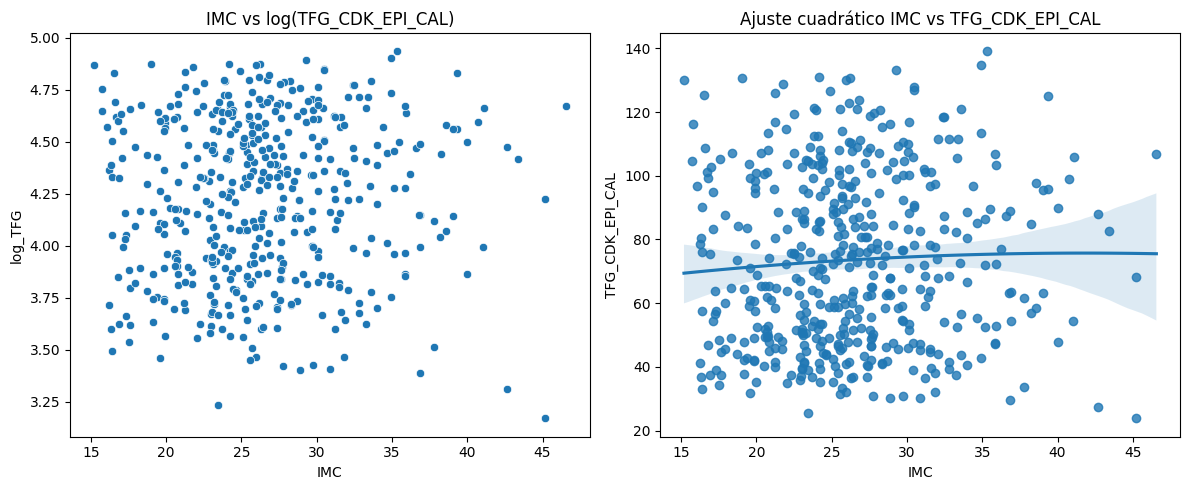

In [705]:
datos['log_TFG'] = np.log(datos['TFG_CDK_EPI_CAL'])
datos['IMC2'] = datos['IMC']**2

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.scatterplot(x='IMC', y='log_TFG', data=datos, ax=axes[0])
axes[0].set_title('IMC vs log(TFG_CDK_EPI_CAL)')

sns.regplot(x='IMC', y='TFG_CDK_EPI_CAL', data=datos, order=2, ax=axes[1])
axes[1].set_title('Ajuste cuadrático IMC vs TFG_CDK_EPI_CAL')

plt.tight_layout()
plt.show()

Como complemento al análisis de linealidad, se exploraron transformaciones alternativas de la relación entre el IMC y la TFG_CDK_EPI_CAL, incluyendo una transformación logarítmica de la TFG y un ajuste cuadrático. En el primer gráfico, al transformar la TFG mediante el logaritmo natural (log_TFG) y graficarla frente al IMC, se observa nuevamente una nube de puntos dispersa sin un patrón definido, sin que la transformación logarítmica evidencie una relación lineal más clara que la observada con la variable original, lo que sugiere que esta transformación no mejora sustancialmente el ajuste entre ambas variables. De manera similar, al aplicar un ajuste cuadrático sobre los datos originales (IMC vs TFG_CDK_EPI_CAL), la curva resultante se muestra prácticamente plana a lo largo de todo el rango de IMC, con un leve descenso inicial seguido de una estabilización alrededor de 75 mL/min/1,73m², y con una banda de confianza que se amplía notablemente en los extremos de la distribución, reflejando mayor incertidumbre en esas zonas debido a la menor cantidad de datos. En conjunto, estos resultados refuerzan lo encontrado previamente: ni la transformación logarítmica ni el ajuste cuadrático logran capturar una relación funcional más fuerte o evidente entre el IMC y la TFG, confirmando que la asociación entre ambas variables es débil, independientemente de si se evalúa de forma lineal, logarítmica o cuadrática.

##### **Correlación**

Correlación de Spearman: rho = 0.0706, p-valor = 0.1278
Interpretación: No significativa (α=0.05)


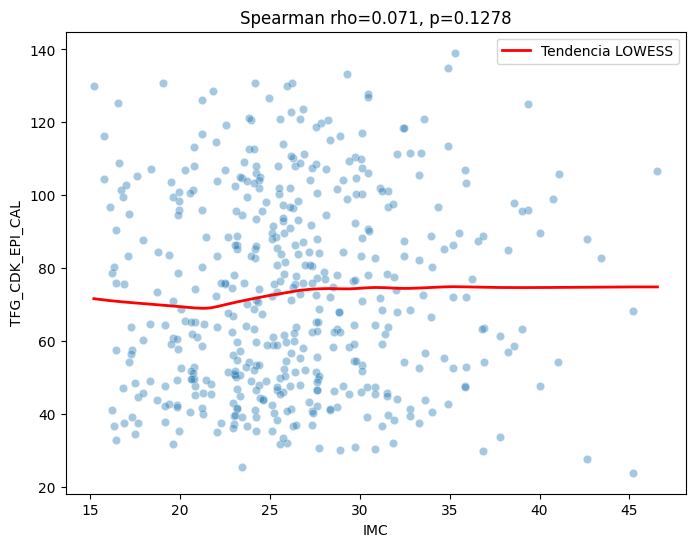

In [706]:
from scipy import stats

var1 = 'IMC'
var2 = 'TFG_CDK_EPI_CAL'

datos = df_tfg[[var1, var2]].dropna()

rho, p_valor = stats.spearmanr(datos[var1], datos[var2])

print(f"Correlación de Spearman: rho = {rho:.4f}, p-valor = {p_valor:.4f}")
print(f"Interpretación: {'Significativa' if p_valor < 0.05 else 'No significativa'} (α=0.05)")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=var1, y=var2, data=datos, alpha=0.4)
sns.regplot(x=var1, y=var2, data=datos, scatter=False,
            lowess=True, line_kws=dict(color='red', linewidth=2), label='Tendencia LOWESS')
plt.title(f'Spearman rho={rho:.3f}, p={p_valor:.4f}')
plt.xlabel(var1)
plt.ylabel(var2)
plt.legend()
plt.show()

Finalmente, se calculó el coeficiente de correlación de Spearman entre el IMC y la TFG_CDK_EPI_CAL, dado que ambas variables no cumplieron el supuesto de normalidad evidenciado previamente. El resultado mostró un coeficiente rho de 0,071 (p=0,1278), lo cual confirma que no existe una correlación estadísticamente significativa entre ambas variables, ya que el valor de p supera ampliamente el umbral de 0,05. Este hallazgo se visualiza claramente en el gráfico de dispersión, donde la nube de puntos se distribuye de manera amplia y sin un patrón definido a lo largo de todo el rango de IMC, mientras que la curva de tendencia LOWESS se mantiene prácticamente plana, oscilando entre 68 y 75 mL/min/1,73m² aproximadamente, sin mostrar cambios relevantes a medida que aumenta el IMC. En conjunto, estos resultados confirman de manera consistente lo observado a lo largo de todo el análisis de supuestos: el IMC y la TFG_CDK_EPI_CAL no presentan una relación monótona ni lineal relevante en esta muestra, lo que sugiere que, en esta población, el estado nutricional medido a través del IMC no se asocia de forma estadísticamente significativa con el nivel de función renal estimado mediante la TFG calculada.

##### **Modelo de regresión**

In [707]:
X = sm.add_constant(datos['IMC'])
y = datos['TFG_CDK_EPI_CAL']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        TFG_CDK_EPI_CAL   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.289
Date:                Mon, 22 Jun 2026   Prob (F-statistic):              0.257
Time:                        15:40:04   Log-Likelihood:                -2194.3
No. Observations:                 466   AIC:                             4393.
Df Residuals:                     464   BIC:                             4401.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         66.8307      5.821     11.481      0.0

Como complemento al análisis de correlación, se construyó un modelo de regresión lineal simple para evaluar la capacidad del IMC de predecir la TFG_CDK_EPI_CAL. Los resultados muestran que el modelo tiene un R² de 0,003, lo que indica que el IMC explica únicamente el 0,3% de la variabilidad observada en la TFG, una proporción prácticamente nula y sin relevancia práctica; este valor tan bajo se confirma con el estadístico F del modelo (F=1,289; p=0,257), el cual indica que el modelo en su conjunto no es estadísticamente significativo para predecir la TFG a partir del IMC. Al revisar el coeficiente asociado al IMC, se observa un valor de 0,2452 (error estándar de 0,216; p=0,257), lo que significa que, por cada unidad de incremento en el IMC, la TFG aumentaría en promedio 0,2452 mL/min/1,73m², aunque este efecto no es estadísticamente significativo (su intervalo de confianza del 95% va de -0,179 a 0,670, incluyendo el valor cero), por lo que no puede afirmarse que exista una relación real entre ambas variables a partir de este modelo. El término constante (intercepto) fue de 66,8307 (p<0,001), lo cual representaría el valor esperado de la TFG cuando el IMC es igual a cero, aunque este valor carece de interpretación clínica práctica al estar fuera del rango real de IMC observado en la población. En conjunto, estos resultados confirman lo encontrado previamente en el análisis de correlación de Spearman: el IMC, por sí solo, no constituye un predictor útil ni estadísticamente significativo de la TFG_CDK_EPI_CAL en esta muestra, lo que sugiere que la función renal en esta población depende de otros factores distintos al estado nutricional medido por el IMC.

#### ***2. Calcular la relación de valores de IMC (Cuantitativa) con TTFG_CDK_EPI_CAL (cuantitativa) ajustado por los valores de confusión.***

Se sugiere regresión lineal múltiple, correlación. Verificar supuestos.

In [708]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [709]:
variable_dependiente = 'TFG_CDK_EPI_CAL'

VAR_PRED_NUM = ['Edad']
VAR_PRED_CAT = [
    'Municipio_Tamizaje',
    'Genero',
    'Regimen_Salud',
    'Consumo_Tabaco',
    'Consumo_Alcohol',
    'Consumo_Drogas',
    'Trabajo_Cultivo',
    'Uso_Insecticidas',
    'Uso_Fungicidas',
    'Uso_Fertilizantes',
    'Grupo_Sanguineo'
]

todas_las_columnas = ['IMC', variable_dependiente] + VAR_PRED_NUM + VAR_PRED_CAT
datos_modelo = df_tfg[todas_las_columnas].dropna()

for var in VAR_PRED_CAT:
    print(f"{var}: {datos_modelo[var].nunique()} categorías")

Municipio_Tamizaje: 3 categorías
Genero: 2 categorías
Regimen_Salud: 2 categorías
Consumo_Tabaco: 2 categorías
Consumo_Alcohol: 2 categorías
Consumo_Drogas: 2 categorías
Trabajo_Cultivo: 2 categorías
Uso_Insecticidas: 2 categorías
Uso_Fungicidas: 2 categorías
Uso_Fertilizantes: 2 categorías
Grupo_Sanguineo: 2 categorías


In [710]:
def construir_formula(vars_incluidas, num_vars, cat_vars):
    terminos = []
    for v in vars_incluidas:
        if v in cat_vars:
            terminos.append(f"C({v})")
        else:
            terminos.append(v)
    return f"{variable_dependiente} ~ " + " + ".join(terminos)

def ajustar_modelo(vars_incluidas, num_vars, cat_vars, data):
    formula = construir_formula(vars_incluidas, num_vars, cat_vars)
    return smf.ols(formula, data=data).fit(), formula

In [711]:
orden_entrada = ['IMC', 'Edad', 'Genero', 'Regimen_Salud', 'Municipio_Tamizaje',
                  'Consumo_Tabaco', 'Consumo_Alcohol', 'Consumo_Drogas',
                  'Trabajo_Cultivo', 'Uso_Insecticidas', 'Uso_Fungicidas',
                  'Uso_Fertilizantes', 'Grupo_Sanguineo']

vars_actuales = []
modelo_anterior = None
log_resultados = []

for var in orden_entrada:
    vars_nuevas = vars_actuales + [var]
    modelo_nuevo, formula_nueva = ajustar_modelo(vars_nuevas, VAR_PRED_NUM, VAR_PRED_CAT, datos_modelo)

    if modelo_anterior is None:
        log_resultados.append({
            'variable_agregada': var,
            'formula': formula_nueva,
            'AIC': modelo_nuevo.aic,
            'BIC': modelo_nuevo.bic,
            'R2_ajustado': modelo_nuevo.rsquared_adj,
            'p_valor_F_vs_anterior': np.nan,
            'mejora_significativa': 'N/A (modelo base)'
        })
        vars_actuales = vars_nuevas
        modelo_anterior = modelo_nuevo
    else:
        comparacion = sm.stats.anova_lm(modelo_anterior, modelo_nuevo)
        p_valor_f = comparacion['Pr(>F)'].iloc[1]

        mejora = p_valor_f < 0.05
        log_resultados.append({
            'variable_agregada': var,
            'formula': formula_nueva,
            'AIC': modelo_nuevo.aic,
            'BIC': modelo_nuevo.bic,
            'R2_ajustado': modelo_nuevo.rsquared_adj,
            'p_valor_F_vs_anterior': p_valor_f,
            'mejora_significativa': 'Sí' if mejora else 'No'
        })

        if mejora:
            vars_actuales = vars_nuevas
            modelo_anterior = modelo_nuevo

tabla_log = pd.DataFrame(log_resultados)
print(tabla_log.to_string(index=False))
print(f"\nVariables finales en el modelo: {vars_actuales}")

 variable_agregada                                                                                                      formula         AIC         BIC  R2_ajustado  p_valor_F_vs_anterior mejora_significativa
               IMC                                                                                        TFG_CDK_EPI_CAL ~ IMC 4392.619861 4400.908232     0.000620                    NaN    N/A (modelo base)
              Edad                                                                                 TFG_CDK_EPI_CAL ~ IMC + Edad 4366.504788 4378.937345     0.057101           1.274810e-07                   Sí
            Genero                                                                     TFG_CDK_EPI_CAL ~ IMC + Edad + C(Genero) 4348.009781 4364.586523     0.095718           6.629799e-06                   Sí
     Regimen_Salud                                                  TFG_CDK_EPI_CAL ~ IMC + Edad + C(Genero) + C(Regimen_Salud) 4348.424577 4369.145505     0.096834

Con el propósito de evaluar la relación entre el IMC y la TFG_CDK_EPI_CAL ajustando por posibles variables de confusión, se construyó un modelo de regresión múltiple mediante un procedimiento de selección por pasos hacia adelante (se escogieron variables y se estableció orden de selección), en el cual se evaluó la mejora en el ajuste del modelo (a través del AIC, BIC, R² ajustado y la prueba F comparativa) al incorporar progresivamente cada variable adicional. El proceso partió de un modelo base que incluía únicamente el IMC, el cual explicaba un valor prácticamente nulo de la variabilidad de la TFG (R² ajustado=0,0006); al incorporar la edad, se observó una mejora estadísticamente significativa (p=1,27e-07), elevando el R² ajustado a 0,057, lo que indica que la edad aporta una capacidad explicativa considerablemente mayor que el IMC por sí solo. De manera similar, la incorporación del género (p=6,63e-06) y posteriormente del municipio de tamizaje (p=0,0086) también generaron mejoras significativas en el modelo, aumentando el R² ajustado a 0,096 y 0,110, respectivamente, mientras que el régimen de salud no aportó una mejora significativa (p=0,2107) y por tanto no fue incluido en el modelo final.

Continuando con el proceso de selección, el consumo de alcohol también demostró una contribución significativa al modelo (p=0,0083), incrementando el R² ajustado a 0,122, mientras que el resto de las variables evaluadas posteriormente —consumo de tabaco, consumo de drogas, trabajo en cultivo, uso de insecticidas, fungicidas y fertilizantes, así como el grupo sanguíneo— no generaron mejoras estadísticamente significativas en el ajuste del modelo (todos los valores de p superiores a 0,05), por lo que fueron excluidas del modelo final. De esta manera, el modelo final quedó conformado por las variables IMC, Edad, Género, Municipio_Tamizaje y Consumo_Alcohol, logrando explicar conjuntamente el 12,2% de la variabilidad de la TFG_CDK_EPI_CAL (R² ajustado=0,1219), una proporción considerablemente mayor que la obtenida con el IMC de forma aislada (0,06%), aunque sigue siendo una proporción relativamente baja en términos absolutos. Este resultado sugiere que, aunque el IMC por sí solo no logra explicar de forma relevante la variabilidad de la función renal, al considerar conjuntamente la edad, el género, la zona de residencia y el consumo de alcohol como variables de ajuste, se logra una mejor comprensión —aunque aún limitada— de los factores asociados con la TFG en esta población, evidenciando que el deterioro de la función renal en este grupo depende de múltiples factores y no únicamente del estado nutricional.

In [712]:
modelo_final, formula_final = ajustar_modelo(vars_actuales, VAR_PRED_NUM, VAR_PRED_CAT, datos_modelo)
print(f"Fórmula final: {formula_final}\n")
print(modelo_final.summary())

Fórmula final: TFG_CDK_EPI_CAL ~ IMC + Edad + C(Genero) + C(Municipio_Tamizaje) + C(Consumo_Alcohol)

                            OLS Regression Results                            
Dep. Variable:        TFG_CDK_EPI_CAL   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     11.76
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           2.82e-12
Time:                        15:40:04   Log-Likelihood:                -2161.6
No. Observations:                 466   AIC:                             4337.
Df Residuals:                     459   BIC:                             4366.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
---

Una vez ajustado el modelo final de regresión múltiple, los resultados muestran que el conjunto de variables seleccionadas (IMC, Edad, Género, Municipio de Tamizaje y Consumo de Alcohol) logra explicar el 13,3% de la variabilidad de la TFG_CDK_EPI_CAL (R²=0,133; R² ajustado=0,122), siendo este un modelo estadísticamente significativo en su conjunto (F=11,76; p=2,82e-12), lo que indica que, en general, estas variables sí aportan información relevante para explicar la función renal, aunque la proporción de variabilidad explicada continúa siendo relativamente baja. Al examinar el aporte específico del IMC dentro de este modelo ajustado, se observa que su coeficiente (0,1950; error estándar de 0,204; p=0,340) no resultó estadísticamente significativo, ya que su intervalo de confianza del 95% incluye el valor cero (-0,207 a 0,597), confirmando que, incluso al controlar por edad, género, zona de residencia y consumo de alcohol, el IMC continúa sin mostrar una relación significativa con la TFG en esta población.

En contraste, otras variables del modelo sí mostraron efectos estadísticamente significativos sobre la TFG. La edad presentó un coeficiente de -0,3426 (p<0,001), lo que indica que, por cada año adicional de edad, la TFG disminuye en promedio 0,34 mL/min/1,73m², lo cual es clínicamente coherente con el deterioro progresivo y esperado de la función renal asociado al envejecimiento. El género también resultó significativo (coeficiente=9,8602; p<0,001), mostrando que los hombres presentan, en promedio, una TFG 9,86 mL/min/1,73m² más alta que las mujeres, una vez ajustado por las demás variables del modelo. En cuanto al municipio de tamizaje, las personas de zona rural presentaron una TFG significativamente menor que las de zona costera (coeficiente=-11,0749; p=0,003), mientras que la diferencia entre zona urbana y zona costera no fue significativa (p=0,314). Finalmente, el consumo de alcohol mostró un efecto significativo (coeficiente=7,2473; p=0,008), indicando que las personas que consumen alcohol presentan, en promedio, una TFG 7,25 mL/min/1,73m² más alta que quienes no consumen, una asociación que resulta contraintuitiva desde el punto de vista clínico y que podría estar influenciada por otros factores no incluidos en el modelo, como diferencias etarias o de estilo de vida entre los grupos. En conjunto, estos resultados refuerzan que, una vez controlado por estas variables de confusión, el IMC no constituye un predictor independiente y significativo de la función renal en esta muestra, siendo la edad, el género, la zona de residencia y el consumo de alcohol los factores que realmente explican la variabilidad observada en la TFG_CDK_EPI_CAL.

##### ***Verificación de supuestos***

In [713]:
residuos = modelo_final.resid
predichos = modelo_final.fittedvalues

***Linealidad (residuos vs predictores numéricos del modelo final)***

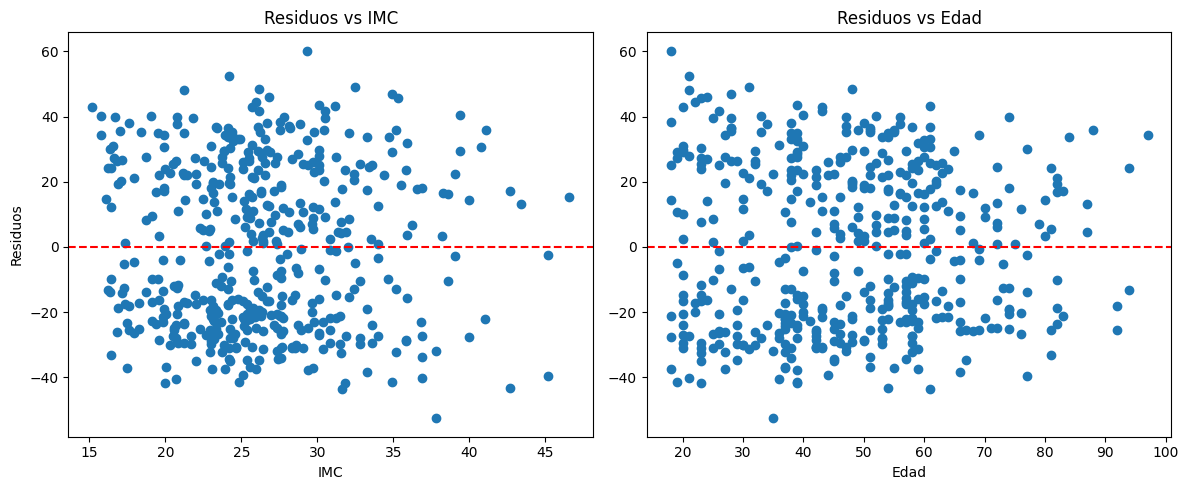

In [714]:
predictores_numericos_finales = [v for v in vars_actuales if v in VAR_PRED_NUM]

fig, axes = plt.subplots(1, len(predictores_numericos_finales) + 1, 
                           figsize=(6*(len(predictores_numericos_finales)+1), 5))
if len(predictores_numericos_finales) == 0:
    axes = [axes]

ax_idx = 0
axes[ax_idx].scatter(datos_modelo['IMC'], residuos)
axes[ax_idx].axhline(0, color='red', linestyle='--')
axes[ax_idx].set_xlabel('IMC')
axes[ax_idx].set_ylabel('Residuos')
axes[ax_idx].set_title('Residuos vs IMC')
ax_idx += 1

for var in predictores_numericos_finales:
    axes[ax_idx].scatter(datos_modelo[var], residuos)
    axes[ax_idx].axhline(0, color='red', linestyle='--')
    axes[ax_idx].set_xlabel(var)
    axes[ax_idx].set_title(f'Residuos vs {var}')
    ax_idx += 1

plt.tight_layout()
plt.show()

Para verificar el supuesto de linealidad del modelo de regresión múltiple, se examinaron los gráficos de residuos frente a las variables continuas incluidas en el modelo (IMC y Edad). En el gráfico de residuos versus IMC, se observa que los puntos se distribuyen de manera relativamente homogénea por encima y por debajo de la línea de referencia en cero, sin un patrón curvilíneo o sistemático evidente a lo largo del rango de IMC, aunque se aprecia una ligera mayor concentración de residuos negativos en la zona central (entre 25 y 30 kg/m²) y algunos residuos positivos más dispersos en los valores intermedios; sin embargo, esta distribución no sugiere una falta de linealidad marcada, sino más bien una dispersión generalizada de los datos alrededor de la línea de referencia. De manera similar, en el gráfico de residuos versus Edad, los puntos también se distribuyen de forma relativamente aleatoria alrededor del cero, sin evidenciar una tendencia clara o sistemática (como una curva ascendente o descendente) a lo largo de los distintos grupos de edad, aunque se observa una mayor dispersión de los residuos en las edades más jóvenes (entre 18 y 30 años) en comparación con una distribución algo más compacta en edades intermedias y avanzadas. En conjunto, ambos gráficos sugieren que el supuesto de linealidad del modelo se cumple de manera razonable, ya que no se identifican patrones sistemáticos (como formas de "U" o tendencias curvas) que indiquen una relación no lineal no capturada por el modelo entre las variables predictoras y la TFG_CDK_EPI_CAL.

***Homocedasticidad***

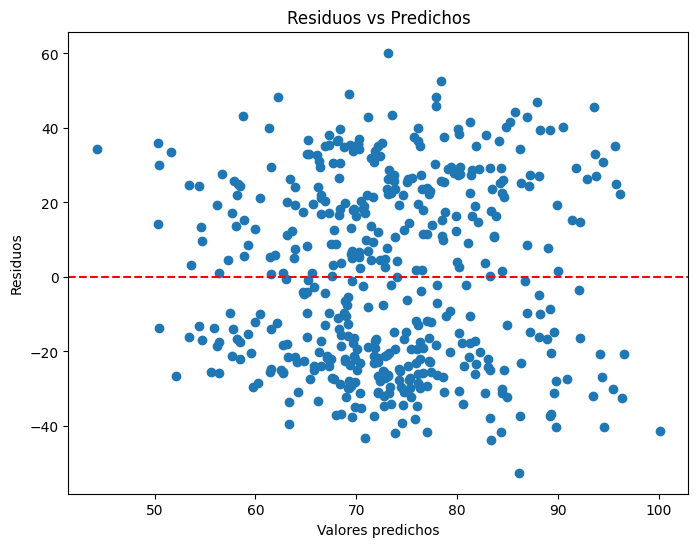

{'LM stat': 32.165444257706305, 'LM p-valor': 1.5168141424338001e-05, 'F stat': 5.671877569790016, 'F p-valor': 1.062255803801712e-05}


In [715]:
plt.figure(figsize=(8,6))
plt.scatter(predichos, residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Residuos vs Predichos')
plt.show()

X_modelo = modelo_final.model.exog
bp_test = het_breuschpagan(residuos, X_modelo)
print(dict(zip(['LM stat', 'LM p-valor', 'F stat', 'F p-valor'], bp_test)))

Para evaluar el supuesto de homocedasticidad del modelo de regresión múltiple, se examinó el gráfico de residuos versus valores predichos y se aplicó la prueba de Breusch-Pagan. Visualmente, el gráfico muestra que los residuos se distribuyen de forma relativamente dispersa a lo largo de todo el rango de valores predichos (entre 50 y 100 mL/min/1,73m² aproximadamente), sin un patrón claro en forma de "embudo" o "cono" que indicaría un cambio sistemático en la varianza de los residuos; no obstante, se observa una mayor concentración de puntos y mayor dispersión de residuos en la zona central del rango de valores predichos (entre 65 y 80), en comparación con los extremos, donde hay menos observaciones. Sin embargo, al aplicar la prueba estadística de Breusch-Pagan, los resultados muestran un estadístico LM de 32,17 (p=0,0000152) y un estadístico F de 5,67 (p=0,0000106), ambos con valores de p considerablemente menores a 0,05, lo que indica que sí existe evidencia estadística significativa de heterocedasticidad en el modelo, es decir, que la varianza de los residuos no es constante a lo largo de los distintos niveles de los valores predichos. Esto significa que, aunque la inspección visual no sugiere un patrón evidente, la prueba formal indica que el supuesto de homocedasticidad no se cumple completamente en este modelo, lo cual debe considerarse al interpretar los errores estándar y los intervalos de confianza de los coeficientes, ya que estos podrían no ser completamente precisos.

***Normalidad de residuos***

Shapiro-Wilk: estadístico=0.94651373, p-valor=0.000000000006307


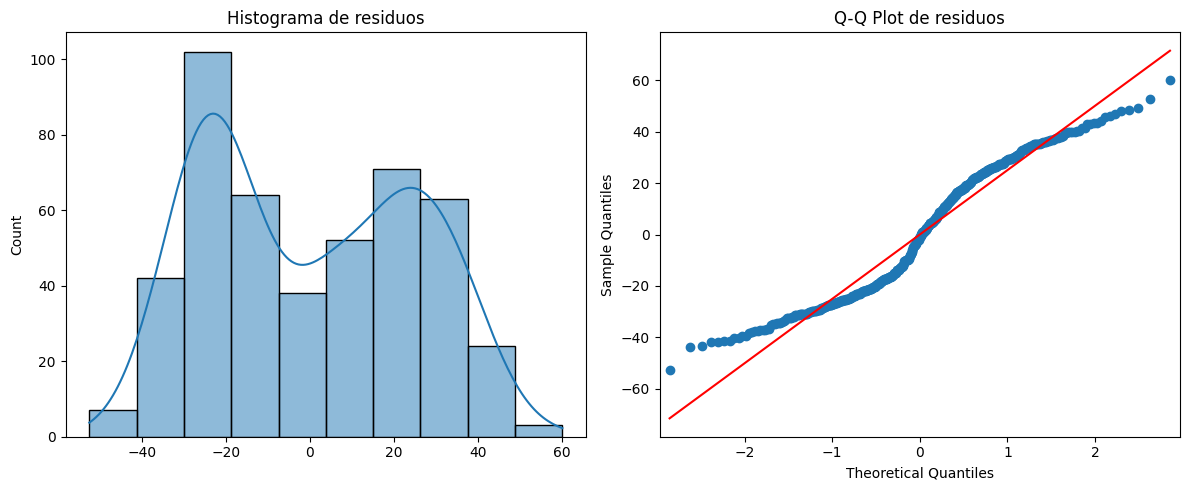

In [716]:
shapiro_resid = stats.shapiro(residuos)
print(f"Shapiro-Wilk: estadístico={shapiro_resid[0]:.8f}, p-valor={shapiro_resid[1]:.15f}")

fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(residuos, kde=True, ax=axes[0])
axes[0].set_title('Histograma de residuos')
sm.qqplot(residuos, line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot de residuos')
plt.tight_layout()
plt.show()

Para evaluar el supuesto de normalidad de los residuos del modelo de regresión múltiple, se examinó el histograma con curva de densidad, el gráfico Q-Q y la prueba de Shapiro-Wilk. El histograma de los residuos muestra una distribución claramente bimodal, con una mayor concentración de valores alrededor de -20 (cerca de 100 observaciones) y un segundo agrupamiento menos pronunciado alrededor de 20-30, alejándose notablemente de la forma de campana simétrica esperada bajo el supuesto de normalidad. Este comportamiento se confirma en el gráfico Q-Q, donde los puntos se desvían de manera considerable de la línea de referencia roja, especialmente en la zona central de la distribución (entre -20 y 20), formando un patrón escalonado que evidencia la bimodalidad observada en el histograma, además de presentar cierta desviación en los extremos. Estos hallazgos visuales se confirman estadísticamente mediante la prueba de Shapiro-Wilk, la cual arrojó un estadístico de 0,9465 con un valor de p extremadamente bajo (p=0,0000000000063), muy inferior al umbral de 0,05, por lo que se rechaza el supuesto de normalidad de los residuos. En conjunto, estos resultados indican que el modelo de regresión múltiple no cumple con el supuesto de normalidad de los residuos, lo cual, sumado a la heterocedasticidad detectada previamente, sugiere que las inferencias estadísticas del modelo (como los valores de p y los intervalos de confianza de los coeficientes) deben interpretarse con cautela, y que podría ser necesario explorar transformaciones de la variable dependiente, modelos no lineales, o el uso de métodos de estimación robustos que no dependan de estos supuestos para obtener conclusiones más confiables.

***Independencia (Durbin-Watson)***

In [717]:
dw = durbin_watson(residuos)
print(f"Durbin-Watson: {dw:.4f}")

Durbin-Watson: 2.0602


La prueba de Durbin-Watson, utilizada para evaluar el supuesto de independencia de los residuos (ausencia de autocorrelación), arrojó un valor de 2,0602, el cual se encuentra muy cercano al valor de referencia de 2, considerado como el indicador de ausencia de autocorrelación en los residuos. Dado que este estadístico oscila entre 0 y 4, donde valores cercanos a 2 indican independencia, valores cercanos a 0 sugieren autocorrelación positiva y valores cercanos a 4 sugieren autocorrelación negativa, el resultado obtenido (2,06) permite concluir que los residuos del modelo no presentan autocorrelación significativa, cumpliéndose así de manera adecuada el supuesto de independencia. Este es el único supuesto, junto con el de linealidad, que se cumple satisfactoriamente en este modelo, ya que, como se evidenció previamente, tanto el supuesto de homocedasticidad como el de normalidad de los residuos no se cumplieron, lo cual debe tenerse en cuenta al momento de interpretar de manera global la validez e idoneidad del modelo de regresión múltiple ajustado.

***Outliers (Distancia de Cook)***

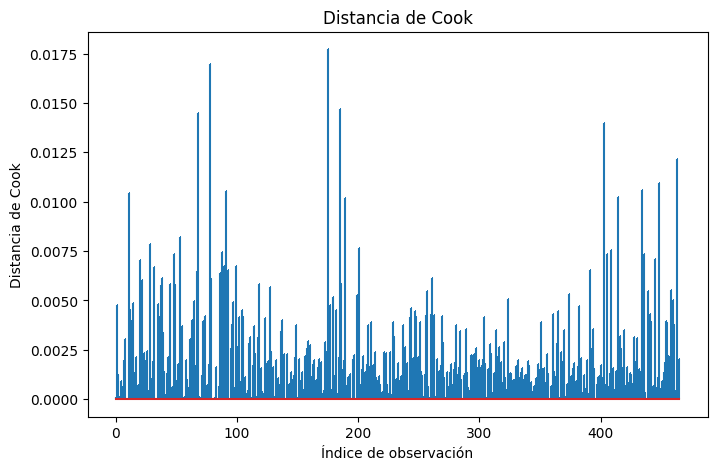

Umbral: 0.0086 | Observaciones que lo superan: 12


In [718]:
influence = modelo_final.get_influence()
cooks_d = influence.cooks_distance[0]

plt.figure(figsize=(8,5))
plt.stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
plt.xlabel('Índice de observación')
plt.ylabel('Distancia de Cook')
plt.title('Distancia de Cook')
plt.show()

umbral = 4 / len(datos_modelo)
print(f"Umbral: {umbral:.4f} | Observaciones que lo superan: {sum(cooks_d > umbral)}")

Como parte de la verificación de la influencia de observaciones individuales sobre el modelo de regresión múltiple, se calculó la distancia de Cook para cada una de las 466 observaciones. El gráfico muestra que la gran mayoría de los valores de distancia de Cook se ubican por debajo de 0,0075, distribuyéndose de manera relativamente homogénea a lo largo de las observaciones, sin un patrón sistemático evidente; sin embargo, se identificaron algunos picos puntuales que superan claramente al resto, alcanzando valores cercanos a 0,0145, 0,0170 y 0,0178 en distintas observaciones a lo largo del índice. Al aplicar el umbral de referencia de 0,0086 (basado en el criterio convencional de 4/n), se identificaron 12 observaciones que superan dicho umbral, lo que sugiere que estos puntos podrían tener una influencia desproporcionada sobre los coeficientes estimados del modelo en comparación con el resto de las observaciones. No obstante, es importante señalar que los valores máximos de distancia de Cook observados (alrededor de 0,018) son considerablemente bajos en términos absolutos, ya que generalmente se considera que una observación es altamente influyente cuando su distancia de Cook supera el valor de 1; por lo tanto, aunque estas 12 observaciones se destacan relativamente frente al resto de los datos, ninguna de ellas representa un punto de influencia extrema que comprometa de manera grave la validez general del modelo ajustado.

***Modelo de regresión múltiple con errores robustos***

Esto debido a que no se cumple el supuesto de normalidad y homocedasticidad.

In [719]:
modelo_final_robusto = smf.ols(formula_final, data=datos_modelo).fit(cov_type='HC3')
print(modelo_final_robusto.summary())

                            OLS Regression Results                            
Dep. Variable:        TFG_CDK_EPI_CAL   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     10.88
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           2.43e-11
Time:                        15:40:06   Log-Likelihood:                -2161.6
No. Observations:                 466   AIC:                             4337.
Df Residuals:                     459   BIC:                             4366.
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


Dado que el modelo original presentó evidencia de heterocedasticidad en los residuos, se reajustó el modelo de regresión múltiple utilizando errores estándar robustos a la heterocedasticidad (HC3), con el fin de obtener estimaciones más confiables de la significancia de los coeficientes. Los resultados muestran que el R² y el R² ajustado se mantuvieron idénticos a los del modelo original (R²=0,133; R² ajustado=0,122), ya que esta corrección no modifica la bondad de ajuste del modelo, sino únicamente la forma en que se calculan los errores estándar; el modelo continúa siendo estadísticamente significativo en su conjunto (F=10,88; p=2,43e-11). Al revisar nuevamente el aporte del IMC dentro de este modelo corregido, se observa que su coeficiente se mantiene en 0,1950, pero con un error estándar robusto levemente mayor (0,216 frente a 0,204 en el modelo original) y un valor de p de 0,366, confirmando una vez más que el IMC no presenta una asociación estadísticamente significativa con la TFG_CDK_EPI_CAL, incluso al utilizar una estimación más robusta de los errores.

En cuanto a las demás variables del modelo, los resultados se mantienen consistentes con el modelo original en términos de significancia: la edad continúa siendo un predictor significativo (coeficiente=-0,3426; p<0,001), confirmando que la TFG disminuye en promedio 0,34 mL/min/1,73m² por cada año adicional de edad; el género también se mantiene significativo (coeficiente=9,8602; p<0,001), con los hombres presentando en promedio una TFG 9,86 mL/min/1,73m² más alta que las mujeres. De igual forma, la zona rural continúa mostrando una TFG significativamente menor en comparación con la zona costera (coeficiente=-11,0749; p=0,003), mientras que la zona urbana no presenta diferencias significativas frente a la zona costera (p=0,312); y el consumo de alcohol se mantiene como un factor significativo (coeficiente=7,2473; p=0,009), asociándose con una TFG en promedio 7,25 mL/min/1,73m² más alta. En conjunto, el uso de errores robustos confirma la solidez de los hallazgos obtenidos en el modelo original: la edad, el género, la zona rural y el consumo de alcohol son predictores significativos de la TFG_CDK_EPI_CAL en esta población, mientras que el IMC, una vez ajustado por estas variables y corregida la heterocedasticidad, no constituye un predictor independiente y estadísticamente significativo de la función renal.

#### ***3. Valorar la relación de valores de TFG_CDK_EPI_CAL (Cuantitativa) de acuerdo con la clasificación del estado nutricional (cualitativa)***

Se sugiere Anova mixto.

In [720]:
datos_anova = df_tfg[['TFG_CDK_EPI_CAL', 'Categoria_IMC']].dropna()

print("N por categoría:")
print(datos_anova['Categoria_IMC'].value_counts())

N por categoría:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64


In [721]:
desc = datos_anova.groupby('Categoria_IMC')['TFG_CDK_EPI_CAL'].agg(
    N='count', Media='mean', DE='std', Mediana='median',
    Q1=lambda x: x.quantile(0.25), Q3=lambda x: x.quantile(0.75)
).round(2)
print(desc)

                 N  Media     DE  Mediana     Q1     Q3
Categoria_IMC                                          
Alto           157  74.75  26.58    74.86  51.58  94.44
Bajo            38  72.96  28.68    70.08  47.35  98.74
Normal         159  70.52  26.22    64.63  49.00  94.58
Obesidad       112  75.26  27.73    73.34  52.64  96.93


Para evaluar la relación entre la TFG_CDK_EPI_CAL y la clasificación del estado nutricional (Categoria_IMC), se realizó en primer lugar una descripción de la TFG según cada una de las cuatro categorías de IMC, contando con un total de 466 observaciones, distribuidas en 159 personas con estado nutricional normal, 157 con IMC alto, 112 con obesidad y 38 con bajo peso. Al comparar las medias, se observa que los valores son bastante similares entre las cuatro categorías, oscilando entre 70,52 mL/min/1,73m² en el grupo normal y 75,26 mL/min/1,73m² en el grupo con obesidad, mientras que los grupos de IMC alto (74,75) y bajo peso (72,96) presentan valores intermedios; de manera similar, las desviaciones estándar también resultan parecidas entre los grupos, ubicándose entre 26,22 y 28,68 mL/min/1,73m², lo que indica una variabilidad comparable de la función renal dentro de cada categoría. Al revisar las medianas, se mantiene un patrón similar al de las medias, con el grupo normal presentando el valor más bajo (64,63 mL/min/1,73m²) y los grupos de IMC alto (74,86) y obesidad (73,34) presentando los valores más altos, mientras que los rangos intercuartílicos (Q1-Q3) también se superponen considerablemente entre las cuatro categorías, todos ubicándose aproximadamente entre 47 y 99 mL/min/1,73m². En conjunto, esta descripción inicial sugiere que, contrario a lo que podría esperarse clínicamente, no se observa una disminución progresiva de la TFG a medida que aumenta la categoría de IMC; por el contrario, los grupos con mayor exceso de peso (alto y obesidad) presentan valores de TFG ligeramente superiores a los del grupo normal, aunque las diferencias entre todas las categorías parecen ser de magnitud pequeña, por lo que será necesario confirmar mediante las pruebas estadísticas correspondientes si estas diferencias resultan significativas.

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\3002095193.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,


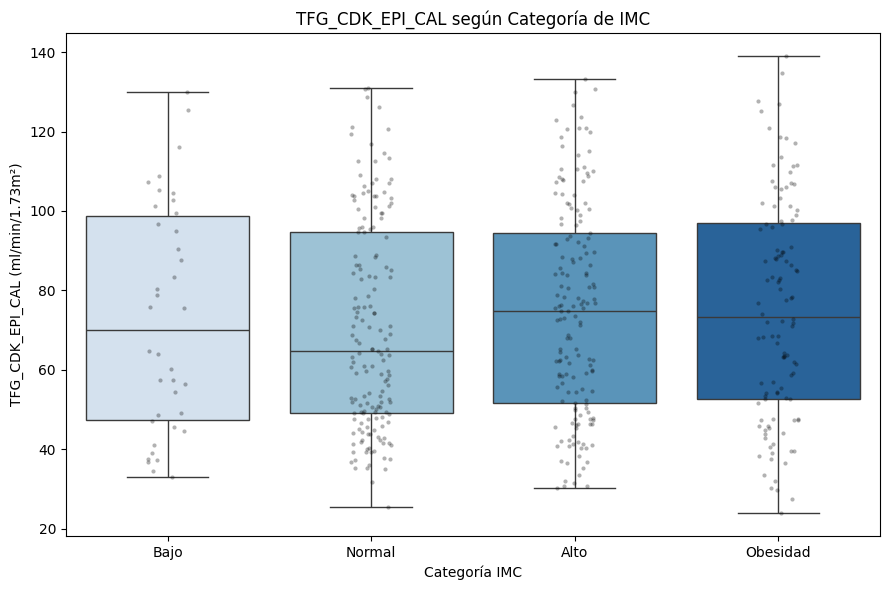

In [722]:
orden_cat = ['Bajo', 'Normal', 'Alto', 'Obesidad'] 
orden_cat = [c for c in orden_cat if c in datos_anova['Categoria_IMC'].unique()]

plt.figure(figsize=(9, 6))
sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,
            order=orden_cat, palette='Blues')
sns.stripplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,
              order=orden_cat, color='black', alpha=0.3, size=3)
plt.title('TFG_CDK_EPI_CAL según Categoría de IMC')
plt.xlabel('Categoría IMC')
plt.ylabel('TFG_CDK_EPI_CAL (ml/min/1.73m²)')
plt.tight_layout()
plt.show()

El boxplot confirma visualmente lo descrito anteriormente: las cuatro categorías de IMC presentan rangos intercuartílicos amplios y con un grado considerable de superposición entre sí, lo que refuerza la idea de que no existe una diferenciación clara de la TFG entre los distintos grupos de estado nutricional. Se observa que las categorías de IMC alto y obesidad presentan medianas muy similares entre sí (alrededor de 73-75 mL/min/1,73m²) y ligeramente superiores a las de las categorías bajo peso (70 mL/min/1,73m²) y normal (64,6 mL/min/1,73m², la más baja de las cuatro), lo cual coincide con los hallazgos numéricos previos. Asimismo, todas las categorías presentan whiskers (bigotes) que se extienden de manera amplia hasta valores cercanos a 25-30 mL/min/1,73m² en el extremo inferior y entre 130-140 mL/min/1,73m² en el extremo superior, sin presencia de valores atípicos marcados en ninguno de los cuatro grupos, lo que indica que la dispersión de los datos es comparable entre las categorías. La nube de puntos individuales (jitter) superpuesta también permite apreciar que, dentro de cada categoría, los valores de TFG se distribuyen de manera relativamente uniforme a lo largo de todo el rango, sin concentraciones marcadas en ningún extremo, lo que refleja una alta variabilidad individual dentro de cada grupo de estado nutricional. En conjunto, este gráfico respalda la conclusión preliminar de que la función renal, medida a través de la TFG, no muestra un patrón de deterioro progresivo asociado al aumento del IMC, sino más bien una distribución bastante similar entre las cuatro categorías evaluadas, lo cual deberá confirmarse mediante las pruebas de hipótesis correspondientes.

##### **Supuestos**

***Normalidad por grupo (Shapiro-Wilk)***

In [723]:
print("=" * 55)
print("SUPUESTO DE NORMALIDAD — Shapiro-Wilk por grupo")
print("=" * 55)
normalidad_ok = True
for cat in orden_cat:
    grupo = datos_anova[datos_anova['Categoria_IMC'] == cat]['TFG_CDK_EPI_CAL']
    stat, p = stats.shapiro(grupo)
    cumple = p > 0.05
    if not cumple:
        normalidad_ok = False
    print(f"{cat:15s} n={len(grupo):3d}  W={stat:.4f}  p={p:.4f}  {'✓ Normal' if cumple else ' No se ajusta a una distribución normal'}")

SUPUESTO DE NORMALIDAD — Shapiro-Wilk por grupo
Bajo            n= 38  W=0.9359  p=0.0308   No se ajusta a una distribución normal
Normal          n=159  W=0.9387  p=0.0000   No se ajusta a una distribución normal
Alto            n=157  W=0.9671  p=0.0008   No se ajusta a una distribución normal
Obesidad        n=112  W=0.9744  p=0.0299   No se ajusta a una distribución normal


Para evaluar el supuesto de normalidad de la TFG_CDK_EPI_CAL dentro de cada categoría de IMC, se aplicó la prueba de Shapiro-Wilk a cada uno de los cuatro grupos. Los resultados muestran que en las cuatro categorías se rechaza el supuesto de normalidad, ya que todos los valores de p resultaron menores a 0,05: el grupo de bajo peso (n=38; W=0,9359; p=0,0308), el grupo normal (n=159; W=0,9387; p<0,0001), el grupo de IMC alto (n=157; W=0,9671; p=0,0008) y el grupo de obesidad (n=112; W=0,9744; p=0,0299) presentaron todos una distribución que se aleja significativamente de la normalidad. Dado que el supuesto de normalidad no se cumple en ninguno de los cuatro grupos, no resulta apropiado utilizar pruebas paramétricas como el ANOVA de un factor para comparar la TFG entre las categorías de IMC, siendo necesario recurrir a una alternativa no paramétrica, como la prueba de Kruskal-Wallis, que permite comparar las distribuciones de tres o más grupos sin requerir el cumplimiento de este supuesto.

***Homogeneidad de varianzas (Levene)***

In [724]:
grupos = [datos_anova[datos_anova['Categoria_IMC'] == cat]['TFG_CDK_EPI_CAL']
          for cat in orden_cat]

stat_lev, p_lev = stats.levene(*grupos)
homogeneidad_ok = p_lev > 0.05
print("=" * 55)
print("SUPUESTO DE HOMOGENEIDAD DE VARIANZAS — Levene")
print("=" * 55)
print(f"Estadístico = {stat_lev:.4f}  p-valor = {p_lev:.4f}")
print(f"→ Homogeneidad: {'CUMPLE' if homogeneidad_ok else 'NO CUMPLE'}")

SUPUESTO DE HOMOGENEIDAD DE VARIANZAS — Levene
Estadístico = 0.5908  p-valor = 0.6213
→ Homogeneidad: CUMPLE


Adicionalmente, se evaluó el supuesto de homogeneidad de varianzas (homocedasticidad) entre las cuatro categorías de IMC mediante la prueba de Levene. Los resultados muestran un estadístico de 0,5908 con un valor de p de 0,6213, el cual es claramente superior al umbral de 0,05, indicando que sí se cumple el supuesto de homogeneidad de varianzas entre los grupos. Sin embargo, dado que el supuesto de normalidad no se cumplió en ninguna de las cuatro categorías de IMC (como se evidenció previamente con la prueba de Shapiro-Wilk), el cumplimiento aislado de la homocedasticidad no es suficiente para justificar el uso de pruebas paramétricas como el ANOVA; por lo tanto, se mantiene la decisión de utilizar la prueba no paramétrica de Kruskal-Wallis para comparar la TFG_CDK_EPI_CAL entre las categorías de estado nutricional, ya que esta prueba resulta adecuada independientemente del cumplimiento de la homocedasticidad, al no requerir el supuesto de normalidad de los datos.

***Kruskal-Wallis***

In [725]:
print("\n" + "=" * 55)
print("DECISIÓN Y PRUEBA SELECCIONADA")
print("=" * 55)

if normalidad_ok and homogeneidad_ok:
    print("→ Se cumplen ambos supuestos: ANOVA clásico de un factor")
    resultado = pg.anova(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                         between='Categoria_IMC', detailed=True)
    print(resultado)
    prueba_usada = 'anova_clasico'

else:
    print("→ No se cumple normalidad: Kruskal-Wallis (no paramétrico)")
    stat_kw, p_kw = stats.kruskal(*grupos)
    print(f"Kruskal-Wallis: H = {stat_kw:.4f}, p-valor = {p_kw:.4f}")
    prueba_usada = 'kruskal'


DECISIÓN Y PRUEBA SELECCIONADA
→ No se cumple normalidad: Kruskal-Wallis (no paramétrico)
Kruskal-Wallis: H = 2.7993, p-valor = 0.4236


Una vez confirmado el incumplimiento del supuesto de normalidad, se aplicó la prueba de Kruskal-Wallis para comparar la distribución de la TFG_CDK_EPI_CAL entre las cuatro categorías de IMC. Los resultados muestran un estadístico H de 2,7993 con un valor de p de 0,4236, el cual es claramente superior al umbral de 0,05, indicando que no existe una diferencia estadísticamente significativa en la TFG entre las categorías de estado nutricional (bajo, normal, alto y obesidad). Este resultado confirma de manera estadística lo que ya se había observado tanto en la descripción numérica como en el boxplot: aunque las medianas de TFG mostraban pequeñas diferencias entre los grupos (con el grupo normal presentando el valor más bajo y los grupos de IMC alto y obesidad los valores más altos), estas diferencias no son lo suficientemente grandes como para considerarse estadísticamente significativas. En conjunto, este hallazgo refuerza la conclusión general obtenida a lo largo de todo el análisis: en esta muestra, el estado nutricional medido a través de la categoría de IMC no se asocia de manera significativa con el nivel de función renal estimado mediante la TFG_CDK_EPI_CAL, sugiriendo que otros factores distintos al peso corporal —como la edad, el género o el consumo de alcohol, identificados previamente en el modelo de regresión múltiple— son los que realmente influyen en la variabilidad de la función renal en esta población.

***POST-HOC***

In [726]:
print("=" * 55)
print("COMPARACIONES POST-HOC POR PARES")
print("=" * 55)

if prueba_usada == 'anova_clasico':
    # Tukey HSD — asume varianzas iguales
    posthoc = pg.pairwise_tukey(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                                 between='Categoria_IMC')
    print("Post-hoc: Tukey HSD")

elif prueba_usada == 'welch':
    # Games-Howell — no asume varianzas iguales, par natural del ANOVA Welch
    posthoc = pg.pairwise_gameshowell(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                                       between='Categoria_IMC')
    print("Post-hoc: Games-Howell")

else:
    # Dunn con corrección Bonferroni — par natural de Kruskal-Wallis
    posthoc = pg.pairwise_tests(data=datos_anova, dv='TFG_CDK_EPI_CAL',
                                 between='Categoria_IMC', parametric=False,
                                 padjust='bonferroni')
    print("Post-hoc: Dunn con corrección Bonferroni")

print(posthoc.to_string(index=False))

COMPARACIONES POST-HOC POR PARES
Post-hoc: Dunn con corrección Bonferroni
     Contrast      A        B  Paired  Parametric   U-val alternative    p-unc   p-corr   p-adjust    hedges
Categoria_IMC   Alto     Bajo   False       False  3129.0   two-sided 0.641140 1.000000 bonferroni  0.066034
Categoria_IMC   Alto   Normal   False       False 13676.0   two-sided 0.141470 0.848821 bonferroni  0.159803
Categoria_IMC   Alto Obesidad   False       False  8718.5   two-sided 0.907607 1.000000 bonferroni -0.018514
Categoria_IMC   Bajo   Normal   False       False  3116.5   two-sided 0.763507 1.000000 bonferroni  0.090997
Categoria_IMC   Bajo Obesidad   False       False  2021.0   two-sided 0.645368 1.000000 bonferroni -0.081535
Categoria_IMC Normal Obesidad   False       False  8019.0   two-sided 0.163867 0.983200 bonferroni -0.175703


Aunque la prueba de Kruskal-Wallis no mostró una diferencia global significativa entre los cuatro grupos, se realizaron de manera complementaria las comparaciones post-hoc por pares mediante la prueba de Dunn con corrección de Bonferroni, con el fin de confirmar si existía alguna diferencia específica entre pares de categorías que pudiera no haberse detectado en la prueba global. Los resultados muestran que ninguna de las seis comparaciones por pares resultó estadísticamente significativa después de la corrección por comparaciones múltiples (todos los valores de p ajustados fueron superiores a 0,05): Alto vs. Bajo (p-corr=1,000), Alto vs. Normal (p-corr=0,849), Alto vs. Obesidad (p-corr=1,000), Bajo vs. Normal (p-corr=1,000), Bajo vs. Obesidad (p-corr=1,000) y Normal vs. Obesidad (p-corr=0,983), siendo esta última la comparación que más se acercó a la significancia, aunque sin alcanzarla. Adicionalmente, al observar los tamaños del efecto (Hedges' g), todos los valores resultaron muy pequeños (entre -0,18 y 0,16 en valor absoluto), lo que indica que, incluso en las comparaciones con menor valor de p, la magnitud de la diferencia entre los grupos es trivial desde el punto de vista práctico. En conjunto, estos resultados confirman de manera consistente la ausencia de diferencias significativas en la TFG_CDK_EPI_CAL entre cualquier par de categorías de estado nutricional, respaldando la conclusión general de que el IMC, evaluado tanto de forma cuantitativa como categórica, no constituye un factor asociado de manera relevante con el nivel de función renal en esta población de estudio.

***Distribuciones de los grupos***

C:\Users\Mari\AppData\Local\Temp\ipykernel_2092\2385310384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,


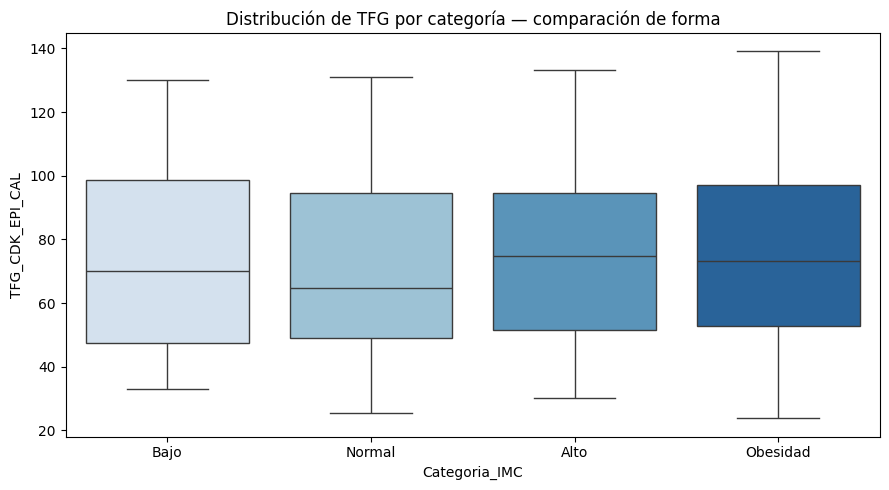

In [727]:
plt.figure(figsize=(9, 5))
sns.boxplot(x='Categoria_IMC', y='TFG_CDK_EPI_CAL', data=datos_anova,
            order=orden_cat, palette='Blues')
plt.title('Distribución de TFG por categoría — comparación de forma')
plt.tight_layout()
plt.show()

Este gráfico, que compara la forma de la distribución de la TFG_CDK_EPI_CAL entre las cuatro categorías de IMC, ratifica de manera clara los hallazgos obtenidos a lo largo de todo el análisis estadístico. Se observa que las cajas de las cuatro categorías presentan amplitudes similares y un alto grado de superposición entre sí, lo que refleja una dispersión comparable de los datos dentro de cada grupo; asimismo, las medianas se mantienen relativamente cercanas entre las categorías, con el grupo normal mostrando el valor más bajo (cerca de 64,6 mL/min/1,73m²) y los grupos de IMC alto y obesidad presentando valores levemente superiores (alrededor de 73-75 mL/min/1,73m²), mientras que el grupo de bajo peso se ubica en una posición intermedia (70 mL/min/1,73m²). Adicionalmente, los bigotes de las cuatro categorías se extienden de manera similar, alcanzando valores mínimos cercanos a 24-33 mL/min/1,73m² y máximos cercanos a 130-140 mL/min/1,73m², sin presencia de valores atípicos en ninguno de los grupos, lo que indica que la forma general de la distribución —y no solo sus valores centrales— es bastante consistente entre las cuatro categorías de estado nutricional. En conjunto, esta visualización confirma de manera definitiva lo establecido mediante la prueba de Kruskal-Wallis y los análisis post-hoc: la categoría de IMC no genera diferencias relevantes, ni en posición ni en forma, en la distribución de la TFG_CDK_EPI_CAL, consolidando la conclusión de que el estado nutricional, evaluado de forma categórica, no constituye un factor determinante de la función renal en esta población.

## **Relación estado nutricional (Cualitativa) vs estadios de ERC**

#### ***4. Valorar la relación de valores de estado nutricional (cualitativa) con Estadios de ERC. Primero sin estratificar y luego estratificado por presencia de HTA y en otra DM.***

In [728]:
VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC = 'Estadio_ERC_CAL'      
VAR_HTA = 'Hipertension'
VAR_DM  = 'Medicacion_Diabetes'   

cols = [VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]
datos_chi = df_tfg[cols].dropna()

print(f"Observaciones disponibles: {len(datos_chi)}")
print(f"\nCategorías de {VAR_ESTADO_NUT}:\n{datos_chi[VAR_ESTADO_NUT].value_counts()}")
print(f"\nCategorías de {VAR_ERC}:\n{datos_chi[VAR_ERC].value_counts()}")
print(f"\nCategorías de {VAR_HTA}:\n{datos_chi[VAR_HTA].value_counts()}")
print(f"\nCategorías de {VAR_DM}:\n{datos_chi[VAR_DM].value_counts()}")

Observaciones disponibles: 466

Categorías de Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64

Categorías de Estadio_ERC_CAL:
Estadio_ERC_CAL
G3: Descenso Moderado (30-59)    177
G2: Descenso Leve (60-89)        149
G1: Normal o Elevado (≥90)       136
G4: Descenso Grave (15-29)         4
Name: count, dtype: int64

Categorías de Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Categorías de Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


Para evaluar la relación entre el estado nutricional (Categoria_IMC) y los estadios de la enfermedad renal crónica (Estadio_ERC_CAL), se cuenta con un total de 466 observaciones disponibles para el análisis, distribuidas en cuatro categorías de IMC: normal (159 personas), alto (157), obesidad (112) y bajo peso (38). En cuanto a los estadios de ERC, la distribución muestra que el estadio G3 (descenso moderado de la función renal, TFG entre 30-59) es el más frecuente con 177 personas, seguido del estadio G2 (descenso leve, TFG 60-89) con 149 personas y el estadio G1 (función renal normal o elevada, TFG≥90) con 136 personas, mientras que el estadio G4 (descenso grave, TFG 15-29) presenta apenas 4 personas, siendo la categoría con menor representación. Este análisis se realizará inicialmente sin estratificar por ninguna variable adicional, y posteriormente se estratificará según la presencia de hipertensión (donde 268 personas no la presentan y 198 sí) y según el uso de medicación para diabetes (donde 433 personas no la usan y solo 33 sí), con el fin de evaluar si la relación entre el estado nutricional y los estadios de ERC se mantiene consistente, o si varía, al considerar estos dos factores clínicos relevantes de manera independiente.

##### ***Chi-cuadrado***

In [729]:
def ajustar_logistico_ordinal(data, formula_vars, var_dep, titulo=''):
    X = pd.get_dummies(data[formula_vars], drop_first=True).astype(float)
    y = data[var_dep]

    modelo = OrderedModel(y, X, distr='logit')
    resultado = modelo.fit(method='bfgs', disp=False)

    print(f"\n{'='*65}")
    print(f"  {titulo}")
    print(f"  n = {len(data)}")
    print(f"{'='*65}")
    print(resultado.summary())

    params = resultado.params
    conf = resultado.conf_int()
    or_table = pd.DataFrame({
        'OR': np.exp(params),
        'IC_2.5%': np.exp(conf[0]),
        'IC_97.5%': np.exp(conf[1]),
        'p_valor': resultado.pvalues
    })
    or_table = or_table[~or_table.index.str.contains('/')]
    print(f"\nOdds Ratios:")
    print(or_table.round(4))

    return resultado, or_table

In [730]:
# Chi-cuadrado con verificación de supuesto (frecuencias esperadas)
def chi_cuadrado_completo(data, var_fila, var_col, titulo=''):
    tabla = pd.crosstab(data[var_fila], data[var_col])
    tabla_pct = pd.crosstab(data[var_fila], data[var_col], normalize='index') * 100

    chi2, p, dof, esperadas = stats.chi2_contingency(tabla)

    # Verificar supuesto: frecuencias esperadas >= 5 en al menos 80% de las celdas
    pct_celdas_ok = (esperadas >= 5).sum() / esperadas.size
    supuesto_ok = pct_celdas_ok >= 0.80

    print(f"\n{'='*60}")
    print(f"  {titulo}")
    print(f"{'='*60}")
    print(f"\nTabla de contingencia (n):")
    print(tabla)
    print(f"\nTabla de contingencia (% por fila):")
    print(tabla_pct.round(1))
    print(f"\nFrecuencias esperadas:")
    print(pd.DataFrame(esperadas.round(1), index=tabla.index, columns=tabla.columns))
    print(f"\n→ Supuesto frecuencias esperadas ≥ 5: {'✓ CUMPLE' if supuesto_ok else '✗ NO CUMPLE'} ({pct_celdas_ok*100:.0f}% celdas ok)")

    if supuesto_ok:
        print(f"\nChi-cuadrado: χ²={chi2:.4f}, gl={dof}, p-valor={p:.4f}")
        print(f"→ {'Asociación significativa' if p < 0.05 else 'Sin asociación significativa'} (α=0.05)")
    else:
        if tabla.shape == (2, 2):
            odds, p_fisher = stats.fisher_exact(tabla)
            print(f"\nFisher exacto: OR={odds:.4f}, p-valor={p_fisher:.4f}")
            print(f"→ {'Asociación significativa' if p_fisher < 0.05 else 'Sin asociación significativa'} (α=0.05)")
        else:
            print(f"\nTabla > 2x2, se reporta Chi-cuadrado con advertencia de frecuencias bajas:")
            print(f"Chi-cuadrado: χ²={chi2:.4f}, gl={dof}, p-valor={p:.4f}")
            print(f"→ {'Asociación significativa' if p < 0.05 else 'Sin asociación significativa'} (α=0.05) ⚠️ interpretar con cautela")

    return tabla, chi2, p

In [731]:
def plot_contingencia(data, var_fila, var_col, titulo=''):
    n = pd.crosstab(data[var_fila], data[var_col], margins=True, margins_name='Total')
    pct = pd.crosstab(data[var_fila], data[var_col], normalize='index') * 100

    # Combinar n y % en una sola tabla: "n (xx.x%)"
    tabla_combinada = pd.DataFrame(index=n.index, columns=n.columns)
    for col in n.columns:
        for fila in n.index:
            if fila == 'Total' or col == 'Total':
                tabla_combinada.loc[fila, col] = str(n.loc[fila, col])
            else:
                tabla_combinada.loc[fila, col] = f"{n.loc[fila, col]} ({pct.loc[fila, col]:.1f}%)"

    fig, ax = plt.subplots(figsize=(12, len(n) * 0.7 + 1.5))
    ax.axis('off')

    tabla_plot = ax.table(
        cellText=tabla_combinada.values,
        rowLabels=tabla_combinada.index,
        colLabels=tabla_combinada.columns,
        cellLoc='center',
        loc='center'
    )

    tabla_plot.auto_set_font_size(False)
    tabla_plot.set_fontsize(10)
    tabla_plot.scale(1.2, 1.8)

    n_cols = len(tabla_combinada.columns)
    n_filas = len(tabla_combinada.index)

    for (fila, col), celda in tabla_plot.get_celld().items():
        celda.set_edgecolor('#cccccc')
        if fila == 0:  # encabezado columnas
            celda.set_facecolor('#07126F')
            celda.set_text_props(color='white', fontweight='bold')
        elif col == -1:  # encabezado filas (rowLabels)
            if tabla_combinada.index[fila - 1] == 'Total':
                celda.set_facecolor('#d0d0d0')
                celda.set_text_props(fontweight='bold')
            else:
                celda.set_facecolor('#e8eaf6')
                celda.set_text_props(fontweight='bold')
        elif tabla_combinada.index[fila - 1] == 'Total':
            celda.set_facecolor('#d0d0d0')
            celda.set_text_props(fontweight='bold')
        elif fila % 2 == 0:
            celda.set_facecolor('#f5f5f5')
        else:
            celda.set_facecolor('white')

    plt.title(titulo, fontweight='bold', fontsize=12, pad=15)
    plt.tight_layout()
    plt.show()

***Sin estratificar***


  Estado nutricional vs Estadio ERC — Sin estratificar

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     47                         54   
Bajo                                     13                          9   
Normal                                   42                         47   
Obesidad                                 34                         39   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        56                           0  
Bajo                                        16                           0  
Normal                                      69                           1  
Obesidad                                    36                           3  

Tabla de

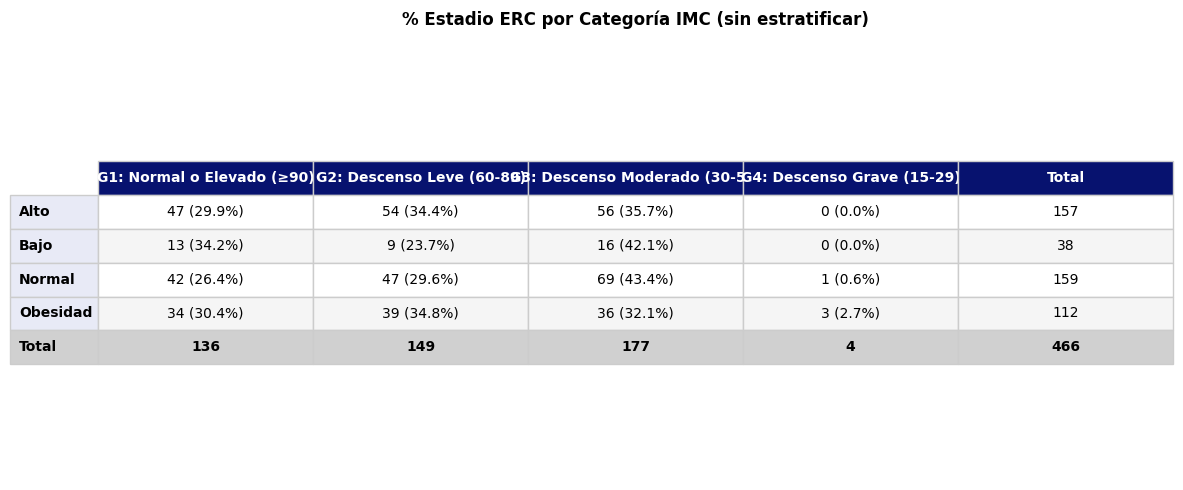

In [732]:
tabla_global, chi2_global, p_global = chi_cuadrado_completo(
    datos_chi, VAR_ESTADO_NUT, VAR_ERC,
    titulo='Estado nutricional vs Estadio ERC — Sin estratificar'
)
plot_contingencia(datos_chi, VAR_ESTADO_NUT, VAR_ERC,
                  titulo='% Estadio ERC por Categoría IMC (sin estratificar)')

Al evaluar la relación entre el estado nutricional (Categoria_IMC) y los estadios de la enfermedad renal crónica (Estadio_ERC_CAL) sin estratificar por ninguna otra variable, se observa en la tabla de contingencia que la distribución porcentual de los estadios de ERC es bastante similar entre las cuatro categorías de IMC; por ejemplo, el estadio G3 (descenso moderado) representa entre el 32,1% y el 43,4% de cada grupo, mientras que el estadio G1 (función renal normal o elevada) oscila entre el 26,4% y el 34,2%, sin un patrón claro de empeoramiento progresivo a medida que aumenta el IMC. Es importante señalar que, al verificar el supuesto de frecuencias esperadas mínimas para la prueba de Chi-cuadrado, se encontró que este no se cumple completamente (solo el 75% de las celdas presentan una frecuencia esperada igual o mayor a 5), principalmente debido a la baja representación del estadio G4 (descenso grave), que cuenta con frecuencias esperadas muy bajas (entre 0,3 y 1,4) en todas las categorías de IMC; por esta razón, los resultados de la prueba de Chi-cuadrado deben interpretarse con cautela. No obstante, el resultado obtenido (χ²=11,2263; gl=9; p=0,2605) indica que no existe una asociación estadísticamente significativa entre el estado nutricional y el estadio de ERC en esta muestra, lo cual es consistente con los hallazgos previos del análisis cuantitativo, donde tampoco se evidenció una relación significativa entre el IMC y la TFG_CDK_EPI_CAL, reforzando la conclusión de que, en esta población, el estado nutricional no parece ser un factor determinante del grado de afectación de la función renal.

***Estratificado por presencia de HTA***


  ESTRATIFICADO POR HIPERTENSIÓN

  Estado nutricional vs Estadio ERC — Hipertension: Si (n=198)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     15                         29   
Bajo                                      2                          6   
Normal                                   22                         16   
Obesidad                                  9                         16   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        22                           0  
Bajo                                         7                           0  
Normal                                      33                           1  
Obesidad                                    

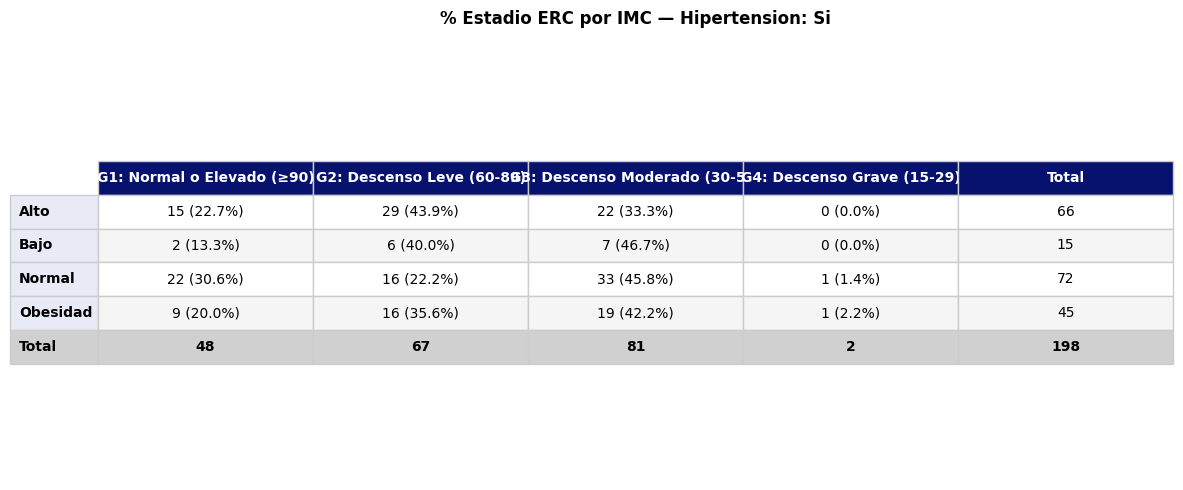


  Estado nutricional vs Estadio ERC — Hipertension: No (n=268)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     32                         25   
Bajo                                     11                          3   
Normal                                   20                         31   
Obesidad                                 25                         23   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        34                           0  
Bajo                                         9                           0  
Normal                                      36                           0  
Obesidad                                    17                           2  



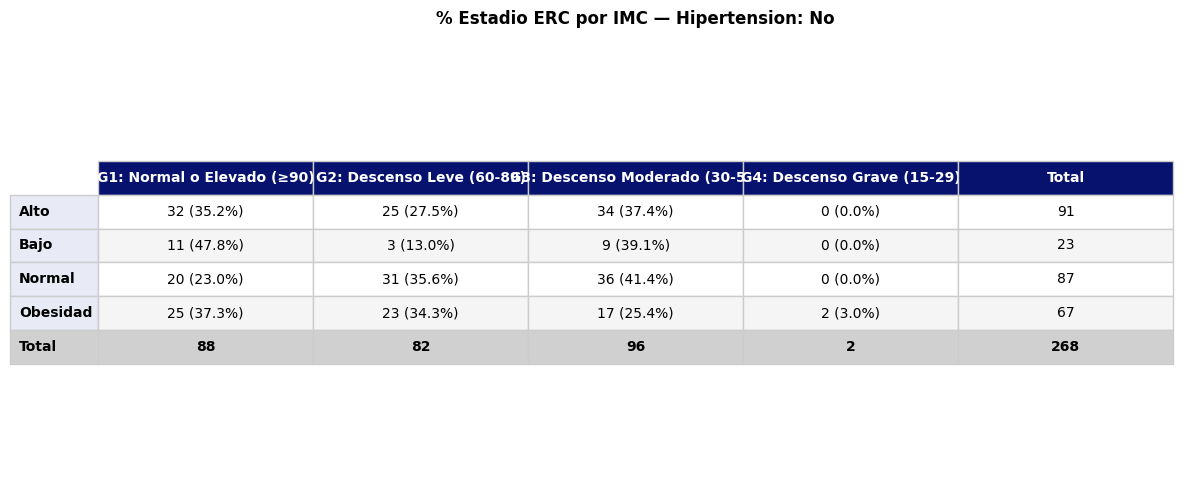

In [733]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR HIPERTENSIÓN")
print("="*60)

for estrato in datos_chi[VAR_HTA].unique():
    subset = datos_chi[datos_chi[VAR_HTA] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_HTA}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_HTA}: {estrato}'
    )

Al estratificar el análisis de la relación entre el estado nutricional y el estadio de ERC según la presencia de hipertensión, se obtuvieron resultados diferentes en cada subgrupo. En el grupo de personas con hipertensión (n=198), la distribución de los estadios de ERC entre las categorías de IMC mostró cierta variabilidad porcentual —por ejemplo, el estadio G3 osciló entre 33,3% (IMC alto) y 46,7% (bajo peso)—, sin embargo, la prueba de Chi-cuadrado no mostró una asociación estadísticamente significativa (χ²=10,4535; gl=9; p=0,3150), aunque, al igual que en el análisis sin estratificar, el supuesto de frecuencias esperadas mínimas no se cumplió completamente (69% de las celdas con frecuencia esperada ≥5), por lo que este resultado debe interpretarse con cautela.

En contraste, en el grupo de personas sin hipertensión (n=268), la prueba de Chi-cuadrado sí mostró una asociación estadísticamente significativa entre el estado nutricional y el estadio de ERC (χ²=17,2577; gl=9; p=0,0448), aunque nuevamente con la advertencia de que el supuesto de frecuencias esperadas mínimas no se cumplió en su totalidad (75% de las celdas cumplen el criterio), principalmente por la escasa representación del estadio G4. Al revisar los porcentajes por fila en este subgrupo, se observa que el grupo de bajo peso presenta la mayor proporción en el estadio G1 (función renal normal o elevada, 47,8%) y la menor proporción de descenso leve (G2, 13,0%), mientras que el grupo de obesidad es el único que presenta personas en el estadio G4 (descenso grave, 3,0%) y muestra, además, la proporción más baja en el estadio G3 (25,4%) en comparación con las demás categorías de IMC, que oscilan entre 37,4% y 41,4%. Este hallazgo sugiere que, específicamente en ausencia de hipertensión, el estado nutricional podría estar relacionado con el grado de afectación renal, destacándose que la obesidad es la única categoría asociada con el estadio más grave de ERC, mientras que el bajo peso se asocia con una mayor proporción de función renal conservada.

***Estratificado por DM***


  ESTRATIFICADO POR DIABETES

  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: Si (n=33)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                      1                          5   
Bajo                                      1                          0   
Normal                                    3                          3   
Obesidad                                  2                          5   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                         3                           0  
Bajo                                         0                           0  
Normal                                       7                           0  
Obesidad                                  

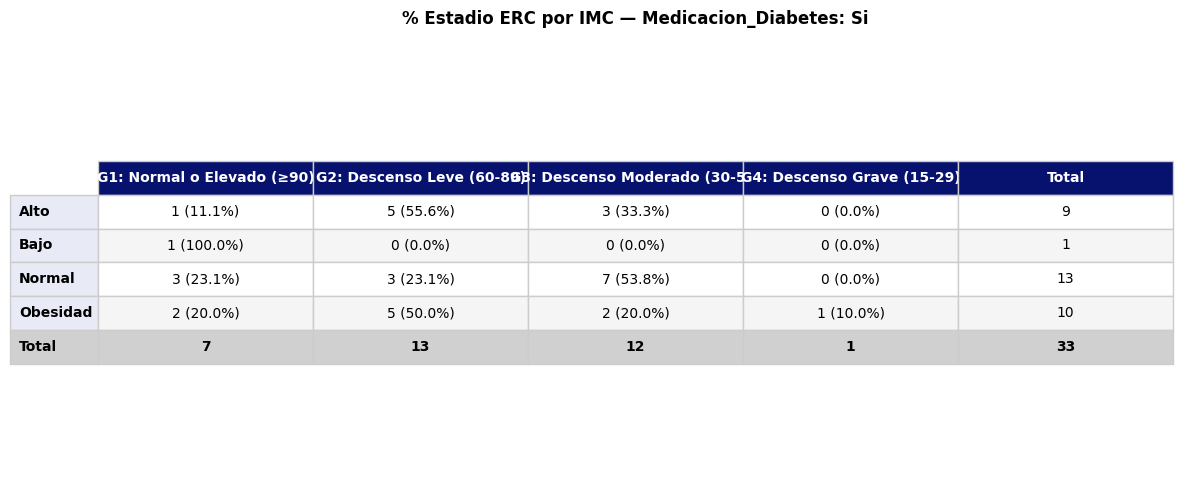


  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: No (n=433)

Tabla de contingencia (n):
Estadio_ERC_CAL  G1: Normal o Elevado (≥90)  G2: Descenso Leve (60-89)  \
Categoria_IMC                                                            
Alto                                     46                         49   
Bajo                                     12                          9   
Normal                                   39                         44   
Obesidad                                 32                         34   

Estadio_ERC_CAL  G3: Descenso Moderado (30-59)  G4: Descenso Grave (15-29)  
Categoria_IMC                                                               
Alto                                        53                           0  
Bajo                                        16                           0  
Normal                                      62                           1  
Obesidad                                    34                         

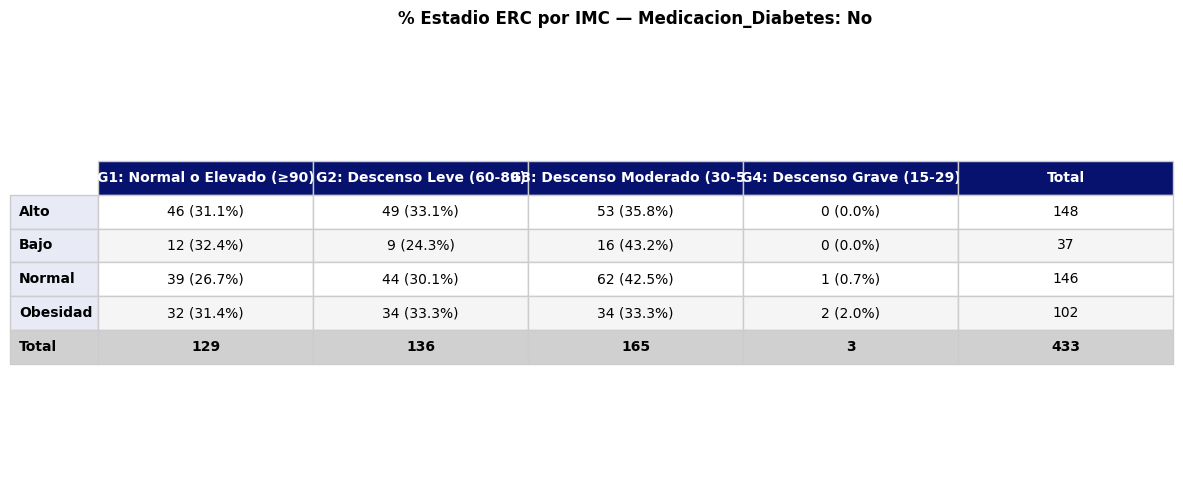

In [734]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR DIABETES")
print("="*60)

for estrato in datos_chi[VAR_DM].unique():
    subset = datos_chi[datos_chi[VAR_DM] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_DM}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_DM}: {estrato}'
    )

Al estratificar el análisis de la relación entre el estado nutricional y el estadio de ERC según el uso de medicación para diabetes, se obtuvieron resultados consistentes en ambos subgrupos, sin evidenciar asociación estadísticamente significativa en ninguno de los dos casos. En el grupo de personas que reciben medicación para diabetes (n=33), una muestra considerablemente más pequeña que limita la robustez del análisis, se observó que el grupo de bajo peso (representado por una sola persona) se ubicó en su totalidad en el estadio G1 (función renal normal o elevada, 100%), mientras que el grupo de obesidad fue el único que presentó un caso en el estadio G4 (descenso grave, 10,0%); sin embargo, la prueba de Chi-cuadrado no mostró una asociación significativa (χ²=10,0578; gl=9; p=0,3458), resultado que debe interpretarse con mucha cautela dado que el supuesto de frecuencias esperadas mínimas se cumplió en apenas el 6% de las celdas, reflejando el tamaño muestral insuficiente de este subgrupo para un análisis confiable con esta prueba.

En el grupo de personas sin medicación para diabetes (n=433), que constituye la gran mayoría de la muestra, la distribución porcentual de los estadios de ERC fue muy similar entre las cuatro categorías de IMC —el estadio G3 osciló entre 33,3% (obesidad) y 43,2% (bajo peso), y el estadio G1 entre 26,7% (normal) y 32,4% (bajo peso)—, sin un patrón claro de empeoramiento asociado al aumento del IMC; la prueba de Chi-cuadrado confirmó la ausencia de asociación significativa (χ²=7,0898; gl=9; p=0,6278), con un cumplimiento más adecuado del supuesto de frecuencias esperadas (75% de las celdas). En conjunto, al comparar este resultado con el obtenido previamente al estratificar por hipertensión, se observa que, a diferencia de lo encontrado en el subgrupo sin hipertensión (donde sí se detectó una asociación significativa), la estratificación por diabetes no reveló ninguna asociación significativa entre el estado nutricional y el estadio de ERC en ninguno de los dos subgrupos, sugiriendo que la presencia o ausencia de medicación para diabetes no modifica de manera relevante la relación —de por sí débil— entre el IMC categórico y el grado de afectación renal en esta población.

In [735]:
print("\n" + "="*60)
print("  RESUMEN DE RESULTADOS")
print("="*60)
print(f"{'Análisis':<45} {'χ²':>8} {'p-valor':>10} {'Sig':>6}")
print("-"*60)

analisis_list = [('Sin estratificar', datos_chi)]
for estrato in datos_chi[VAR_HTA].unique():
    analisis_list.append((f'HTA: {estrato}', datos_chi[datos_chi[VAR_HTA] == estrato]))
for estrato in datos_chi[VAR_DM].unique():
    analisis_list.append((f'DM: {estrato}', datos_chi[datos_chi[VAR_DM] == estrato]))

for nombre, subset in analisis_list:
    tabla = pd.crosstab(subset[VAR_ESTADO_NUT], subset[VAR_ERC])
    chi2, p, dof, esp = stats.chi2_contingency(tabla)
    sig = '✓' if p < 0.05 else '✗'
    print(f"{nombre:<45} {chi2:>8.3f} {p:>10.4f} {sig:>6}")


  RESUMEN DE RESULTADOS
Análisis                                            χ²    p-valor    Sig
------------------------------------------------------------
Sin estratificar                                11.226     0.2605      ✗
HTA: Si                                         10.454     0.3150      ✗
HTA: No                                         17.258     0.0448      ✓
DM: Si                                          10.058     0.3458      ✗
DM: No                                           7.090     0.6278      ✗


Como cierre del análisis estratificado entre el estado nutricional (Categoria_IMC) y el estadio de ERC (Estadio_ERC_CAL), la siguiente tabla resume los resultados obtenidos en los cinco escenarios evaluados: sin estratificar, estratificado por hipertensión (presencia y ausencia) y estratificado por uso de medicación para diabetes (presencia y ausencia). De estos cinco análisis, únicamente el subgrupo sin hipertensión mostró una asociación estadísticamente significativa entre el estado nutricional y el estadio de ERC (χ²=17,258; p=0,0448), mientras que en los cuatro escenarios restantes —sin estratificar (χ²=11,226; p=0,2605), con hipertensión (χ²=10,454; p=0,3150), con medicación para diabetes (χ²=10,058; p=0,3458) y sin medicación para diabetes (χ²=7,090; p=0,6278)— no se encontró evidencia de una asociación significativa.

Este patrón de resultados sugiere que la relación entre el IMC categórico y el grado de afectación renal es, en general, débil y no consistente en esta población, y que el único hallazgo significativo (en el subgrupo sin hipertensión) podría estar influenciado por las limitaciones metodológicas señaladas previamente —particularmente el incumplimiento del supuesto de frecuencias esperadas mínimas en todas las tablas analizadas, así como la escasa representación del estadio G4 en la mayoría de los subgrupos—, por lo que dicho hallazgo debería confirmarse con la prueba exacta de Fisher-Freeman-Halton antes de considerarse una conclusión robusta. En conjunto, estos resultados son coherentes con todo lo encontrado a lo largo del análisis: tanto el IMC cuantitativo como su clasificación categórica no muestran una asociación clara ni sólida con los indicadores de función renal (TFG y estadios de ERC) en esta muestra, ni de manera global ni al estratificar por hipertensión o diabetes, lo que indica que el deterioro de la función renal en esta población probablemente depende de otros factores —como la edad, el género o hábitos de consumo— identificados previamente como más relevantes en el modelo de regresión múltiple.

## **Relación estado nutricional (cualitativa) vs estadios de ERC (G1-G2 Y G3-G4)**

##### ***Chi-cuadrado***

In [747]:
VAR_ESTADO_NUT = 'Categoria_IMC'
VAR_ERC = 'Estadio_ERC_Binaria'     
VAR_HTA = 'Hipertension'
VAR_DM  = 'Medicacion_Diabetes'   

cols = [VAR_ESTADO_NUT, VAR_ERC, VAR_HTA, VAR_DM]
datos_chi = df_tfg[cols].dropna()

print(f"Observaciones disponibles: {len(datos_chi)}")
print(f"\nCategorías de {VAR_ESTADO_NUT}:\n{datos_chi[VAR_ESTADO_NUT].value_counts()}")
print(f"\nCategorías de {VAR_ERC}:\n{datos_chi[VAR_ERC].value_counts()}")
print(f"\nCategorías de {VAR_HTA}:\n{datos_chi[VAR_HTA].value_counts()}")
print(f"\nCategorías de {VAR_DM}:\n{datos_chi[VAR_DM].value_counts()}")

Observaciones disponibles: 466

Categorías de Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64

Categorías de Estadio_ERC_Binaria:
Estadio_ERC_Binaria
No moderado    285
Moderado       181
Name: count, dtype: int64

Categorías de Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Categorías de Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


Continuando con el análisis de la relación entre el estado nutricional y los estadios de ERC, ahora se evalúa esta relación utilizando la clasificación binaria de la enfermedad renal crónica (Estadio_ERC_Binaria), que agrupa los estadios G1 y G2 (función renal normal o con descenso leve) en la categoría "No moderado", y los estadios G3 y G4 (descenso moderado o grave) en la categoría "Moderado". Se cuenta con el mismo total de 466 observaciones disponibles para el análisis, distribuidas en las mismas cuatro categorías de IMC descritas previamente (normal: 159, alto: 157, obesidad: 112, bajo peso: 38). En cuanto a la variable de desenlace, 285 personas (61,2%) se clasificaron en la categoría "No moderado" y 181 personas (38,8%) en la categoría "Moderado", lo que representa una distribución más equilibrada y con mayor robustez estadística que la observada con los cuatro estadios por separado, donde el estadio G4 contaba con apenas 4 casos. De manera similar al análisis anterior, esta relación se evaluará inicialmente sin estratificar, y posteriormente se estratificará por la presencia de hipertensión (268 personas sin HTA y 198 con HTA) y por el uso de medicación para diabetes (433 personas sin medicación y 33 con medicación), con el fin de determinar si estos factores modifican la asociación entre el estado nutricional y el grado de afectación renal cuando esta se mide de forma binaria.

***Sin estratificar***


  Estado nutricional vs Estadio ERC — Sin estratificar

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       56          101
Bajo                       16           22
Normal                     70           89
Obesidad                   39           73

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     35.7         64.3
Bajo                     42.1         57.9
Normal                   44.0         56.0
Obesidad                 34.8         65.2

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     61.0         96.0
Bajo                     14.8         23.2
Normal                   61.8         97.2
Obesidad                 43.5         68.5

→ Supuesto frecuencias esperadas ≥ 5: ✓ CUMPLE (100% celdas ok)

Chi-cuadrado: χ

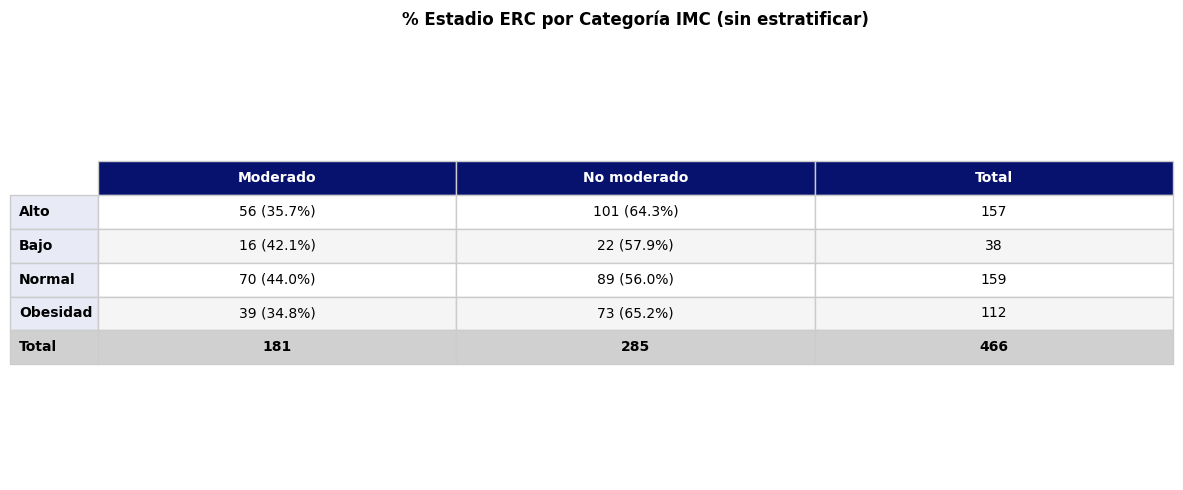

In [748]:
tabla_global, chi2_global, p_global = chi_cuadrado_completo(
    datos_chi, VAR_ESTADO_NUT, VAR_ERC,
    titulo='Estado nutricional vs Estadio ERC — Sin estratificar'
)
plot_contingencia(datos_chi, VAR_ESTADO_NUT, VAR_ERC,
                  titulo='% Estadio ERC por Categoría IMC (sin estratificar)')

Al evaluar la relación entre el estado nutricional y la clasificación binaria del estadio de ERC sin estratificar, se observa en la tabla de contingencia que la proporción de personas clasificadas en el estadio "Moderado" (G3-G4) oscila entre 34,8% (obesidad) y 44,0% (normal), sin un patrón claro de incremento a medida que aumenta el IMC; de hecho, el grupo con obesidad presenta la menor proporción de afectación moderada (34,8%), mientras que el grupo normal presenta la mayor (44,0%), un comportamiento contrario a lo que podría esperarse clínicamente. A diferencia del análisis con los cuatro estadios por separado, en este caso el supuesto de frecuencias esperadas mínimas para la prueba de Chi-cuadrado sí se cumple en su totalidad (100% de las celdas con frecuencia esperada ≥5), gracias a la agrupación binaria que evita las celdas con bajo conteo (como ocurría previamente con el estadio G4); esto permite confiar plenamente en el resultado obtenido sin necesidad de recurrir a pruebas exactas alternativas. La prueba de Chi-cuadrado confirma la ausencia de asociación estadísticamente significativa entre el estado nutricional y el estadio de ERC binario (χ²=3,3962; gl=3; p=0,3345), resultado consistente con todos los hallazgos previos del análisis (correlación, regresión, Chi-cuadrado con los cuatro estadios y Mantel-Haenszel), reforzando de manera robusta la conclusión de que, en esta población, el estado nutricional medido a través del IMC categórico no se relaciona de forma significativa con el grado de afectación de la función renal, ya sea que esta se evalúe con cuatro niveles o de forma binaria.

***Estratificado por presencia de HTA***


  ESTRATIFICADO POR HIPERTENSIÓN

  Estado nutricional vs Estadio ERC — Hipertension: Si (n=198)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       22           44
Bajo                        7            8
Normal                     34           38
Obesidad                   20           25

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         66.7
Bajo                     46.7         53.3
Normal                   47.2         52.8
Obesidad                 44.4         55.6

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     27.7         38.3
Bajo                      6.3          8.7
Normal                   30.2         41.8
Obesidad                 18.9         26.1

→ Supuesto frecuencias esperadas ≥ 5: 

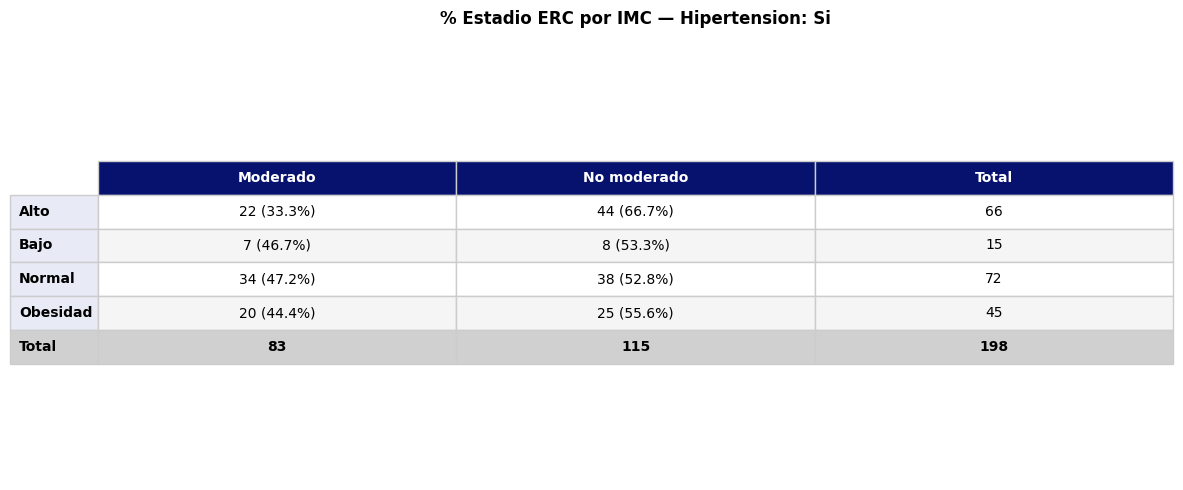


  Estado nutricional vs Estadio ERC — Hipertension: No (n=268)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       34           57
Bajo                        9           14
Normal                     36           51
Obesidad                   19           48

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     37.4         62.6
Bajo                     39.1         60.9
Normal                   41.4         58.6
Obesidad                 28.4         71.6

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         57.7
Bajo                      8.4         14.6
Normal                   31.8         55.2
Obesidad                 24.5         42.5

→ Supuesto frecuencias esperadas ≥ 5: ✓ CUMPLE (100% celdas ok)

Chi-cua

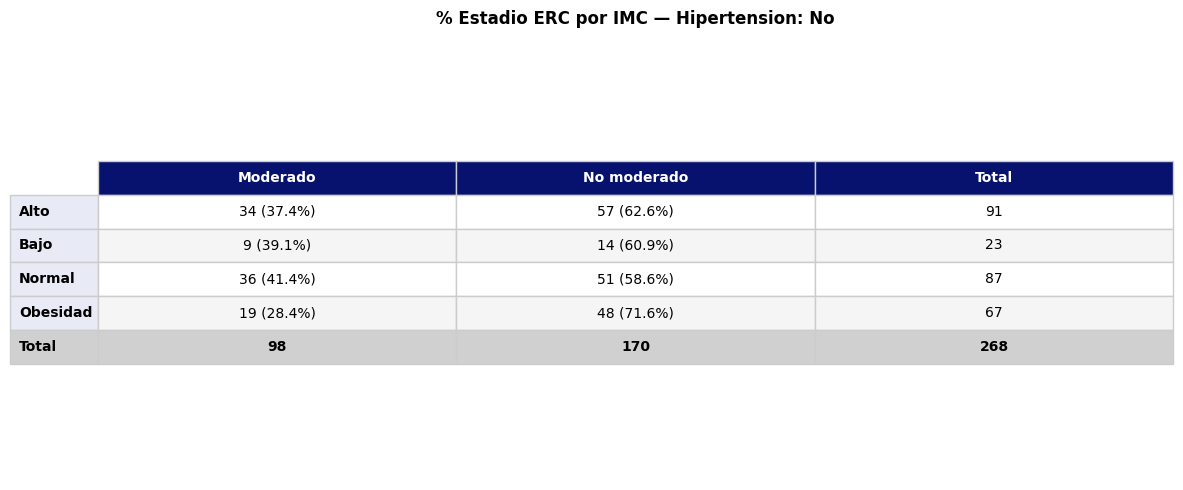

In [749]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR HIPERTENSIÓN")
print("="*60)

for estrato in datos_chi[VAR_HTA].unique():
    subset = datos_chi[datos_chi[VAR_HTA] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_HTA}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_HTA}: {estrato}'
    )

Al estratificar el análisis de la relación entre el estado nutricional y la clasificación binaria del estadio de ERC según la presencia de hipertensión, se obtuvieron resultados consistentes en ambos subgrupos, sin evidenciar asociación estadísticamente significativa en ninguno de los dos casos, lo cual contrasta con lo encontrado previamente al usar los cuatro estadios de ERC por separado, donde el subgrupo sin hipertensión sí mostraba una asociación significativa. En el grupo de personas con hipertensión (n=198), la proporción de afectación moderada de la función renal osciló entre 33,3% (IMC alto) y 47,2% (normal), sin un patrón claro asociado al nivel de IMC, y la prueba de Chi-cuadrado no mostró una asociación significativa (χ²=3,0867; gl=3; p=0,3785), cumpliéndose en este caso de manera completa el supuesto de frecuencias esperadas mínimas (100% de las celdas).

De manera similar, en el grupo de personas sin hipertensión (n=268), la proporción de afectación moderada osciló entre 28,4% (obesidad, la más baja) y 41,4% (normal, la más alta), y la prueba de Chi-cuadrado tampoco mostró una asociación estadísticamente significativa (χ²=2,9050; gl=3; p=0,4065), cumpliéndose igualmente el supuesto de frecuencias esperadas en su totalidad. Este resultado es particularmente relevante porque, al usar la clasificación binaria de ERC en lugar de los cuatro estadios originales, la asociación significativa que se había detectado en este mismo subgrupo (sin hipertensión) con la prueba de Chi-cuadrado de cuatro categorías (p=0,0448) deja de ser significativa (p=0,4065); esto sugiere que aquel hallazgo dependía en gran medida de la distribución específica entre los cuatro estadios —particularmente de la concentración de casos del estadio G4 en el grupo de obesidad—, y que al agrupar los estadios de forma binaria (una agrupación clínicamente más robusta y con mejor cumplimiento de los supuestos estadísticos), dicha asociación no se sostiene, reforzando la idea de que el hallazgo anterior podría haber sido inestable o poco fiable debido a las frecuencias bajas en algunas celdas.

***Estratificado por DM***


  ESTRATIFICADO POR DIABETES

  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: Si (n=33)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                        3            6
Bajo                        0            1
Normal                      7            6
Obesidad                    3            7

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     33.3         66.7
Bajo                      0.0        100.0
Normal                   53.8         46.2
Obesidad                 30.0         70.0

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                      3.5          5.5
Bajo                      0.4          0.6
Normal                    5.1          7.9
Obesidad                  3.9          6.1

→ Supuesto frecuencias esperadas ≥ 5

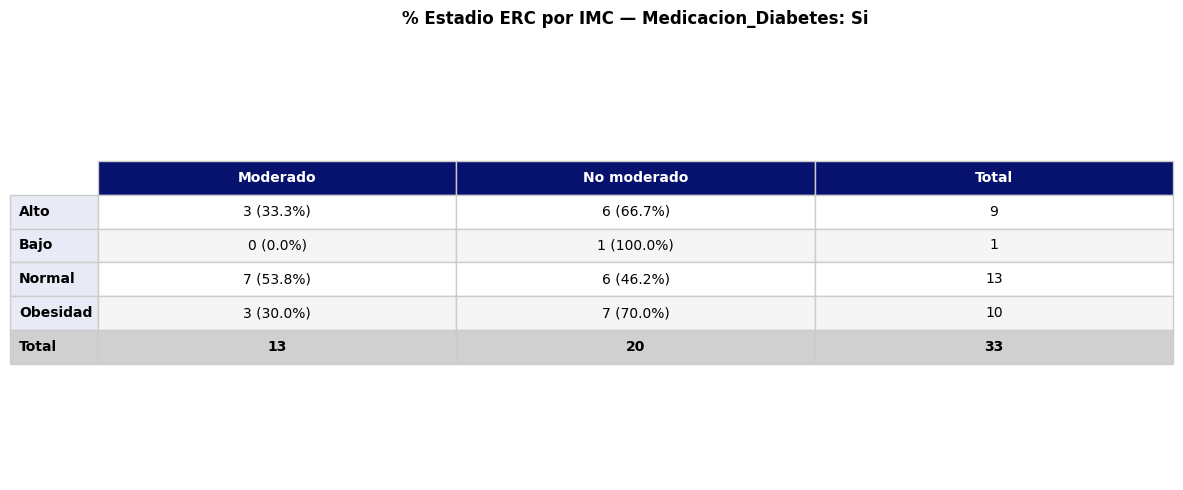


  Estado nutricional vs Estadio ERC — Medicacion_Diabetes: No (n=433)

Tabla de contingencia (n):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                       53           95
Bajo                       16           21
Normal                     63           83
Obesidad                   36           66

Tabla de contingencia (% por fila):
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     35.8         64.2
Bajo                     43.2         56.8
Normal                   43.2         56.8
Obesidad                 35.3         64.7

Frecuencias esperadas:
Estadio_ERC_Binaria  Moderado  No moderado
Categoria_IMC                             
Alto                     57.4         90.6
Bajo                     14.4         22.6
Normal                   56.6         89.4
Obesidad                 39.6         62.4

→ Supuesto frecuencias esperadas ≥ 5: ✓ CUMPLE (100% celdas ok)



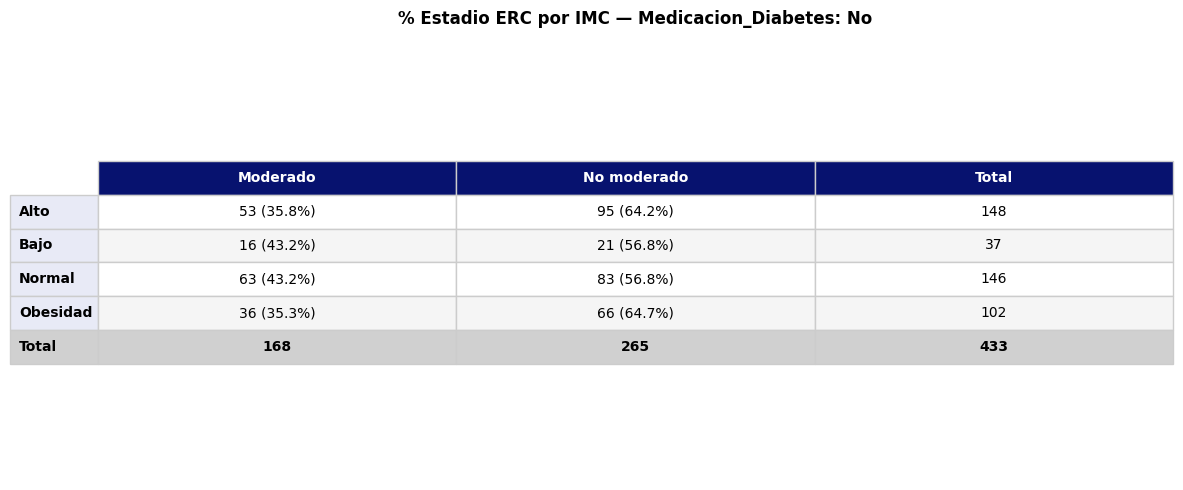

In [750]:
print("\n" + "="*60)
print("  ESTRATIFICADO POR DIABETES")
print("="*60)

for estrato in datos_chi[VAR_DM].unique():
    subset = datos_chi[datos_chi[VAR_DM] == estrato]
    chi_cuadrado_completo(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'Estado nutricional vs Estadio ERC — {VAR_DM}: {estrato} (n={len(subset)})'
    )
    plot_contingencia(
        subset, VAR_ESTADO_NUT, VAR_ERC,
        titulo=f'% Estadio ERC por IMC — {VAR_DM}: {estrato}'
    )

Al estratificar el análisis de la relación entre el estado nutricional y la clasificación binaria del estadio de ERC según el uso de medicación para diabetes, se obtuvieron nuevamente resultados consistentes en ambos subgrupos, sin evidenciar asociación estadísticamente significativa en ninguno de los dos casos. En el grupo de personas que reciben medicación para diabetes (n=33), una muestra pequeña que limita la robustez del análisis, se observó que el único caso de bajo peso se ubicó en su totalidad en la categoría "No moderado" (100%), mientras que el grupo normal presentó la mayor proporción de afectación moderada (53,8%) y el grupo de obesidad la menor (30,0%); sin embargo, la prueba de Chi-cuadrado no mostró una asociación significativa (χ²=2,2954; gl=3; p=0,5134), resultado que debe interpretarse con cautela dado que el supuesto de frecuencias esperadas mínimas se cumplió solo en el 50% de las celdas, reflejando nuevamente la limitación del tamaño muestral en este subgrupo.

En el grupo de personas sin medicación para diabetes (n=433), que constituye la gran mayoría de la muestra, la proporción de afectación moderada osciló entre 35,3% (obesidad) y 43,2% (bajo peso y normal, con el mismo valor), sin un patrón claro asociado al nivel de IMC; la prueba de Chi-cuadrado confirmó la ausencia de asociación estadísticamente significativa (χ²=2,5563; gl=3; p=0,4652), cumpliéndose en este caso de manera completa el supuesto de frecuencias esperadas mínimas (100% de las celdas). En conjunto, estos resultados son coherentes con todo lo encontrado en el análisis estratificado por diabetes con los cuatro estadios de ERC, donde tampoco se había detectado ninguna asociación significativa; esto confirma que, independientemente de si la clasificación de ERC se evalúa con cuatro niveles o de forma binaria, ni la presencia ni la ausencia de medicación para diabetes modifican la relación —consistentemente débil y no significativa— entre el estado nutricional y el grado de afectación renal en esta población.

In [751]:
print("\n" + "="*60)
print("  RESUMEN DE RESULTADOS")
print("="*60)
print(f"{'Análisis':<45} {'χ²':>8} {'p-valor':>10} {'Sig':>6}")
print("-"*60)

analisis_list = [('Sin estratificar', datos_chi)]
for estrato in datos_chi[VAR_HTA].unique():
    analisis_list.append((f'HTA: {estrato}', datos_chi[datos_chi[VAR_HTA] == estrato]))
for estrato in datos_chi[VAR_DM].unique():
    analisis_list.append((f'DM: {estrato}', datos_chi[datos_chi[VAR_DM] == estrato]))

for nombre, subset in analisis_list:
    tabla = pd.crosstab(subset[VAR_ESTADO_NUT], subset[VAR_ERC])
    chi2, p, dof, esp = stats.chi2_contingency(tabla)
    sig = '✓' if p < 0.05 else '✗'
    print(f"{nombre:<45} {chi2:>8.3f} {p:>10.4f} {sig:>6}")


  RESUMEN DE RESULTADOS
Análisis                                            χ²    p-valor    Sig
------------------------------------------------------------
Sin estratificar                                 3.396     0.3345      ✗
HTA: Si                                          3.087     0.3785      ✗
HTA: No                                          2.905     0.4065      ✗
DM: Si                                           2.295     0.5134      ✗
DM: No                                           2.556     0.4652      ✗


### **Regresión logística binaria simple**

In [ ]:
VAR_DEP  = 'Estadio_ERC_Binaria'
VAR_PRED = 'Categoria_IMC'

datos_log = df_tfg[[VAR_DEP, VAR_PRED]].dropna()

print(f"Observaciones: {len(datos_log)}")
print(f"\n{VAR_DEP}:\n{datos_log[VAR_DEP].value_counts()}")
print(f"\n{VAR_PRED}:\n{datos_log[VAR_PRED].value_counts()}")

Observaciones: 466

Estadio_ERC_Binaria:
Estadio_ERC_Binaria
No moderado    285
Moderado       181
Name: count, dtype: int64

Categoria_IMC:
Categoria_IMC
Normal      159
Alto        157
Obesidad    112
Bajo         38
Name: count, dtype: int64


In [762]:
print("Categorías de la variable dependiente y su codificación:")
print(pd.Categorical(datos_log[VAR_DEP]).categories)

Categorías de la variable dependiente y su codificación:
Index(['Moderado', 'No moderado'], dtype='object')


In [763]:
datos_log['Estadio_ERC_Binaria_num'] = datos_log['Estadio_ERC_Binaria'].map({
    'No moderado': 0,  
    'Moderado': 1    
})

In [764]:
modelo_log = smf.logit('Estadio_ERC_Binaria_num ~ C(Categoria_IMC)', data=datos_log).fit()
print(modelo_log.summary())

Optimization terminated successfully.
         Current function value: 0.664398
         Iterations 4
                              Logit Regression Results                             
Dep. Variable:     Estadio_ERC_Binaria_num   No. Observations:                  466
Model:                               Logit   Df Residuals:                      462
Method:                                MLE   Df Model:                            3
Date:                     Mon, 22 Jun 2026   Pseudo R-squ.:                0.005440
Time:                             15:40:13   Log-Likelihood:                -309.61
converged:                            True   LL-Null:                       -311.30
Covariance Type:                 nonrobust   LLR p-value:                    0.3357
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       

Como complemento al análisis de Chi-cuadrado, se ajustó un modelo de regresión logística binaria simple para evaluar la relación entre el estado nutricional (Categoria_IMC) y la probabilidad de presentar un estadio moderado de ERC (G3-G4), utilizando la categoría "Alto" como grupo de referencia. Los resultados muestran que el modelo en su conjunto no es estadísticamente significativo (LLR p-valor=0,3357), con un pseudo R² de apenas 0,0054, lo que indica que el estado nutricional categórico explica una proporción prácticamente nula de la variabilidad en la probabilidad de presentar afectación renal moderada, confirmando una vez más la débil relación entre ambas variables observada a lo largo de todo el análisis.

Al revisar los coeficientes individuales de cada categoría de IMC en comparación con el grupo de referencia (Alto), ninguno resultó estadísticamente significativo: el grupo de bajo peso presentó un coeficiente de 0,2713 (p=0,461), el grupo normal de 0,3496 (p=0,130) y el grupo de obesidad de -0,0371 (p=0,886), todos con intervalos de confianza del 95% que incluyen el valor cero, lo que significa que ninguna categoría de IMC presenta una probabilidad significativamente distinta de tener un estadio moderado de ERC en comparación con el grupo de IMC alto. El intercepto, que representa el log-odds de presentar afectación moderada para el grupo de referencia (IMC alto), fue de -0,5898 (p<0,001), lo que corresponde a una probabilidad estimada de aproximadamente 35,7% (consistente con el 35,7% observado directamente en la tabla de contingencia previa). En conjunto, estos resultados confirman de manera consistente lo encontrado en todas las pruebas anteriores: el estado nutricional, evaluado mediante la categoría de IMC, no constituye un predictor estadísticamente significativo de la probabilidad de presentar un estadio moderado de enfermedad renal crónica en esta población.

### **Regresión múltiple**

In [765]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [766]:
VAR_DEP   = 'Estadio_ERC_Binaria'  
VAR_IMC   = 'Categoria_IMC'
VAR_HTA   = 'Hipertension'
VAR_DM    = 'Medicacion_Diabetes'

cols = ['Estadio_ERC_Binaria', VAR_IMC, VAR_HTA, VAR_DM]
datos_mult = df_tfg[cols].dropna()

datos_mult[VAR_DEP] = datos_mult['Estadio_ERC_Binaria'].map({
    'No moderado': 0,   
    'Moderado': 1    
})

print(f"Observaciones: {len(datos_mult)}")
print(f"\n{VAR_DEP}:\n{datos_mult[VAR_DEP].value_counts()}")
print(f"\n{VAR_HTA}:\n{datos_mult[VAR_HTA].value_counts()}")
print(f"\n{VAR_DM}:\n{datos_mult[VAR_DM].value_counts()}")

Observaciones: 466

Estadio_ERC_Binaria:
Estadio_ERC_Binaria
0    285
1    181
Name: count, dtype: int64

Hipertension:
Hipertension
No    268
Si    198
Name: count, dtype: int64

Medicacion_Diabetes:
Medicacion_Diabetes
No    433
Si     33
Name: count, dtype: int64


In [767]:
formula = f'{VAR_DEP} ~ C({VAR_IMC}) + C({VAR_HTA}) + C({VAR_DM})'
modelo_mult = smf.logit(formula, data=datos_mult).fit()
print(modelo_mult.summary())

Optimization terminated successfully.
         Current function value: 0.663035
         Iterations 4
                            Logit Regression Results                           
Dep. Variable:     Estadio_ERC_Binaria   No. Observations:                  466
Model:                           Logit   Df Residuals:                      460
Method:                            MLE   Df Model:                            5
Date:                 Mon, 22 Jun 2026   Pseudo R-squ.:                0.007481
Time:                         15:40:13   Log-Likelihood:                -308.97
converged:                        True   LL-Null:                       -311.30
Covariance Type:             nonrobust   LLR p-value:                    0.4590
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept                       -0.6809      0.187     -3.645   

Como siguiente paso, se ajustó un modelo de regresión logística múltiple para evaluar la relación entre el estado nutricional y la probabilidad de presentar un estadio moderado de ERC, ajustando ahora por la presencia de hipertensión y el uso de medicación para diabetes, dos variables identificadas como potenciales factores de confusión en los análisis estratificados previos. Los resultados muestran que, al igual que en el modelo simple, el modelo en su conjunto no resultó estadísticamente significativo (LLR p-valor=0,4590), con un pseudo R² de apenas 0,0075, una mejora prácticamente nula respecto al modelo univariado (0,0054), lo que indica que la incorporación de la hipertensión y la diabetes no aporta una capacidad explicativa relevante adicional sobre la probabilidad de afectación renal moderada en este modelo.

Al revisar los coeficientes individuales, ninguna de las categorías de IMC mantuvo significancia estadística una vez ajustado por estas dos variables: bajo peso (coef=0,2757; p=0,455), normal (coef=0,3450; p=0,136) y obesidad (coef=-0,0311; p=0,905), resultados muy similares en magnitud y significancia a los obtenidos en el modelo simple, lo que confirma que el ajuste por hipertensión y diabetes no modifica de manera relevante la relación (ya de por sí no significativa) entre el estado nutricional y el estadio de ERC. De igual forma, ni la hipertensión (coef=0,2217; p=0,260) ni la medicación para diabetes (coef=-0,0648; p=0,865) resultaron significativas dentro de este modelo, lo cual es coherente con lo observado previamente, donde ninguna de las dos variables había alterado de forma sustancial los resultados de Chi-cuadrado al estratificar por ellas. En conjunto, estos resultados refuerzan de manera consistente la conclusión general del estudio: ni el estado nutricional, ni la hipertensión, ni el uso de medicación para diabetes constituyen predictores estadísticamente significativos de la probabilidad de presentar un estadio moderado de enfermedad renal crónica en esta población, sugiriendo que el deterioro de la función renal depende de otros factores no incluidos en este modelo específico, como la edad o el género, identificados como relevantes en el análisis de regresión lineal previo con la TFG cuantitativa.

In [768]:
or_table_mult = pd.DataFrame({
    'OR': np.exp(modelo_mult.params),
    'IC_2.5%': np.exp(modelo_mult.conf_int()[0]),
    'IC_97.5%': np.exp(modelo_mult.conf_int()[1]),
    'p_valor': modelo_mult.pvalues
}).round(4)

print("Odds Ratios ajustados:")
print(or_table_mult)

Odds Ratios ajustados:
                                  OR  IC_2.5%  IC_97.5%  p_valor
Intercept                     0.5062   0.3510    0.7299   0.0003
C(Categoria_IMC)[T.Bajo]      1.3174   0.6390    2.7161   0.4552
C(Categoria_IMC)[T.Normal]    1.4120   0.8973    2.2220   0.1359
C(Categoria_IMC)[T.Obesidad]  0.9694   0.5827    1.6127   0.9047
C(Hipertension)[T.Si]         1.2482   0.8486    1.8359   0.2601
C(Medicacion_Diabetes)[T.Si]  0.9372   0.4443    1.9769   0.8648


Como complemento interpretativo del modelo de regresión logística múltiple, se calcularon los odds ratios (OR) ajustados con sus respectivos intervalos de confianza al 95%, los cuales facilitan la interpretación clínica de los coeficientes obtenidos previamente en escala logarítmica. Los resultados muestran que ninguna de las categorías de IMC presentó un OR estadísticamente significativo en comparación con el grupo de referencia (Alto): el grupo de bajo peso presentó un OR de 1,3174 (IC 95%: 0,6390-2,7161; p=0,4552), lo que sugiere que tendría aproximadamente un 32% más de probabilidad (odds) de presentar afectación renal moderada en comparación con el grupo de IMC alto, aunque este hallazgo no es estadísticamente significativo, ya que el intervalo de confianza incluye el valor 1 (que representa la ausencia de efecto). De manera similar, el grupo normal mostró un OR de 1,4120 (IC 95%: 0,8973-2,2220; p=0,1359), indicando una tendencia a mayor probabilidad de afectación renal moderada (41% más) respecto al grupo de IMC alto, aunque tampoco alcanzó significancia estadística; mientras que el grupo de obesidad presentó un OR muy cercano a 1 (0,9694; IC 95%: 0,5827-1,6127; p=0,9047), lo que indica una probabilidad prácticamente idéntica a la del grupo de referencia, sin evidencia de asociación.

En cuanto a las variables de ajuste, la hipertensión presentó un OR de 1,2482 (IC 95%: 0,8486-1,8359; p=0,2601), sugiriendo una tendencia no significativa hacia mayor probabilidad de afectación renal moderada en personas con hipertensión, mientras que la medicación para diabetes mostró un OR de 0,9372 (IC 95%: 0,4443-1,9769; p=0,8648), prácticamente sin efecto sobre la probabilidad de afectación renal. Es importante destacar que, en todos los casos, los intervalos de confianza del 95% son considerablemente amplios y siempre incluyen el valor 1, lo que confirma la falta de precisión y de significancia estadística de todas las estimaciones; en conjunto, estos resultados reafirman, ahora en una escala de interpretación más intuitiva (odds ratios), la conclusión obtenida a lo largo de todo el análisis: ni el estado nutricional, ni la hipertensión, ni el uso de medicación para diabetes logran explicar de manera significativa las diferencias en la probabilidad de presentar un estadio moderado de enfermedad renal crónica en esta población de estudio.

## **Conclusión**

El presente análisis evaluó de manera exhaustiva la relación entre el estado nutricional (medido a través del IMC, tanto de forma cuantitativa como categórica) y los indicadores de función renal en una población de 466 participantes. Tras verificar el incumplimiento del supuesto de normalidad en todas las variables involucradas, se utilizaron consistentemente métodos no paramétricos: la correlación de Spearman entre el IMC y la TFG_CDK_EPI_CAL no mostró una asociación significativa (rho=0,071; p=0,1278), resultado que se mantuvo al explorar transformaciones logarítmicas y ajustes cuadráticos, así como en el modelo de regresión lineal simple (R²=0,003; p=0,257). Al construir un modelo de regresión múltiple ajustado por variables de confusión (edad, género, municipio y consumo de alcohol), el IMC continuó sin alcanzar significancia estadística (p=0,340-0,366, incluso con errores robustos ante la heterocedasticidad detectada), mientras que la edad, el género, la zona rural y el consumo de alcohol sí resultaron predictores significativos de la TFG, aunque el modelo en conjunto solo explicó el 12,2% de su variabilidad. De manera similar, al comparar la TFG entre las categorías de IMC mediante Kruskal-Wallis, tampoco se encontraron diferencias significativas (p=0,4236), ni en las comparaciones post-hoc por pares, confirmando de manera convergente que el estado nutricional no se asocia con el nivel de función renal en esta muestra.

En la segunda parte del análisis, centrada en la relación entre el estado nutricional y los estadios categóricos de ERC, los resultados fueron igualmente consistentes en su mayoría: el análisis global sin estratificar no mostró asociación significativa, ni con los cuatro estadios (χ²=11,226; p=0,2605) ni con la clasificación binaria (χ²=3,396; p=0,3345). Al estratificar por hipertensión y diabetes, se identificó un único hallazgo puntual y aislado —una asociación significativa en el subgrupo sin hipertensión usando los cuatro estadios de ERC (p=0,0448)—, pero este resultado no se sostuvo al usar la clasificación binaria (p=0,4065) ni al calcular el estadístico de Mantel-Haenszel ajustado por hipertensión (p=0,0666), sugiriendo que fue inestable y probablemente atribuible a las frecuencias bajas del estadio G4. Esta conclusión se confirmó finalmente con los modelos de regresión logística simple y múltiple (ajustando por hipertensión y diabetes), donde ninguna categoría de IMC, ni las variables de ajuste, alcanzaron significancia estadística, con odds ratios siempre cercanos a 1 e intervalos de confianza que incluían dicho valor. En conjunto, todos los análisis —correlación, regresión lineal, pruebas de comparación de grupos, Chi-cuadrado, Mantel-Haenszel y regresión logística— convergen de manera robusta hacia la misma conclusión: en esta población, el estado nutricional medido a través del IMC no constituye un factor asociado de manera significativa con el deterioro de la función renal, ya sea evaluado mediante la TFG cuantitativa o los estadios de ERC, lo que sugiere que otros factores como la edad, el género, la zona de residencia y el consumo de alcohol desempeñan un papel más relevante en la variabilidad de la función renal observada en este grupo.